## 🏆 HPO 최적화 결과 요약

### 📊 최종 우승자: TPE Sampler

두 지표 모두 **TPE (Tree-structured Parzen Estimator)**가 **QMC (Quasi-Monte Carlo)**보다 우수한 성능을 보였습니다.

---

### 🔬 TPC 기반 라벨링 최적화

| **항목**         | **최적값**         | **비고**                       |
|------------------|--------------------|--------------------------------|
| **Best Score**   | `275.963`          | TPE가 QMC 대비 4.815 우수      |
| **Best TPC Low** | `4.369`            | 신선 임계값 (Fresh < 4.369)    |
| **Best TPC High**| `6.427`            | 부패 임계값 (Decay ≥ 6.427)    |

#### 📈 최종 라벨 분포 (TPC)
- **Fresh (신선)**: 154개 (57.0%)
- **Decay (부패)**: 35개 (13.0%)
- **Middle (중간)**: 81개 (30.0%)

---

### 🧪 TBARS 기반 라벨링 최적화

| **Metric**        | **TPE**    | **QMC**    |
|-------------------|------------|------------|
| Best Score        | 300.000    | 300.000    |
| Mean Score        | 270.031    | 117.692    |
| Std Score         | 70.069     | 80.349     |
| Best TBARS Low    | 0.187      | 0.187      |
| Best TBARS High   | 0.301      | 0.298      |
| Runtime (s)       | ~500 trials| 1.4        |

🏆 **최종 승자:** TPE  
**성능 향상:** 0.000

#### 📈 최종 라벨 분포 (TBARS)
- **Fresh (신선)**: 39개 (14.4%)
- **Decay (부패)**: 96개 (35.6%)
- **Middle (중간)**: 135개 (50.0%)

---

### 📋 메모용 요약표

| **지표** | **Best Score** | **Low Threshold** | **High Threshold** |
|----------|---------------|-------------------|-------------------|
| **TPC**  | 275.963       | 4.369             | 6.427             |
| **TBARS**| 300.000       | 0.187             | 0.301             |

---

> **결론:** TPE가 TPC 기준에서 QMC 대비 더 우수한 성능을 보였으며, TBARS 기준에서는 두 방법 모두 동일한 최고 점수를 기록했습니다.

## .pkl 파일 불러오기

In [1]:
import pickle
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from IPython.display import display
import os

# 전처리된 데이터 불러오기
save_dir = "/Users/taehokim/lab/BRL_AI/BRL_final/CLR_pkl" 

print("=== 전처리된 데이터 불러오기 ===")

# 1. 최종 데이터만 불러오기 (final_taxonomic_levels)
all_data_path = os.path.join(save_dir, "all_preprocessed_data.pkl")

if os.path.exists(all_data_path):
    with open(all_data_path, 'rb') as f:
        preprocessed_data = pickle.load(f)
    final_taxonomic_levels = preprocessed_data['final_taxonomic_levels']
    print(f"✅ 최종 데이터 로드 완료")
    print(f"총 taxonomy level 수: {len(final_taxonomic_levels)}")
else:
    print(f"❌ 통합 데이터 파일을 찾을 수 없습니다: {all_data_path}")

# 2. ANOVA 결과 불러오기
anova_results_path = os.path.join(save_dir, "anova_results.pkl")
if os.path.exists(anova_results_path):
    with open(anova_results_path, 'rb') as f:
        anova_results = pickle.load(f)
    print(f"✅ ANOVA 결과 로드 완료")
else:
    print(f"❌ ANOVA 결과 파일을 찾을 수 없습니다: {anova_results_path}")

# 3. 변화량 분석 결과 불러오기
change_analysis_path = os.path.join(save_dir, "change_analysis_results.pkl")
if os.path.exists(change_analysis_path):
    with open(change_analysis_path, 'rb') as f:
        change_analysis_results = pickle.load(f)
    print(f"✅ 변화량 분석 결과 로드 완료")
else:
    print(f"❌ 변화량 분석 결과 파일을 찾을 수 없습니다: {change_analysis_path}")

# 4. ANOVA 결과 검토 (상위 5개 feature만 표시)
print(f"\n=== ANOVA 결과 검토 (상위 5개 유의 Feature) ===")
for level_name in ['Phylum', 'Class', 'Order', 'Family', 'Genus']:
    if level_name in anova_results:
        anova_result_df = anova_results[level_name]['anova_result']
        significant_features = anova_results[level_name]['significant_features']
        print(f"\n[{level_name}]")
        print(f"총 유의 Feature 수: {len(significant_features)}")
        if not anova_result_df.empty:
            top_5_anova = anova_result_df.head(5)
            print(f"상위 5개 유의 Feature (p-value 기준):")
            display(top_5_anova)
        else:
            print("ANOVA 결과가 없습니다.")

# 5. 변화량 분석 결과 검토 (상위 5개만 표시)
print(f"\n=== 변화량 분석 결과 검토 (상위 5개 변화량) ===")
for level_name in ['Phylum', 'Class', 'Order', 'Family', 'Genus']:
    if level_name in change_analysis_results:
        top_features = change_analysis_results[level_name]['top_10_features'][:5]
        summary_stats = change_analysis_results[level_name]['summary_stats']
        print(f"\n[{level_name}]")
        print(f"증가 패턴: {summary_stats['increase_count']}개, 감소 패턴: {summary_stats['decrease_count']}개")
        if top_features:
            change_df = pd.DataFrame([
                {
                    'Feature': feat['feature'],
                    'Change_Amount': feat['change_amount'],
                    'Abs_Change': feat['abs_change'],
                    'Trend': feat['trend'],
                    'Min_Day': feat['min_day'],
                    'Max_Day': feat['max_day']
                }
                for feat in top_features
            ])
            print(f"상위 5개 변화량 Feature:")
            display(change_df)
        else:
            print("변화량 분석 결과가 없습니다.")

# 6. 데이터 구조 간단 확인
print(f"\n=== 데이터 구조 요약 ===")
for level_name, merged_df in final_taxonomic_levels:
    feature_cols = [col for col in merged_df.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS']]
    significant_features = anova_results[level_name]['significant_features']
    print(f"[{level_name}] 샘플: {len(merged_df)}, 전체 Feature: {len(feature_cols)}, ANOVA 유의: {len(significant_features)}")

# 7. 특정 레벨 선택 함수 (HPO에서 사용할 수 있도록)
def get_level_data(level_name):
    """특정 taxonomy level의 데이터를 반환하는 함수"""
    for name, data in final_taxonomic_levels:
        if name.lower() == level_name.lower():
            feature_cols = [col for col in data.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS']]
            return {
                'data': data,
                'features': data[feature_cols],
                'feature_names': feature_cols,
                'tpc': data['TPC (log CFU/g)'],
                'tbars': data['TBARS'],
                'description': data['Description'],
                'significant_features': anova_results[name]['significant_features'],
                'anova_results': anova_results[name],
                'change_analysis': change_analysis_results[name]
            }
    return None

print(f"\n=== 데이터 로딩 완료 ===")
print("이제 하이퍼파라미터 최적화를 진행할 수 있습니다.")

# 8. 사용 예시
print(f"\n=== 사용 예시 ===")
print("# 특정 레벨 데이터 가져오기:")
print("genus_data = get_level_data('genus')")
print("X = genus_data['features']  # Feature 데이터")
print("y_tpc = genus_data['tpc']   # TPC 타겟")
print("y_tbars = genus_data['tbars']  # TBARS 타겟")
print("significant_features = genus_data['significant_features']  # ANOVA 유의 Feature")
print("top_change_features = genus_data['change_analysis']['top_10_features']  # 변화량 상위 Feature")

=== 전처리된 데이터 불러오기 ===
✅ 최종 데이터 로드 완료
총 taxonomy level 수: 5
✅ ANOVA 결과 로드 완료
✅ 변화량 분석 결과 로드 완료

=== ANOVA 결과 검토 (상위 5개 유의 Feature) ===

[Phylum]
총 유의 Feature 수: 12
상위 5개 유의 Feature (p-value 기준):


,feature,f_statistic,p_value,fdr
6,p__Deinococcota,34.734869,4.434908e-37,5.321890e-36
2,p__Bacteroidota,32.394400,4.045796e-35,2.427478e-34
4,p__Proteobacteria,14.010545,6.247631e-17,2.499053e-16
3,p__Chloroflexi,10.326593,1.505222e-12,4.515667e-12
11,p__Acidobacteriota,10.256684,1.834053e-12,4.401728e-12



[Class]
총 유의 Feature 수: 13
상위 5개 유의 Feature (p-value 기준):


,feature,f_statistic,p_value,fdr
5,c__Alphaproteobacteria,39.072509,1.516817e-40,1.971863e-39
6,c__Deinococci,35.573071,9.135277e-38,5.937930e-37
2,c__Bacteroidia,35.004501,2.662388e-37,1.153701e-36
4,c__Gammaproteobacteria,17.011379,2.684438e-20,8.724422e-20
10,c__Negativicutes,12.885207,1.273132e-15,3.310143e-15



[Order]
총 유의 Feature 수: 48
상위 5개 유의 Feature (p-value 기준):


,feature,f_statistic,p_value,fdr
15,o__Bacillales,85.996188,1.031225e-68,4.949881e-67
8,o__Xanthomonadales,72.490273,6.305695e-62,1.513367e-60
3,o__Pseudomonadales,67.223805,4.807589e-59,7.692142e-58
27,o__Aeromonadales,48.856314,1.132304e-47,1.358764e-46
33,o__Staphylococcales,46.239771,7.498659e-46,7.198712e-45



[Family]
총 유의 Feature 수: 85
상위 5개 유의 Feature (p-value 기준):


,feature,f_statistic,p_value,fdr
54,f__Chitinibacteraceae,353.478640,2.678236e-135,2.276500e-133
56,f__Listeriaceae,168.446767,1.953223e-98,8.301199e-97
20,f__Bacillaceae,88.560876,6.476680e-70,1.835059e-68
11,f__Xanthomonadaceae,75.054579,2.801932e-63,5.954105e-62
27,f__Vagococcaceae,74.323288,6.758308e-63,1.148912e-61



[Genus]
총 유의 Feature 수: 133
상위 5개 유의 Feature (p-value 기준):


,feature,f_statistic,p_value,fdr
60,g__Iodobacter,358.981444,4.241106e-136,5.640671e-134
64,g__Brochothrix,195.211125,1.727308e-105,1.148660e-103
21,g__Bacillus,93.371949,4.196296e-72,1.860358e-70
92,g__Macrococcus,81.113778,2.367538e-66,7.872064e-65
95,g__Streptococcus,77.131501,2.372840e-64,6.311754e-63



=== 변화량 분석 결과 검토 (상위 5개 변화량) ===

[Phylum]
증가 패턴: 12개, 감소 패턴: 0개
상위 5개 변화량 Feature:


,Feature,Change_Amount,Abs_Change,Trend,Min_Day,Max_Day
0,p__Deinococcota,11.296755,11.296755,감소 후 증가,14,3
1,p__Bacteroidota,5.583479,5.583479,감소 후 증가,18,7
2,p__Campilobacterota,3.938875,3.938875,증가,0,3
3,p__Actinobacteriota,1.181904,1.181904,증가,1,11
4,p__Proteobacteria,1.113002,1.113002,증가,3,14



[Class]
증가 패턴: 13개, 감소 패턴: 0개
상위 5개 변화량 Feature:


,Feature,Change_Amount,Abs_Change,Trend,Min_Day,Max_Day
0,c__Deinococci,11.635344,11.635344,감소 후 증가,14,3
1,c__Alphaproteobacteria,6.992750,6.992750,감소 후 증가,11,1
2,c__Clostridia,5.837143,5.837143,감소 후 증가,9,0
3,c__Bacteroidia,5.782637,5.782637,감소 후 증가,18,7
4,c__Negativicutes,4.435462,4.435462,감소 후 증가,5,0



[Order]
증가 패턴: 48개, 감소 패턴: 0개
상위 5개 변화량 Feature:


,Feature,Change_Amount,Abs_Change,Trend,Min_Day,Max_Day
0,o__Bacillales,13.314147,13.314147,감소 후 증가,18,3
1,o__Xanthomonadales,13.142663,13.142663,감소 후 증가,18,3
2,o__Aeromonadales,12.550232,12.550232,감소 후 증가,9,3
3,o__Staphylococcales,11.204740,11.204740,감소 후 증가,18,1
4,o__Thermales,11.022691,11.022691,감소 후 증가,14,3



[Family]
증가 패턴: 85개, 감소 패턴: 0개
상위 5개 변화량 Feature:


,Feature,Change_Amount,Abs_Change,Trend,Min_Day,Max_Day
0,f__Chitinibacteraceae,14.204433,14.204433,증가,3,18
1,f__Bacillaceae,13.781898,13.781898,감소 후 증가,18,3
2,f__Xanthomonadaceae,13.613548,13.613548,감소 후 증가,18,3
3,f__Vagococcaceae,13.444156,13.444156,증가,5,18
4,f__Carnobacteriaceae,13.438775,13.438775,증가,0,18



[Genus]
증가 패턴: 133개, 감소 패턴: 0개
상위 5개 변화량 Feature:


,Feature,Change_Amount,Abs_Change,Trend,Min_Day,Max_Day
0,g__Macrococcus,14.233680,14.233680,감소 후 증가,18,3
1,g__Iodobacter,14.092941,14.092941,증가,3,18
2,g__Bacillus,14.003815,14.003815,감소 후 증가,18,3
3,g__Xanthomonas,13.752768,13.752768,감소 후 증가,18,3
4,g__Streptococcus,13.549499,13.549499,감소 후 증가,18,3



=== 데이터 구조 요약 ===
[Phylum] 샘플: 270, 전체 Feature: 12, ANOVA 유의: 12
[Class] 샘플: 270, 전체 Feature: 13, ANOVA 유의: 13
[Order] 샘플: 270, 전체 Feature: 48, ANOVA 유의: 48
[Family] 샘플: 270, 전체 Feature: 85, ANOVA 유의: 85
[Genus] 샘플: 270, 전체 Feature: 133, ANOVA 유의: 133

=== 데이터 로딩 완료 ===
이제 하이퍼파라미터 최적화를 진행할 수 있습니다.

=== 사용 예시 ===
# 특정 레벨 데이터 가져오기:
genus_data = get_level_data('genus')
X = genus_data['features']  # Feature 데이터
y_tpc = genus_data['tpc']   # TPC 타겟
y_tbars = genus_data['tbars']  # TBARS 타겟
significant_features = genus_data['significant_features']  # ANOVA 유의 Feature
top_change_features = genus_data['change_analysis']['top_10_features']  # 변화량 상위 Feature


In [2]:
# 각 taxonomy level별 상세 feature 정보 확인
print("=== Taxonomy Level별 Feature 상세 정보 ===")

feature_summary = []

for level_name, merged_df in final_taxonomic_levels:
    feature_cols = [col for col in merged_df.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS']]
    significant_features = anova_results[level_name]['significant_features']
    
    # 각 레벨별 정보 수집
    level_info = {
        'Level': level_name,
        'Total_Features': len(feature_cols),
        'ANOVA_Significant': len(significant_features),
        'Sample_Count': len(merged_df),
        'Significant_Ratio': f"{len(significant_features)/len(feature_cols)*100:.1f}%" if feature_cols else "0%"
    }
    feature_summary.append(level_info)
    
    print(f"\n[{level_name}]")
    print(f"  전체 Feature 수: {len(feature_cols)}")
    print(f"  ANOVA 유의 Feature 수: {len(significant_features)}")
    print(f"  유의 Feature 비율: {len(significant_features)/len(feature_cols)*100:.1f}%")
    print(f"  총 샘플 수: {len(merged_df)}")
    
    # Feature 이름 예시 (처음 5개)
    print(f"  Feature 예시 (처음 5개): {feature_cols[:5]}")
    
    # ANOVA 유의 Feature 예시 (처음 5개)
    if significant_features:
        print(f"  유의 Feature 예시 (처음 5개): {significant_features[:5]}")
    else:
        print(f"  유의한 Feature 없음")
    
    # Feature 명명 규칙 확인 (prefix 확인)
    if feature_cols:
        prefixes = set([col.split('__')[0] + '__' for col in feature_cols if '__' in col])
        print(f"  Feature prefix: {list(prefixes)}")

# Summary Table 생성
summary_df = pd.DataFrame(feature_summary)
print(f"\n=== Feature 수 요약 테이블 ===")
print(summary_df.to_string(index=False))

# 시각적 요약
print(f"\n=== 레벨별 Feature 수 비교 ===")
for info in feature_summary:
    level = info['Level']
    total = info['Total_Features']
    significant = info['ANOVA_Significant']
    bar_length = 50
    
    # 막대그래프 스타일로 표시
    total_bar = '█' * min(int(total/10), bar_length)
    sig_bar = '▓' * min(int(significant/10), bar_length)
    
    print(f"{level:8} │ 전체: {total:4d} {total_bar}")
    print(f"         │ 유의: {significant:4d} {sig_bar}")
    print(f"         │ 비율: {info['Significant_Ratio']:>6}")
    print("─" * 60)

# 전체 통계
total_all_features = sum([info['Total_Features'] for info in feature_summary])
total_significant_features = sum([info['ANOVA_Significant'] for info in feature_summary])

print(f"\n=== 전체 통계 ===")
print(f"모든 레벨 전체 Feature 합계: {total_all_features}")
print(f"모든 레벨 유의 Feature 합계: {total_significant_features}")
print(f"전체 유의 Feature 비율: {total_significant_features/total_all_features*100:.1f}%")

# 레벨별 Feature 밀도 (Feature 수 / 샘플 수)
print(f"\n=== Feature 밀도 (Feature 수 / 샘플 수) ===")
for info in feature_summary:
    density = info['Total_Features'] / info['Sample_Count']
    sig_density = info['ANOVA_Significant'] / info['Sample_Count']
    print(f"{info['Level']:8} │ 전체: {density:.2f} │ 유의: {sig_density:.2f}")

=== Taxonomy Level별 Feature 상세 정보 ===

[Phylum]
  전체 Feature 수: 12
  ANOVA 유의 Feature 수: 12
  유의 Feature 비율: 100.0%
  총 샘플 수: 270
  Feature 예시 (처음 5개): ['p__Firmicutes', 'p__Actinobacteriota', 'p__Bacteroidota', 'p__Chloroflexi', 'p__Proteobacteria']
  유의 Feature 예시 (처음 5개): ['p__Deinococcota', 'p__Bacteroidota', 'p__Proteobacteria', 'p__Chloroflexi', 'p__Acidobacteriota']
  Feature prefix: ['p__']

[Class]
  전체 Feature 수: 13
  ANOVA 유의 Feature 수: 13
  유의 Feature 비율: 100.0%
  총 샘플 수: 270
  Feature 예시 (처음 5개): ['c__Bacilli', 'c__Actinobacteria', 'c__Bacteroidia', 'c__Chloroflexia', 'c__Gammaproteobacteria']
  유의 Feature 예시 (처음 5개): ['c__Alphaproteobacteria', 'c__Deinococci', 'c__Bacteroidia', 'c__Gammaproteobacteria', 'c__Negativicutes']
  Feature prefix: ['c__']

[Order]
  전체 Feature 수: 48
  ANOVA 유의 Feature 수: 48
  유의 Feature 비율: 100.0%
  총 샘플 수: 270
  Feature 예시 (처음 5개): ['o__Lactobacillales', 'o__Corynebacteriales', 'o__Flavobacteriales', 'o__Pseudomonadales', 'o__Bacilli(c)']
  유의 

## HPO 분석 전 dataset 구분 

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("=== HPO 분석을 위한 데이터셋 구분 ===")

# 각 taxonomy level별로 TPC와 TBARS 데이터셋을 별도로 생성
tpc_datasets = {}
tbars_datasets = {}

for level_name, merged_df in final_taxonomic_levels:
    # Feature 컬럼들 (Description, TPC, TBARS 제외)
    feature_cols = [col for col in merged_df.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS']]
    
    # 1. TPC 데이터셋 생성 (Features + TPC)
    tpc_df = merged_df[['Description'] + feature_cols + ['TPC (log CFU/g)']].copy()
    tpc_datasets[level_name] = {
        'data': tpc_df,
        'features': tpc_df[feature_cols],
        'target': tpc_df['TPC (log CFU/g)'],
        'feature_names': feature_cols,
        'target_name': 'TPC (log CFU/g)',
        'description': tpc_df['Description'],
        'significant_features': anova_results[level_name]['significant_features']
    }
    
    # 2. TBARS 데이터셋 생성 (Features + TBARS)
    tbars_df = merged_df[['Description'] + feature_cols + ['TBARS']].copy()
    tbars_datasets[level_name] = {
        'data': tbars_df,
        'features': tbars_df[feature_cols],
        'target': tbars_df['TBARS'],
        'feature_names': feature_cols,
        'target_name': 'TBARS',
        'description': tbars_df['Description'],
        'significant_features': anova_results[level_name]['significant_features']
    }
    
    print(f"\n[{level_name}]")
    print(f"  Feature 수: {len(feature_cols)}")
    print(f"  샘플 수: {len(merged_df)}")
    print(f"  TPC 범위: {tpc_df['TPC (log CFU/g)'].min():.2f} ~ {tpc_df['TPC (log CFU/g)'].max():.2f}")
    print(f"  TBARS 범위: {tbars_df['TBARS'].min():.2f} ~ {tbars_df['TBARS'].max():.2f}")
    print(f"  ANOVA 유의 Feature 수: {len(anova_results[level_name]['significant_features'])}")

# 데이터셋 접근 함수들
def get_tpc_dataset(level_name):
    """특정 taxonomy level의 TPC 데이터셋을 반환"""
    if level_name in tpc_datasets:
        return tpc_datasets[level_name]
    else:
        print(f"Level '{level_name}' not found. Available levels: {list(tpc_datasets.keys())}")
        return None

def get_tbars_dataset(level_name):
    """특정 taxonomy level의 TBARS 데이터셋을 반환"""
    if level_name in tbars_datasets:
        return tbars_datasets[level_name]
    else:
        print(f"Level '{level_name}' not found. Available levels: {list(tbars_datasets.keys())}")
        return None

def get_dataset_summary():
    """전체 데이터셋 요약 정보 출력"""
    print("\n=== 데이터셋 요약 ===")
    print(f"{'Level':<10} {'Samples':<8} {'Features':<10} {'ANOVA Sig':<12} {'TPC Range':<15} {'TBARS Range':<15}")
    print("-" * 80)
    
    for level_name in tpc_datasets.keys():
        tpc_data = tpc_datasets[level_name]
        tbars_data = tbars_datasets[level_name]
        
        sample_count = len(tpc_data['data'])
        feature_count = len(tpc_data['feature_names'])
        sig_count = len(tpc_data['significant_features'])
        
        tpc_min, tpc_max = tpc_data['target'].min(), tpc_data['target'].max()
        tbars_min, tbars_max = tbars_data['target'].min(), tbars_data['target'].max()
        
        print(f"{level_name:<10} {sample_count:<8} {feature_count:<10} {sig_count:<12} "
              f"{tpc_min:.1f}-{tpc_max:.1f}{'':>6} {tbars_min:.1f}-{tbars_max:.1f}")

# 요약 정보 출력
get_dataset_summary()


=== HPO 분석을 위한 데이터셋 구분 ===

[Phylum]
  Feature 수: 12
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 12

[Class]
  Feature 수: 13
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 13

[Order]
  Feature 수: 48
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 48

[Family]
  Feature 수: 85
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 85

[Genus]
  Feature 수: 133
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 133

=== 데이터셋 요약 ===
Level      Samples  Features   ANOVA Sig    TPC Range       TBARS Range    
--------------------------------------------------------------------------------
Phylum     270      12         12           2.1-8.6       0.1-0.6
Class      270      13         13           2.1-8.6       0.1-0.6
Order      270      48         48           2.1-8.6       0.1-0.6
Family     270      85         85           2.1-8.6      

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("=== HPO 분석을 위한 데이터셋 구분 ===")

# 각 taxonomy level별로 TPC와 TBARS 데이터셋을 별도로 생성 (Description 제거)
tpc_datasets = {}
tbars_datasets = {}

for level_name, merged_df in final_taxonomic_levels:
    # Feature 컬럼들 (Description, TPC, TBARS 제외)
    feature_cols = [col for col in merged_df.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS']]
    
    # 1. TPC 데이터셋 생성 (Features + TPC, Description 제거)
    tpc_df = merged_df[feature_cols + ['TPC (log CFU/g)']].copy()
    # TPC를 첫 번째 열로 이동
    tpc_df = tpc_df[['TPC (log CFU/g)'] + feature_cols]
    
    tpc_datasets[level_name] = {
        'data': tpc_df,
        'features': tpc_df[feature_cols],
        'target': tpc_df['TPC (log CFU/g)'],
        'feature_names': feature_cols,
        'target_name': 'TPC (log CFU/g)',
        'significant_features': anova_results[level_name]['significant_features']
    }
    
    # 2. TBARS 데이터셋 생성 (Features + TBARS, Description 제거)
    tbars_df = merged_df[feature_cols + ['TBARS']].copy()
    # TBARS를 첫 번째 열로 이동
    tbars_df = tbars_df[['TBARS'] + feature_cols]
    
    tbars_datasets[level_name] = {
        'data': tbars_df,
        'features': tbars_df[feature_cols],
        'target': tbars_df['TBARS'],
        'feature_names': feature_cols,
        'target_name': 'TBARS',
        'significant_features': anova_results[level_name]['significant_features']
    }
    
    print(f"\n[{level_name}]")
    print(f"  Feature 수: {len(feature_cols)}")
    print(f"  샘플 수: {len(merged_df)}")
    print(f"  TPC 범위: {tpc_df['TPC (log CFU/g)'].min():.2f} ~ {tpc_df['TPC (log CFU/g)'].max():.2f}")
    print(f"  TBARS 범위: {tbars_df['TBARS'].min():.2f} ~ {tbars_df['TBARS'].max():.2f}")
    print(f"  ANOVA 유의 Feature 수: {len(anova_results[level_name]['significant_features'])}")

# 데이터셋 접근 함수들
def get_tpc_dataset(level_name):
    """특정 taxonomy level의 TPC 데이터셋을 반환"""
    if level_name in tpc_datasets:
        return tpc_datasets[level_name]
    else:
        print(f"Level '{level_name}' not found. Available levels: {list(tpc_datasets.keys())}")
        return None

def get_tbars_dataset(level_name):
    """특정 taxonomy level의 TBARS 데이터셋을 반환"""
    if level_name in tbars_datasets:
        return tbars_datasets[level_name]
    else:
        print(f"Level '{level_name}' not found. Available levels: {list(tbars_datasets.keys())}")
        return None

def get_dataset_summary():
    """전체 데이터셋 요약 정보 출력"""
    print("\n=== 데이터셋 요약 ===")
    print(f"{'Level':<10} {'Samples':<8} {'Features':<10} {'ANOVA Sig':<12} {'TPC Range':<15} {'TBARS Range':<15}")
    print("-" * 80)
    
    for level_name in tpc_datasets.keys():
        tpc_data = tpc_datasets[level_name]
        tbars_data = tbars_datasets[level_name]
        
        sample_count = len(tpc_data['data'])
        feature_count = len(tpc_data['feature_names'])
        sig_count = len(tpc_data['significant_features'])
        
        tpc_min, tpc_max = tpc_data['target'].min(), tpc_data['target'].max()
        tbars_min, tbars_max = tbars_data['target'].min(), tbars_data['target'].max()
        
        print(f"{level_name:<10} {sample_count:<8} {feature_count:<10} {sig_count:<12} "
              f"{tpc_min:.1f}-{tpc_max:.1f}{'':>6} {tbars_min:.1f}-{tbars_max:.1f}")

# 요약 정보 출력
get_dataset_summary()

# 검토를 위해 데이터셋 구조 확인
print("\n=== TPC 및 TBARS 데이터셋 구조 검토 ===")

# TPC 데이터셋 확인
print("\n=== TPC 데이터셋 검토 ===")
for level_name in tpc_datasets.keys():
    tpc_data = tpc_datasets[level_name]
    print(f"\n[{level_name} - TPC 데이터셋]")
    display(tpc_data['data'].head(5))

print("\n" + "="*80)

# TBARS 데이터셋 확인
print("\n=== TBARS 데이터셋 검토 ===")
for level_name in tbars_datasets.keys():
    tbars_data = tbars_datasets[level_name]
    print(f"\n[{level_name} - TBARS 데이터셋]")
    display(tbars_data['data'].head(5))

print("\n=== 데이터셋 준비 완료 ===")
print("Description 컬럼이 제거되고 타겟 변수가 첫 번째 열로 배치된 최종 데이터셋")

=== HPO 분석을 위한 데이터셋 구분 ===

[Phylum]
  Feature 수: 12
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 12

[Class]
  Feature 수: 13
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 13

[Order]
  Feature 수: 48
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 48

[Family]
  Feature 수: 85
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 85

[Genus]
  Feature 수: 133
  샘플 수: 270
  TPC 범위: 2.06 ~ 8.55
  TBARS 범위: 0.10 ~ 0.55
  ANOVA 유의 Feature 수: 133

=== 데이터셋 요약 ===
Level      Samples  Features   ANOVA Sig    TPC Range       TBARS Range    
--------------------------------------------------------------------------------
Phylum     270      12         12           2.1-8.6       0.1-0.6
Class      270      13         13           2.1-8.6       0.1-0.6
Order      270      48         48           2.1-8.6       0.1-0.6
Family     270      85         85           2.1-8.6      

,TPC (log CFU/g),p__Firmicutes,p__Actinobacteriota,p__Bacteroidota,p__Chloroflexi,p__Proteobacteria,p__Cyanobacteria,p__Deinococcota,p__Bacteria(d),p__Bdellovibrionota,p__Campilobacterota,p__Planctomycetota,p__Acidobacteriota
0,3.681241,15.196176,12.845909,12.220203,-1.943324,16.094118,-1.943324,-1.943324,-1.943324,-1.943324,-1.943324,-1.943324,-1.943324
1,3.922395,15.702072,11.650287,11.198302,-2.292540,15.001785,-2.292540,10.638686,-2.292540,-2.292540,-2.292540,-2.292540,-2.292540
2,4.137584,15.706135,10.688193,10.331518,-2.196729,15.298351,-2.196729,9.484220,-2.196729,-2.196729,-2.196729,-2.196729,-2.196729
3,3.792392,15.616642,11.564443,12.471164,-1.916638,15.930267,-1.916638,-1.916638,-1.916638,-1.916638,-1.916638,-1.916638,-1.916638
4,3.462398,16.526635,13.301115,10.299594,-1.516184,15.657767,-1.516184,-1.516184,-1.516184,-1.516184,-1.516184,-1.516184,-1.516184



[Class - TPC 데이터셋]


,TPC (log CFU/g),c__Bacilli,c__Actinobacteria,c__Bacteroidia,c__Chloroflexia,c__Gammaproteobacteria,c__Alphaproteobacteria,c__Deinococci,c__Bacteria(d),c__Bdellovibrionia,c__Clostridia,c__Negativicutes,c__Campylobacteria,c__Planctomycetes
0,3.681241,15.703688,13.360095,12.734389,-1.429139,16.593745,12.371483,-1.429139,-1.429139,-1.429139,10.697507,-1.429139,-1.429139,-1.429139
1,3.922395,16.377865,12.328454,11.876469,-1.614374,15.636006,12.533248,11.316853,-1.614374,-1.614374,10.336024,-1.614374,-1.614374,-1.614374
2,4.137584,16.538631,11.520689,11.164014,-1.364233,16.112774,12.108476,10.316716,-1.364233,-1.364233,-1.364233,-1.364233,-1.364233,-1.364233
3,3.792392,15.864001,11.837800,12.744521,-1.643282,16.176024,12.599940,-1.643282,-1.643282,-1.643282,11.928771,10.872719,-1.643282,-1.643282
4,3.462398,17.034188,13.808667,11.263140,-1.008631,16.138652,12.527734,-1.008631,-1.008631,-1.008631,-1.008631,-1.008631,-1.008631,-1.008631



[Order - TPC 데이터셋]


,TPC (log CFU/g),o__Lactobacillales,o__Corynebacteriales,o__Flavobacteriales,o__Pseudomonadales,o__Bacilli(c),o__Bacteroidales,o__Rhizobiales,o__Oceanospirillales,o__Xanthomonadales,...,o__Campylobacterales,o__Pasteurellales,o__Alphaproteobacteria(c),o__Acidaminococcales,o__Cellvibrionales,o__Thermoactinomycetales,o__Streptosporangiales,o__Gammaproteobacteria_Incertae_Sedis,o__Reyranellales,o__Caedibacterales
0,3.681241,15.331948,7.425228,11.756798,15.467928,-1.573821,-1.573821,7.482961,-1.573821,11.852108,...,-1.573821,-1.573821,-1.573821,-1.573821,-1.573821,-1.573821,-1.573821,-1.573821,-1.573821,-1.573821
1,3.922395,16.149818,10.757100,11.786719,14.940676,-1.704123,-1.704123,12.325716,-1.704123,12.931852,...,-1.704123,-1.704123,-1.704123,-1.704123,-1.704123,-1.704123,-1.704123,-0.587669,-1.704123,-1.704123
2,4.137584,16.165883,7.425228,10.398623,15.069530,-1.606377,10.921871,11.055402,10.585398,13.540309,...,-1.606377,-1.606377,-1.606377,-1.606377,-1.606377,-1.606377,-1.606377,-1.606377,-1.606377,-1.606377
3,3.792392,15.166755,11.097225,11.308534,14.889404,-2.172547,11.154384,11.154384,-2.172547,12.483520,...,-2.172547,-1.052512,-2.172547,-2.172547,-2.172547,-2.172547,-2.172547,-2.172547,-2.172547,-2.172547
4,3.462398,16.886984,7.425228,10.398623,15.469918,-1.021357,-1.021357,7.482961,-1.021357,10.625773,...,-1.021357,-1.021357,-1.021357,-1.021357,-1.021357,-1.021357,-1.021357,-1.021357,-1.021357,-1.021357



[Family - TPC 데이터셋]


,TPC (log CFU/g),f__Leuconostocaceae,f__Corynebacteriaceae,f__Streptococcaceae,f__Weeksellaceae,f__Moraxellaceae,f__Lactobacillaceae,f__Bacilli(c),f__Pseudomonadaceae,f__Beijerinckiaceae,...,f__Selenomonadaceae,f__Aerococcaceae,f__Cellulomonadaceae,f__Sphingobacteriales_env.OPS_17,f__Crocinitomicaceae,f__Gammaproteobacteria_Incertae_Sedis_Unknown_Family,f__Reyranellaceae,f__Xanthobacteraceae,f__Hafniaceae,f__Caedibacteraceae
0,3.681241,13.686602,-1.233251,15.347742,12.097367,14.623096,11.586542,-1.233251,15.443756,-1.233251,...,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251
1,3.922395,14.480066,11.001907,16.188175,10.491082,13.835120,11.471911,-1.459316,14.885531,11.001907,...,-1.459316,-1.459316,-1.459316,-1.459316,-1.234129,-0.497137,-1.459316,12.165058,-1.459316,-1.459316
2,4.137584,14.213649,-1.273963,16.361960,10.546857,14.271219,10.930723,-1.273963,15.012157,11.387816,...,-1.273963,-0.819699,-1.273963,-1.273963,-1.273963,-1.273963,-1.273963,-1.273963,-1.273963,-1.273963
3,3.792392,13.966111,11.294618,15.308920,10.521428,13.829535,11.502257,-1.706890,15.109791,11.620041,...,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890
4,3.462398,14.185991,-0.794564,15.551203,10.546857,14.223405,10.930723,-0.794564,15.436428,-0.794564,...,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564



[Genus - TPC 데이터셋]


,TPC (log CFU/g),g__Leuconostoc,g__Corynebacterium,g__Lactococcus,g__Chryseobacterium,g__Acinetobacter,g__Lactobacillus,g__Bacilli(c),g__Pseudomonas,g__Methylobacterium-Methylorubrum,...,g__Hafnia-Obesumbacterium,g__Dermacoccus,g__Caulobacter,g__Polaromonas,g__Curtobacterium,g__Caulobacteraceae(f).1,g__Selenomonas,g__Lawsonella,g__Bradyrhizobium,g__Candidatus_Nucleicultrix
0,3.681241,14.240704,-0.679150,15.901843,12.651469,15.031015,12.140643,-0.679150,15.997858,-0.679150,...,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150
1,3.922395,15.016541,11.677219,16.801183,11.166393,14.486621,12.147222,-0.784004,15.560842,11.677219,...,-0.784004,-0.784004,-0.784004,-0.784004,-0.784004,-0.784004,-0.784004,-0.784004,12.840369,-0.784004
2,4.137584,14.665917,-0.760607,16.777323,10.286211,14.178439,11.347737,-0.760607,15.525513,10.920342,...,-0.760607,-0.760607,-0.760607,-0.469307,-0.760607,-0.760607,-0.760607,-0.760607,-0.760607,-0.760607
3,3.792392,14.573999,11.962799,15.908108,11.189609,14.226163,12.170438,-1.038709,15.777972,12.288221,...,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709
4,3.462398,14.793426,-0.453414,15.892353,10.286211,14.306726,11.347737,-0.453414,15.777578,-0.453414,...,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414




=== TBARS 데이터셋 검토 ===

[Phylum - TBARS 데이터셋]


,TBARS,p__Firmicutes,p__Actinobacteriota,p__Bacteroidota,p__Chloroflexi,p__Proteobacteria,p__Cyanobacteria,p__Deinococcota,p__Bacteria(d),p__Bdellovibrionota,p__Campilobacterota,p__Planctomycetota,p__Acidobacteriota
0,0.290,15.196176,12.845909,12.220203,-1.943324,16.094118,-1.943324,-1.943324,-1.943324,-1.943324,-1.943324,-1.943324,-1.943324
1,0.190,15.702072,11.650287,11.198302,-2.292540,15.001785,-2.292540,10.638686,-2.292540,-2.292540,-2.292540,-2.292540,-2.292540
2,0.170,15.706135,10.688193,10.331518,-2.196729,15.298351,-2.196729,9.484220,-2.196729,-2.196729,-2.196729,-2.196729,-2.196729
3,0.155,15.616642,11.564443,12.471164,-1.916638,15.930267,-1.916638,-1.916638,-1.916638,-1.916638,-1.916638,-1.916638,-1.916638
4,0.200,16.526635,13.301115,10.299594,-1.516184,15.657767,-1.516184,-1.516184,-1.516184,-1.516184,-1.516184,-1.516184,-1.516184



[Class - TBARS 데이터셋]


,TBARS,c__Bacilli,c__Actinobacteria,c__Bacteroidia,c__Chloroflexia,c__Gammaproteobacteria,c__Alphaproteobacteria,c__Deinococci,c__Bacteria(d),c__Bdellovibrionia,c__Clostridia,c__Negativicutes,c__Campylobacteria,c__Planctomycetes
0,0.290,15.703688,13.360095,12.734389,-1.429139,16.593745,12.371483,-1.429139,-1.429139,-1.429139,10.697507,-1.429139,-1.429139,-1.429139
1,0.190,16.377865,12.328454,11.876469,-1.614374,15.636006,12.533248,11.316853,-1.614374,-1.614374,10.336024,-1.614374,-1.614374,-1.614374
2,0.170,16.538631,11.520689,11.164014,-1.364233,16.112774,12.108476,10.316716,-1.364233,-1.364233,-1.364233,-1.364233,-1.364233,-1.364233
3,0.155,15.864001,11.837800,12.744521,-1.643282,16.176024,12.599940,-1.643282,-1.643282,-1.643282,11.928771,10.872719,-1.643282,-1.643282
4,0.200,17.034188,13.808667,11.263140,-1.008631,16.138652,12.527734,-1.008631,-1.008631,-1.008631,-1.008631,-1.008631,-1.008631,-1.008631



[Order - TBARS 데이터셋]


,TBARS,o__Lactobacillales,o__Corynebacteriales,o__Flavobacteriales,o__Pseudomonadales,o__Bacilli(c),o__Bacteroidales,o__Rhizobiales,o__Oceanospirillales,o__Xanthomonadales,...,o__Campylobacterales,o__Pasteurellales,o__Alphaproteobacteria(c),o__Acidaminococcales,o__Cellvibrionales,o__Thermoactinomycetales,o__Streptosporangiales,o__Gammaproteobacteria_Incertae_Sedis,o__Reyranellales,o__Caedibacterales
0,0.290,15.331948,7.425228,11.756798,15.467928,-1.573821,-1.573821,7.482961,-1.573821,11.852108,...,-1.573821,-1.573821,-1.573821,-1.573821,-1.573821,-1.573821,-1.573821,-1.573821,-1.573821,-1.573821
1,0.190,16.149818,10.757100,11.786719,14.940676,-1.704123,-1.704123,12.325716,-1.704123,12.931852,...,-1.704123,-1.704123,-1.704123,-1.704123,-1.704123,-1.704123,-1.704123,-0.587669,-1.704123,-1.704123
2,0.170,16.165883,7.425228,10.398623,15.069530,-1.606377,10.921871,11.055402,10.585398,13.540309,...,-1.606377,-1.606377,-1.606377,-1.606377,-1.606377,-1.606377,-1.606377,-1.606377,-1.606377,-1.606377
3,0.155,15.166755,11.097225,11.308534,14.889404,-2.172547,11.154384,11.154384,-2.172547,12.483520,...,-2.172547,-1.052512,-2.172547,-2.172547,-2.172547,-2.172547,-2.172547,-2.172547,-2.172547,-2.172547
4,0.200,16.886984,7.425228,10.398623,15.469918,-1.021357,-1.021357,7.482961,-1.021357,10.625773,...,-1.021357,-1.021357,-1.021357,-1.021357,-1.021357,-1.021357,-1.021357,-1.021357,-1.021357,-1.021357



[Family - TBARS 데이터셋]


,TBARS,f__Leuconostocaceae,f__Corynebacteriaceae,f__Streptococcaceae,f__Weeksellaceae,f__Moraxellaceae,f__Lactobacillaceae,f__Bacilli(c),f__Pseudomonadaceae,f__Beijerinckiaceae,...,f__Selenomonadaceae,f__Aerococcaceae,f__Cellulomonadaceae,f__Sphingobacteriales_env.OPS_17,f__Crocinitomicaceae,f__Gammaproteobacteria_Incertae_Sedis_Unknown_Family,f__Reyranellaceae,f__Xanthobacteraceae,f__Hafniaceae,f__Caedibacteraceae
0,0.290,13.686602,-1.233251,15.347742,12.097367,14.623096,11.586542,-1.233251,15.443756,-1.233251,...,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251,-1.233251
1,0.190,14.480066,11.001907,16.188175,10.491082,13.835120,11.471911,-1.459316,14.885531,11.001907,...,-1.459316,-1.459316,-1.459316,-1.459316,-1.234129,-0.497137,-1.459316,12.165058,-1.459316,-1.459316
2,0.170,14.213649,-1.273963,16.361960,10.546857,14.271219,10.930723,-1.273963,15.012157,11.387816,...,-1.273963,-0.819699,-1.273963,-1.273963,-1.273963,-1.273963,-1.273963,-1.273963,-1.273963,-1.273963
3,0.155,13.966111,11.294618,15.308920,10.521428,13.829535,11.502257,-1.706890,15.109791,11.620041,...,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890,-1.706890
4,0.200,14.185991,-0.794564,15.551203,10.546857,14.223405,10.930723,-0.794564,15.436428,-0.794564,...,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564,-0.794564



[Genus - TBARS 데이터셋]


,TBARS,g__Leuconostoc,g__Corynebacterium,g__Lactococcus,g__Chryseobacterium,g__Acinetobacter,g__Lactobacillus,g__Bacilli(c),g__Pseudomonas,g__Methylobacterium-Methylorubrum,...,g__Hafnia-Obesumbacterium,g__Dermacoccus,g__Caulobacter,g__Polaromonas,g__Curtobacterium,g__Caulobacteraceae(f).1,g__Selenomonas,g__Lawsonella,g__Bradyrhizobium,g__Candidatus_Nucleicultrix
0,0.290,14.240704,-0.679150,15.901843,12.651469,15.031015,12.140643,-0.679150,15.997858,-0.679150,...,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150,-0.679150
1,0.190,15.016541,11.677219,16.801183,11.166393,14.486621,12.147222,-0.784004,15.560842,11.677219,...,-0.784004,-0.784004,-0.784004,-0.784004,-0.784004,-0.784004,-0.784004,-0.784004,12.840369,-0.784004
2,0.170,14.665917,-0.760607,16.777323,10.286211,14.178439,11.347737,-0.760607,15.525513,10.920342,...,-0.760607,-0.760607,-0.760607,-0.469307,-0.760607,-0.760607,-0.760607,-0.760607,-0.760607,-0.760607
3,0.155,14.573999,11.962799,15.908108,11.189609,14.226163,12.170438,-1.038709,15.777972,12.288221,...,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709,-1.038709
4,0.200,14.793426,-0.453414,15.892353,10.286211,14.306726,11.347737,-0.453414,15.777578,-0.453414,...,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414,-0.453414



=== 데이터셋 준비 완료 ===
Description 컬럼이 제거되고 타겟 변수가 첫 번째 열로 배치된 최종 데이터셋


## VIP Score가 1.0이 넘는 Feature만 선택

In [5]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression

# TPC 라벨링 함수
def tpc_labeling(tpc_series):
    return np.where(
        tpc_series < 4.369, 0, 
        np.where(tpc_series < 6.427, 1, 2)
    )  # 0: Fresh, 1: Middle, 2: Decay

level_names = ['Phylum', 'Class', 'Order', 'Family', 'Genus']
vip_over1_dict = {}

for level_name in level_names:
    print(f"\n{'='*60}")
    print(f"=== {level_name} Level: VIP Score > 1.0 (TPC 기준) ===")
    print(f"{'='*60}")

    level_data = get_level_data(level_name)
    
    # 괄호가 붙은 feature 제거 (예: g__Enterobacteriaceae(f))
    significant_features = level_data['significant_features']
    filtered_features = [feat for feat in significant_features if '(' not in feat]
    
    print(f"원본 유의 Feature 수: {len(significant_features)}")
    print(f"괄호 제거 후 Feature 수: {len(filtered_features)}")
    print(f"제거된 Feature 수: {len(significant_features) - len(filtered_features)}")
    
    if len(filtered_features) == 0:
        print("괄호 제거 후 사용 가능한 Feature가 없습니다.")
        vip_over1_dict[level_name] = pd.DataFrame(columns=['Feature', 'VIP_Score'])
        continue
    
    X = level_data['features'][filtered_features]
    y = tpc_labeling(level_data['tpc'])

    # One-hot encoding
    y_onehot = np.zeros((len(y), 3))
    for i in range(len(y)):
        y_onehot[i, y[i]] = 1

    # PLS-DA
    plsda = PLSRegression(n_components=2, scale=False)
    plsda.fit(X, y_onehot)

    # VIP score 계산
    x_weights = plsda.x_weights_
    SS = np.sum(x_weights**2, axis=1)
    vip_scores = np.sqrt(len(X.columns) * SS / np.sum(SS))

    vip_df = pd.DataFrame({
        'Feature': X.columns,
        'VIP_Score': vip_scores
    }).sort_values('VIP_Score', ascending=False)

    vip_over1 = vip_df[vip_df['VIP_Score'] > 1.0].reset_index(drop=True)
    vip_over1_dict[level_name] = vip_over1

    print(f"VIP > 1.0 Feature 개수: {len(vip_over1)} / {len(vip_df)}")
    if len(vip_over1) > 0:
        display(vip_over1)
    else:
        print("VIP > 1.0인 Feature가 없습니다.")

print("\n=== 모든 Level VIP > 1.0 Feature (TPC 기준, 괄호 Feature 제거) 추출 완료 ===")


=== Phylum Level: VIP Score > 1.0 (TPC 기준) ===
원본 유의 Feature 수: 12
괄호 제거 후 Feature 수: 11
제거된 Feature 수: 1
VIP > 1.0 Feature 개수: 2 / 11


,Feature,VIP_Score
0,p__Bacteroidota,2.297543
1,p__Deinococcota,2.221657



=== Class Level: VIP Score > 1.0 (TPC 기준) ===
원본 유의 Feature 수: 13
괄호 제거 후 Feature 수: 12
제거된 Feature 수: 1
VIP > 1.0 Feature 개수: 4 / 12


,Feature,VIP_Score
0,c__Deinococci,1.880051
1,c__Bacteroidia,1.836405
2,c__Alphaproteobacteria,1.536860
3,c__Clostridia,1.241792



=== Order Level: VIP Score > 1.0 (TPC 기준) ===
원본 유의 Feature 수: 48
괄호 제거 후 Feature 수: 45
제거된 Feature 수: 3
VIP > 1.0 Feature 개수: 14 / 45


,Feature,VIP_Score
0,o__Bacillales,2.544612
1,o__Xanthomonadales,2.330537
2,o__Aeromonadales,2.293118
3,o__Staphylococcales,1.966309
4,o__Vibrionales,1.940436
5,o__Thermales,1.491447
6,o__Flavobacteriales,1.353354
7,o__Rhizobiales,1.300320
8,o__Sphingobacteriales,1.199823
9,o__Bacteroidales,1.127338



=== Family Level: VIP Score > 1.0 (TPC 기준) ===
원본 유의 Feature 수: 85
괄호 제거 후 Feature 수: 79
제거된 Feature 수: 6
VIP > 1.0 Feature 개수: 17 / 79


,Feature,VIP_Score
0,f__Hafniaceae,3.445797
1,f__Lactobacillaceae,2.780074
2,f__Aeromonadaceae,2.196862
3,f__Vagococcaceae,2.154550
4,f__Morganellaceae,2.141262
5,f__Carnobacteriaceae,2.021003
6,f__Chitinibacteraceae,1.962540
7,f__Bacillaceae,1.961782
8,f__Xanthomonadaceae,1.911449
9,f__Leuconostocaceae,1.705289



=== Genus Level: VIP Score > 1.0 (TPC 기준) ===
원본 유의 Feature 수: 133
괄호 제거 후 Feature 수: 110
제거된 Feature 수: 23
VIP > 1.0 Feature 개수: 24 / 110


,Feature,VIP_Score
0,g__Hafnia-Obesumbacterium,3.970996
1,g__Lactobacillus,3.071183
2,g__Morganella,2.452334
3,g__Aeromonas,2.436468
4,g__Carnobacterium,2.419666
5,g__Vagococcus,2.397638
6,g__Macrococcus,2.109014
7,g__Bacillus,2.099172
8,g__Streptococcus,1.991278
9,g__Iodobacter,1.983264



=== 모든 Level VIP > 1.0 Feature (TPC 기준, 괄호 Feature 제거) 추출 완료 ===


=== Genus Level VIP > 1.0 Features 변화율 시각화 (TPC 기준) ===



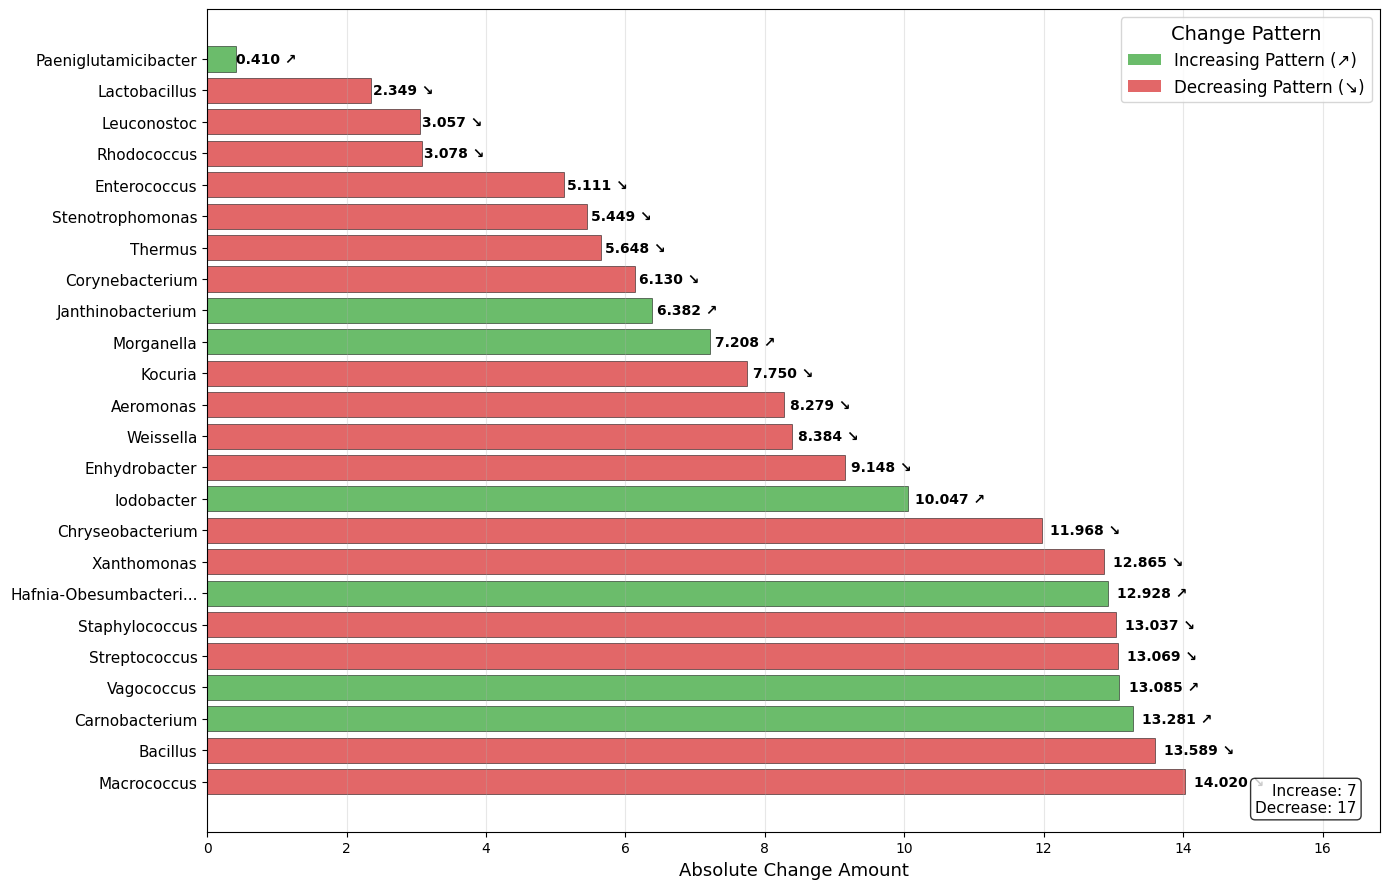

=== Genus Level VIP > 1.0 Features Bar Chart Completed (TPC) ===

=== Genus Level VIP > 1.0 Features Change Rate Statistics Summary (TPC) ===
----------------------------------------------------------------------
VIP Features: 24 features
Max Change: 14.020, Min Change: 0.410, Avg Change: 8.595
Increase: 7, Decrease: 17

Top 5 VIP Features by Change Rate:
 1. g__Macrococcus
    Change: -14.020 (Decreasing)
 2. g__Bacillus
    Change: -13.589 (Decreasing)
 3. g__Carnobacterium
    Change: +13.281 (Increasing)
 4. g__Vagococcus
    Change: +13.085 (Increasing)
 5. g__Streptococcus
    Change: -13.069 (Decreasing)


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Genus Level VIP > 1.0 Features 변화율 시각화 (TPC 기준만)
print("=== Genus Level VIP > 1.0 Features 변화율 시각화 (TPC 기준) ===\n")

# 색상 설정
plt.rcParams['axes.unicode_minus'] = False

level_name = 'Genus'

# VIP > 1.0 feature 리스트 추출 (TPC 기준)
vip_features = vip_over1_dict[level_name]['Feature'].tolist()

if not vip_features:
    print(f"{level_name}: VIP > 1.0 feature 없음, 스킵")
else:
    # 해당 레벨 데이터 가져오기
    level_data = get_level_data(level_name)
    df = level_data['data'].copy()
    df['Day'] = df['Description'].str.extract(r'A(\d+)', expand=False).astype(int)
    
    # VIP feature들의 일별 평균값 계산
    day_means = df.groupby('Day')[vip_features].mean()
    
    # 각 feature의 변화량 계산 (첫날 대비 마지막날)
    first_day = day_means.index.min()
    last_day = day_means.index.max()
    
    feature_changes = []
    for feature in vip_features:
        first_val = day_means.loc[first_day, feature]
        last_val = day_means.loc[last_day, feature]
        change_amount = last_val - first_val
        abs_change = abs(change_amount)
        
        feature_changes.append({
            'feature': feature,
            'change_amount': change_amount,
            'abs_change': abs_change,
            'trend': 'Increasing' if change_amount > 0 else 'Decreasing'
        })
    
    # 절댓값 변화량으로 정렬
    feature_changes.sort(key=lambda x: x['abs_change'], reverse=True)
    
    # Figure 생성 (title 제거)
    fig, ax = plt.subplots(1, 1, figsize=(14, 9))
    
    # 변화율 데이터 정리
    feature_names = [feat['feature'] for feat in feature_changes]
    abs_changes = [feat['abs_change'] for feat in feature_changes]
    change_amounts = [feat['change_amount'] for feat in feature_changes]
    trends = [feat['trend'] for feat in feature_changes]
    
    # Feature 이름 축약
    short_names = []
    for name in feature_names:
        short_name = name.replace('g__', '').replace('f__', '').replace('o__', '').replace('c__', '').replace('p__', '')
        if len(short_name) > 20:
            short_name = short_name[:20] + '...'
        short_names.append(short_name)
    
    # 바 차트 생성 (변화량 기준, 증가/감소 색상 구분)
    bar_colors = ['#2ca02c' if change > 0 else '#d62728' for change in change_amounts]
    
    bars = ax.barh(range(len(feature_names)), abs_changes, 
                   color=bar_colors, alpha=0.7, edgecolor='black', linewidth=0.5)
    
    # Y축 라벨 설정
    ax.set_yticks(range(len(feature_names)))
    ax.set_yticklabels(short_names, fontsize=11)
    
    # 축 라벨
    ax.set_xlabel('Absolute Change Amount', fontsize=13)
    
    # 값 표시 (바 끝에)
    for i, (bar, change, trend) in enumerate(zip(bars, change_amounts, trends)):
        width = bar.get_width()
        # 증가/감소 화살표 표시
        arrow = '↗' if change > 0 else '↘'
        ax.text(width + width*0.01, bar.get_y() + bar.get_height()/2, 
                f'{width:.3f} {arrow}', 
                ha='left', va='center', fontsize=10, fontweight='bold')
    
    # Grid 추가
    ax.grid(True, alpha=0.3, axis='x')
    ax.set_xlim(0, max(abs_changes) * 1.2)
    
    # 범례 추가 (위쪽으로 이동)
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, facecolor='#2ca02c', alpha=0.7, label='Increasing Pattern (↗)'),
        plt.Rectangle((0, 0), 1, 1, facecolor='#d62728', alpha=0.7, label='Decreasing Pattern (↘)')
    ]
    
    ax.legend(handles=legend_elements, loc='upper right', fontsize=12, 
              title='Change Pattern', title_fontsize=14)
    
    # 통계 정보 추가 (아래쪽으로 이동)
    increase_count = sum(1 for change in change_amounts if change > 0)
    decrease_count = len(change_amounts) - increase_count
    
    ax.text(0.98, 0.02, f'Increase: {increase_count}\nDecrease: {decrease_count}', 
            transform=ax.transAxes, fontsize=11, 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
            verticalalignment='bottom', horizontalalignment='right')
    
    plt.tight_layout()
    plt.show()
    
    print("=== Genus Level VIP > 1.0 Features Bar Chart Completed (TPC) ===\n")
    
    # 변화율 통계 요약
    print("=== Genus Level VIP > 1.0 Features Change Rate Statistics Summary (TPC) ===")
    print("-" * 70)
    
    max_change = max(abs_changes)
    min_change = min(abs_changes)
    avg_change = np.mean(abs_changes)
    
    print(f"VIP Features: {len(vip_features)} features")
    print(f"Max Change: {max_change:.3f}, Min Change: {min_change:.3f}, Avg Change: {avg_change:.3f}")
    print(f"Increase: {increase_count}, Decrease: {decrease_count}")
    print()
    
    print("Top 5 VIP Features by Change Rate:")
    for i, feat in enumerate(feature_changes[:5], 1):
        print(f"{i:2d}. {feat['feature']}")
        print(f"    Change: {feat['change_amount']:+.3f} ({feat['trend']})")
    
    print("=" * 70)

## Paper용 차트 figure

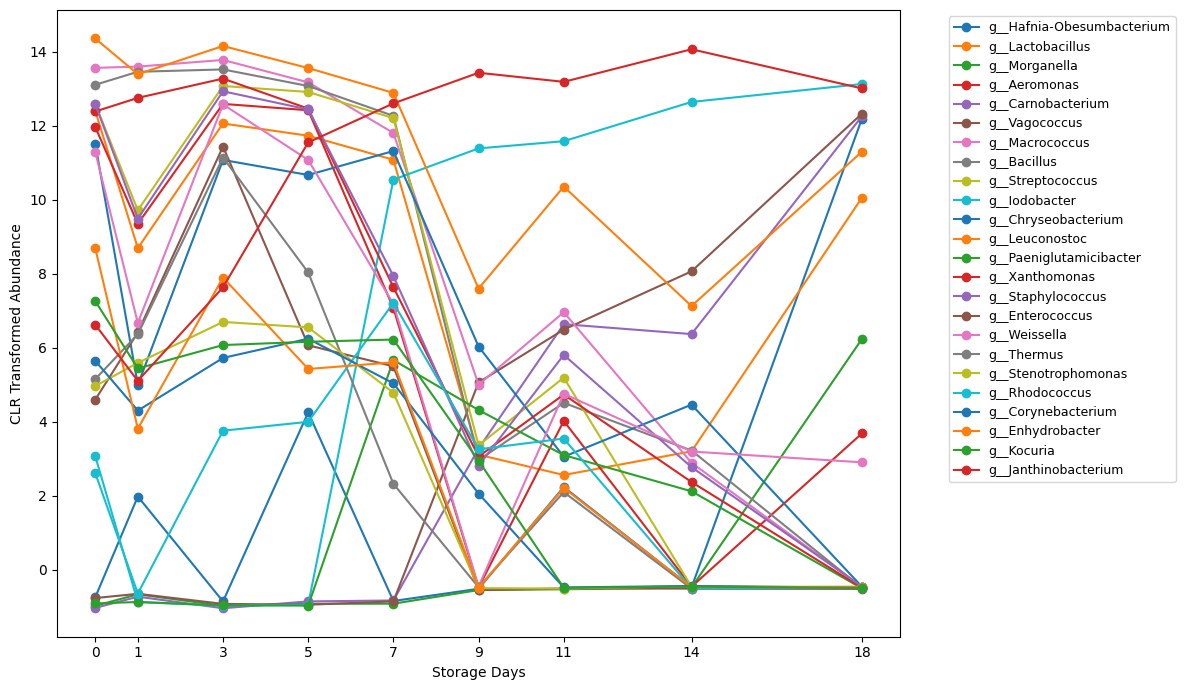

In [7]:
import matplotlib.pyplot as plt

# Genus level 데이터 불러오기
level_name = 'Genus'
level_data = get_level_data(level_name)
df = level_data['data'].copy()
df['Day'] = df['Description'].str.extract(r'A(\d+)', expand=False).astype(int)

# VIP > 1.0 Feature 리스트
vip_features = vip_over1_dict[level_name]['Feature'].tolist()

# x축 Day 지정
day_order = [0, 1, 3, 5, 7, 9, 11, 14, 18]

# 일별 평균 CLR abundance 계산 및 x축 맞추기
plot_df = df[['Day'] + vip_features].groupby('Day').mean().reindex(day_order)

plt.figure(figsize=(12, 7))
for feat in vip_features:
    plt.plot(plot_df.index, plot_df[feat], marker='o', label=feat)


plt.xlabel('Storage Days')
plt.ylabel('CLR Transformed Abundance')
plt.xticks(day_order)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

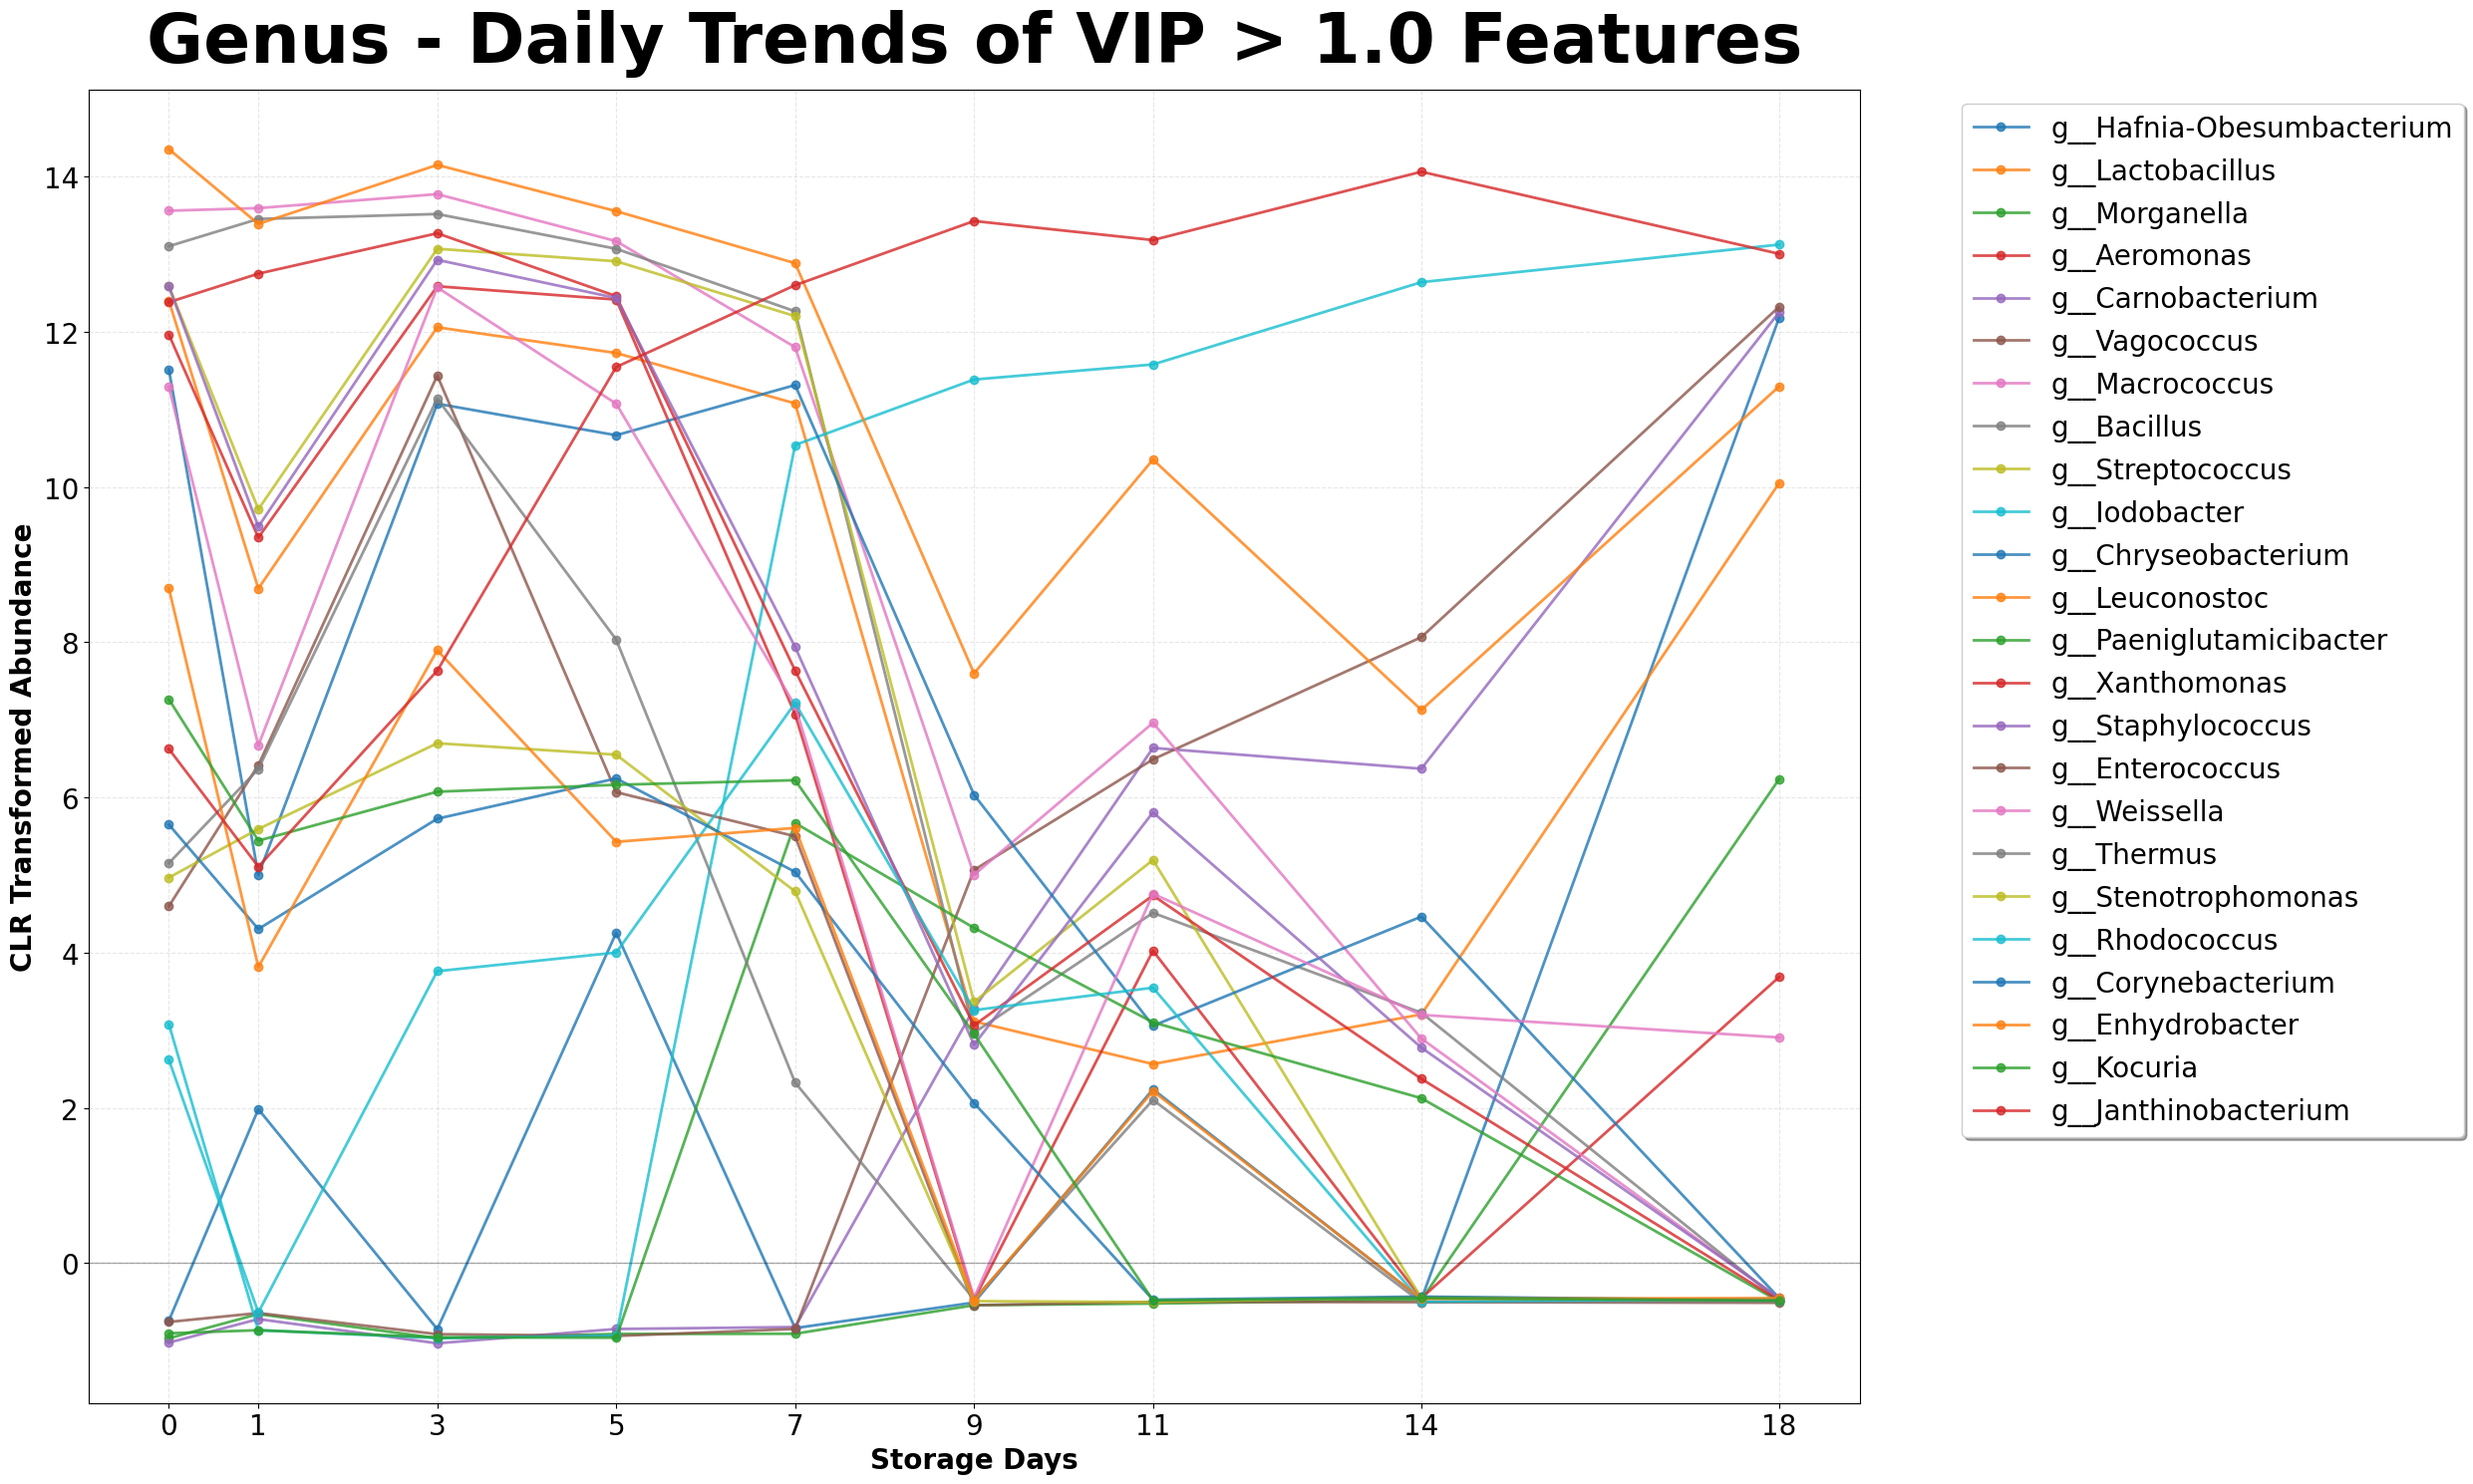


=== Genus Level VIP > 1.0 Features 일별 변화 엑셀 파일 생성 ===
✅ Genus Level VIP > 1.0 Features 일별 변화 엑셀 파일이 저장되었습니다:
📁 파일 경로: /Users/taehokim/lab/BRL_AI/BRL_final/CLR_code/Genus_VIP_Features_Daily_Trends_TPC.xlsx

📊 저장된 시트 정보:
   • 0_README: 분석 개요 및 시트 설명
   • 1_VIP_Info: VIP > 1.0 features 기본 정보
   • 2_Daily_Means_Selected: 선택된 day의 일별 평균값
   • 3_Daily_Means_All: 모든 day의 일별 평균값
   • 4_Change_Analysis: 변화량 분석 (Day 0 vs Day 18)
   • 5_Sample_Data: 전체 샘플 데이터
   • 6_Statistics: 기술통계량
   • 7_Correlation: 상관관계 매트릭스

📈 VIP Features 요약:
   • VIP > 1.0 Features 수: 24개
   • 총 샘플 수: 270
   • 저장 기간: 0 - 18일
   • 증가 패턴: 7개
   • 감소 패턴: 17개
   • 최대 VIP Score: 3.971
   • 평균 VIP Score: 1.893



In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Genus level 데이터 불러오기
level_name = 'Genus'
level_data = get_level_data(level_name)
df = level_data['data'].copy()
df['Day'] = df['Description'].str.extract(r'A(\d+)', expand=False).astype(int)

# VIP > 1.0 Feature 리스트
vip_features = vip_over1_dict[level_name]['Feature'].tolist()

# x축 Day 지정
day_order = [0, 1, 3, 5, 7, 9, 11, 14, 18]

# 일별 평균 CLR abundance 계산 및 x축 맞추기
plot_df = df[['Day'] + vip_features].groupby('Day').mean().reindex(day_order)

plt.figure(figsize=(25, 15))  # Figure 크기
for feat in vip_features:
    plt.plot(plot_df.index, plot_df[feat], marker='o', linewidth=2, markersize=6, label=feat, alpha=0.8)

plt.title('Genus - Daily Trends of VIP > 1.0 Features', fontsize=50, fontweight='bold', pad=20, loc='center', x=0.5)
plt.xlabel('Storage Days', fontsize=20, fontweight='bold')
plt.ylabel('CLR Transformed Abundance', fontsize=20, fontweight='bold')
plt.xticks(day_order, fontsize=20)
plt.yticks(fontsize=20)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=20, frameon=True, fancybox=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)
plt.tight_layout()
plt.show()

# Genus Level VIP > 1.0 Features 일별 변화 엑셀 파일 생성
print("\n=== Genus Level VIP > 1.0 Features 일별 변화 엑셀 파일 생성 ===")

# 1. VIP > 1.0 Features 기본 정보 시트
vip_info_list = []
vip_df = vip_over1_dict[level_name]
for i, row in vip_df.iterrows():
    vip_info_list.append({
        'Rank': i + 1,
        'Feature_Name': row['Feature'],
        'VIP_Score': row['VIP_Score'],
        'Importance_Level': 'Very Important' if row['VIP_Score'] > 1.0 else 'Moderate'
    })

vip_info_df = pd.DataFrame(vip_info_list)

# 2. 일별 평균 CLR abundance 시트 (전체 day)
day_means_all = df[['Day'] + vip_features].groupby('Day').mean()
day_means_all_reset = day_means_all.reset_index()

# 3. 지정된 day만의 평균 CLR abundance 시트
day_means_selected = plot_df.reset_index()
day_means_selected.columns.name = None

# 4. 전체 샘플 데이터 (VIP features만)
sample_data_vip = df[['Description', 'Day', 'TPC (log CFU/g)', 'TBARS'] + vip_features].copy()

# 5. 변화량 분석 시트 (첫날 대비 마지막날)
change_analysis_list = []
first_day = day_means_all.index.min()
last_day = day_means_all.index.max()

for feature in vip_features:
    first_val = day_means_all.loc[first_day, feature]
    last_val = day_means_all.loc[last_day, feature]
    change_amount = last_val - first_val
    abs_change = abs(change_amount)
    percent_change = (change_amount / abs(first_val)) * 100 if first_val != 0 else 0
    
    change_analysis_list.append({
        'Feature_Name': feature,
        'Day_0_Value': first_val,
        'Day_18_Value': last_val,
        'Change_Amount': change_amount,
        'Absolute_Change': abs_change,
        'Percent_Change': percent_change,
        'Trend': 'Increasing' if change_amount > 0 else 'Decreasing',
        'Min_Day': day_means_all[feature].idxmin(),
        'Max_Day': day_means_all[feature].idxmax(),
        'Min_Value': day_means_all[feature].min(),
        'Max_Value': day_means_all[feature].max(),
        'Value_Range': day_means_all[feature].max() - day_means_all[feature].min()
    })

change_analysis_df = pd.DataFrame(change_analysis_list)
change_analysis_df = change_analysis_df.sort_values('Absolute_Change', ascending=False)

# 6. 통계 요약 시트
stats_list = []
for feature in vip_features:
    feature_data = df[feature]
    stats_list.append({
        'Feature_Name': feature,
        'Mean': feature_data.mean(),
        'Std': feature_data.std(),
        'Min': feature_data.min(),
        'Max': feature_data.max(),
        'Q25': feature_data.quantile(0.25),
        'Median': feature_data.median(),
        'Q75': feature_data.quantile(0.75),
        'Skewness': feature_data.skew(),
        'Kurtosis': feature_data.kurtosis(),
        'CV': feature_data.std() / feature_data.mean() if feature_data.mean() != 0 else 0
    })

stats_df = pd.DataFrame(stats_list)

# 7. 상관관계 매트릭스 시트
correlation_features = vip_features + ['TPC (log CFU/g)', 'TBARS']
correlation_df = df[correlation_features].corr()

# 엑셀 파일 저장
excel_file_path = "/Users/taehokim/lab/BRL_AI/BRL_final/CLR_code/Genus_VIP_Features_Daily_Trends_TPC.xlsx"

with pd.ExcelWriter(excel_file_path, engine='openpyxl') as writer:
    # 시트별 저장
    vip_info_df.to_excel(writer, sheet_name='1_VIP_Info', index=False)
    day_means_selected.to_excel(writer, sheet_name='2_Daily_Means_Selected', index=False)
    day_means_all_reset.to_excel(writer, sheet_name='3_Daily_Means_All', index=False)
    change_analysis_df.to_excel(writer, sheet_name='4_Change_Analysis', index=False)
    sample_data_vip.to_excel(writer, sheet_name='5_Sample_Data', index=False)
    stats_df.to_excel(writer, sheet_name='6_Statistics', index=False)
    correlation_df.to_excel(writer, sheet_name='7_Correlation', index=True)
    
    # README 시트 추가
    info_sheet = writer.book.create_sheet('0_README')
    info_data = [
        ['Sheet Name', 'Description'],
        ['1_VIP_Info', 'VIP > 1.0 features 기본 정보 (VIP Score, 중요도 등)'],
        ['2_Daily_Means_Selected', '선택된 저장일수(0,1,3,5,7,9,11,14,18)의 일별 평균값'],
        ['3_Daily_Means_All', '모든 저장일수의 일별 평균값'],
        ['4_Change_Analysis', '각 feature의 변화량 분석 (Day 0 vs Day 18)'],
        ['5_Sample_Data', '전체 샘플 데이터 (VIP features + TPC + TBARS)'],
        ['6_Statistics', '각 feature의 기술통계량'],
        ['7_Correlation', 'VIP features + TPC/TBARS 상관관계 매트릭스'],
        ['', ''],
        ['Analysis Info', ''],
        ['Analysis Type', 'TPC 기준 VIP > 1.0 Features'],
        ['Total VIP Features', len(vip_features)],
        ['Total Samples', len(df)],
        ['Storage Days', f"{min(df['Day'])} - {max(df['Day'])} days"],
        ['Selected Days', '0, 1, 3, 5, 7, 9, 11, 14, 18'],
        ['', ''],
        ['VIP Score Summary', ''],
        ['Max VIP Score', vip_df['VIP_Score'].max()],
        ['Min VIP Score', vip_df['VIP_Score'].min()],
        ['Mean VIP Score', vip_df['VIP_Score'].mean()],
        ['', ''],
        ['Change Pattern Summary', ''],
        ['Increasing Features', sum(1 for f in change_analysis_list if f['Change_Amount'] > 0)],
        ['Decreasing Features', sum(1 for f in change_analysis_list if f['Change_Amount'] < 0)],
        ['Max Absolute Change', max([f['Absolute_Change'] for f in change_analysis_list])],
        ['Min Absolute Change', min([f['Absolute_Change'] for f in change_analysis_list])]
    ]
    
    for row_idx, row_data in enumerate(info_data, 1):
        for col_idx, cell_value in enumerate(row_data, 1):
            info_sheet.cell(row=row_idx, column=col_idx, value=cell_value)

print(f"✅ Genus Level VIP > 1.0 Features 일별 변화 엑셀 파일이 저장되었습니다:")
print(f"📁 파일 경로: {excel_file_path}")
print(f"\n📊 저장된 시트 정보:")
print(f"   • 0_README: 분석 개요 및 시트 설명")
print(f"   • 1_VIP_Info: VIP > 1.0 features 기본 정보")
print(f"   • 2_Daily_Means_Selected: 선택된 day의 일별 평균값")
print(f"   • 3_Daily_Means_All: 모든 day의 일별 평균값")
print(f"   • 4_Change_Analysis: 변화량 분석 (Day 0 vs Day 18)")
print(f"   • 5_Sample_Data: 전체 샘플 데이터")
print(f"   • 6_Statistics: 기술통계량")
print(f"   • 7_Correlation: 상관관계 매트릭스")

print(f"\n📈 VIP Features 요약:")
print(f"   • VIP > 1.0 Features 수: {len(vip_features)}개")
print(f"   • 총 샘플 수: {len(df)}")
print(f"   • 저장 기간: {min(df['Day'])} - {max(df['Day'])}일")
print(f"   • 증가 패턴: {sum(1 for f in change_analysis_list if f['Change_Amount'] > 0)}개")
print(f"   • 감소 패턴: {sum(1 for f in change_analysis_list if f['Change_Amount'] < 0)}개")
print(f"   • 최대 VIP Score: {vip_df['VIP_Score'].max():.3f}")
print(f"   • 평균 VIP Score: {vip_df['VIP_Score'].mean():.3f}")

print("\n" + "="*80)

## PLS-DA

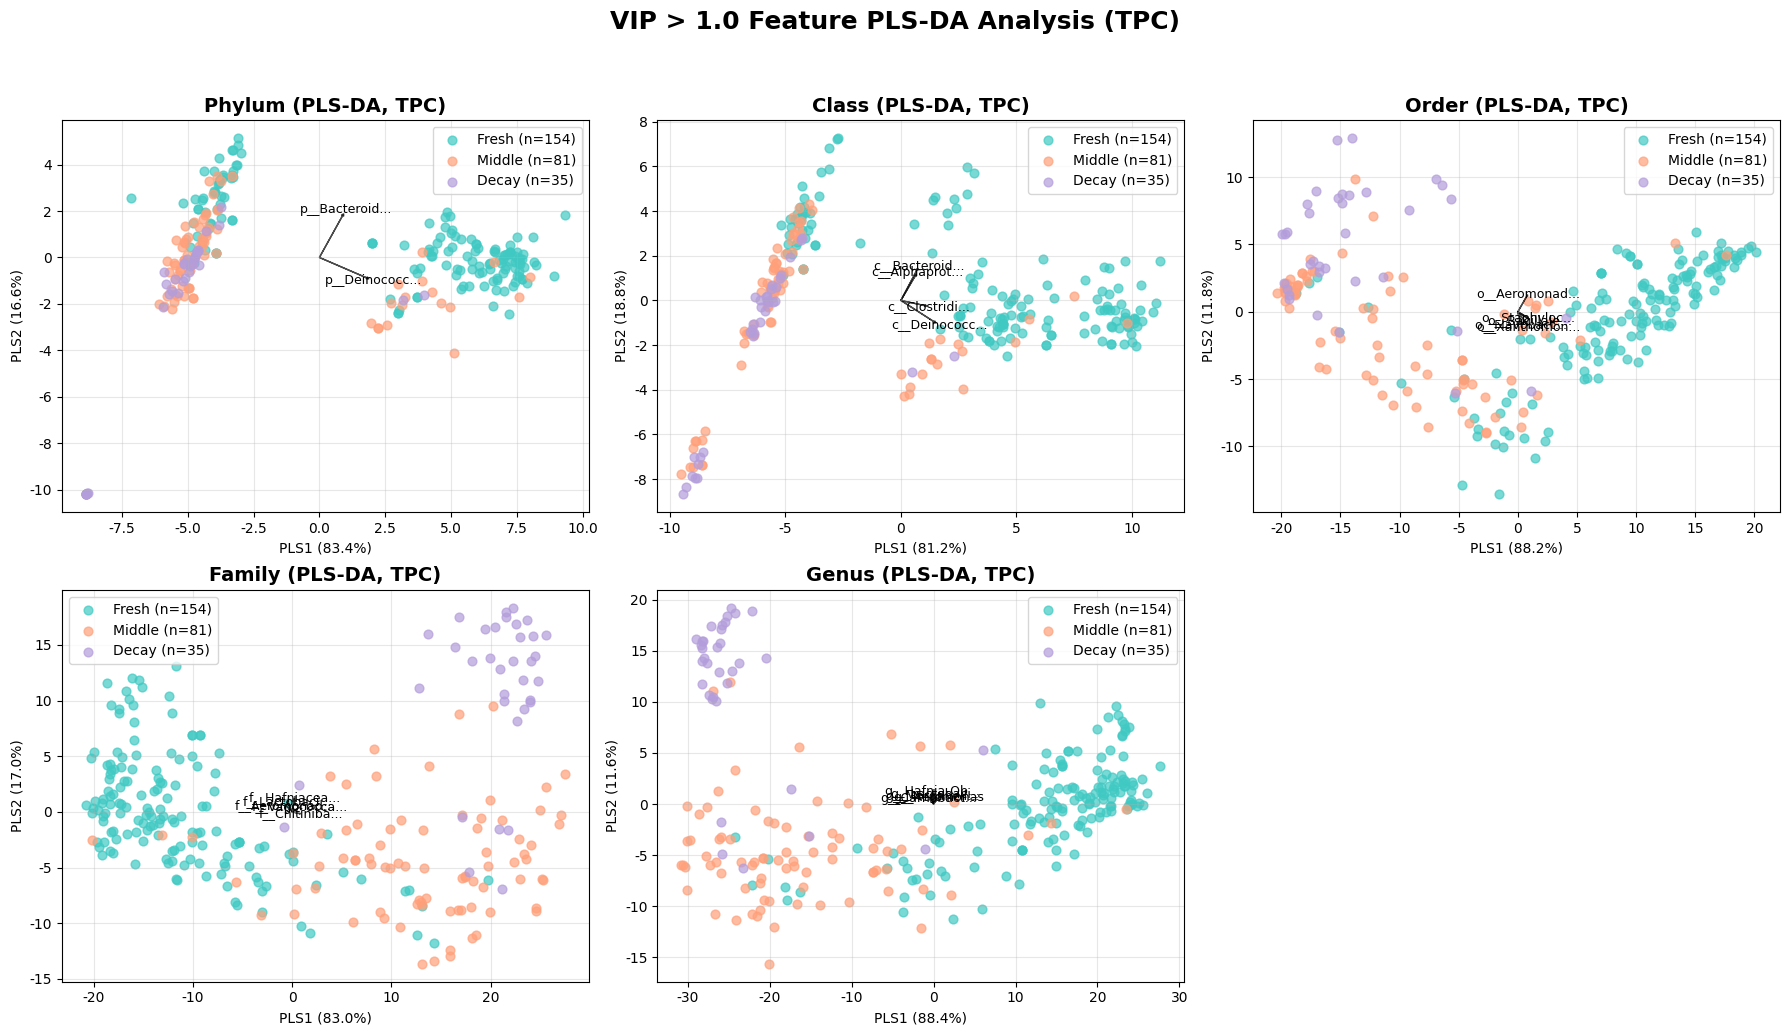

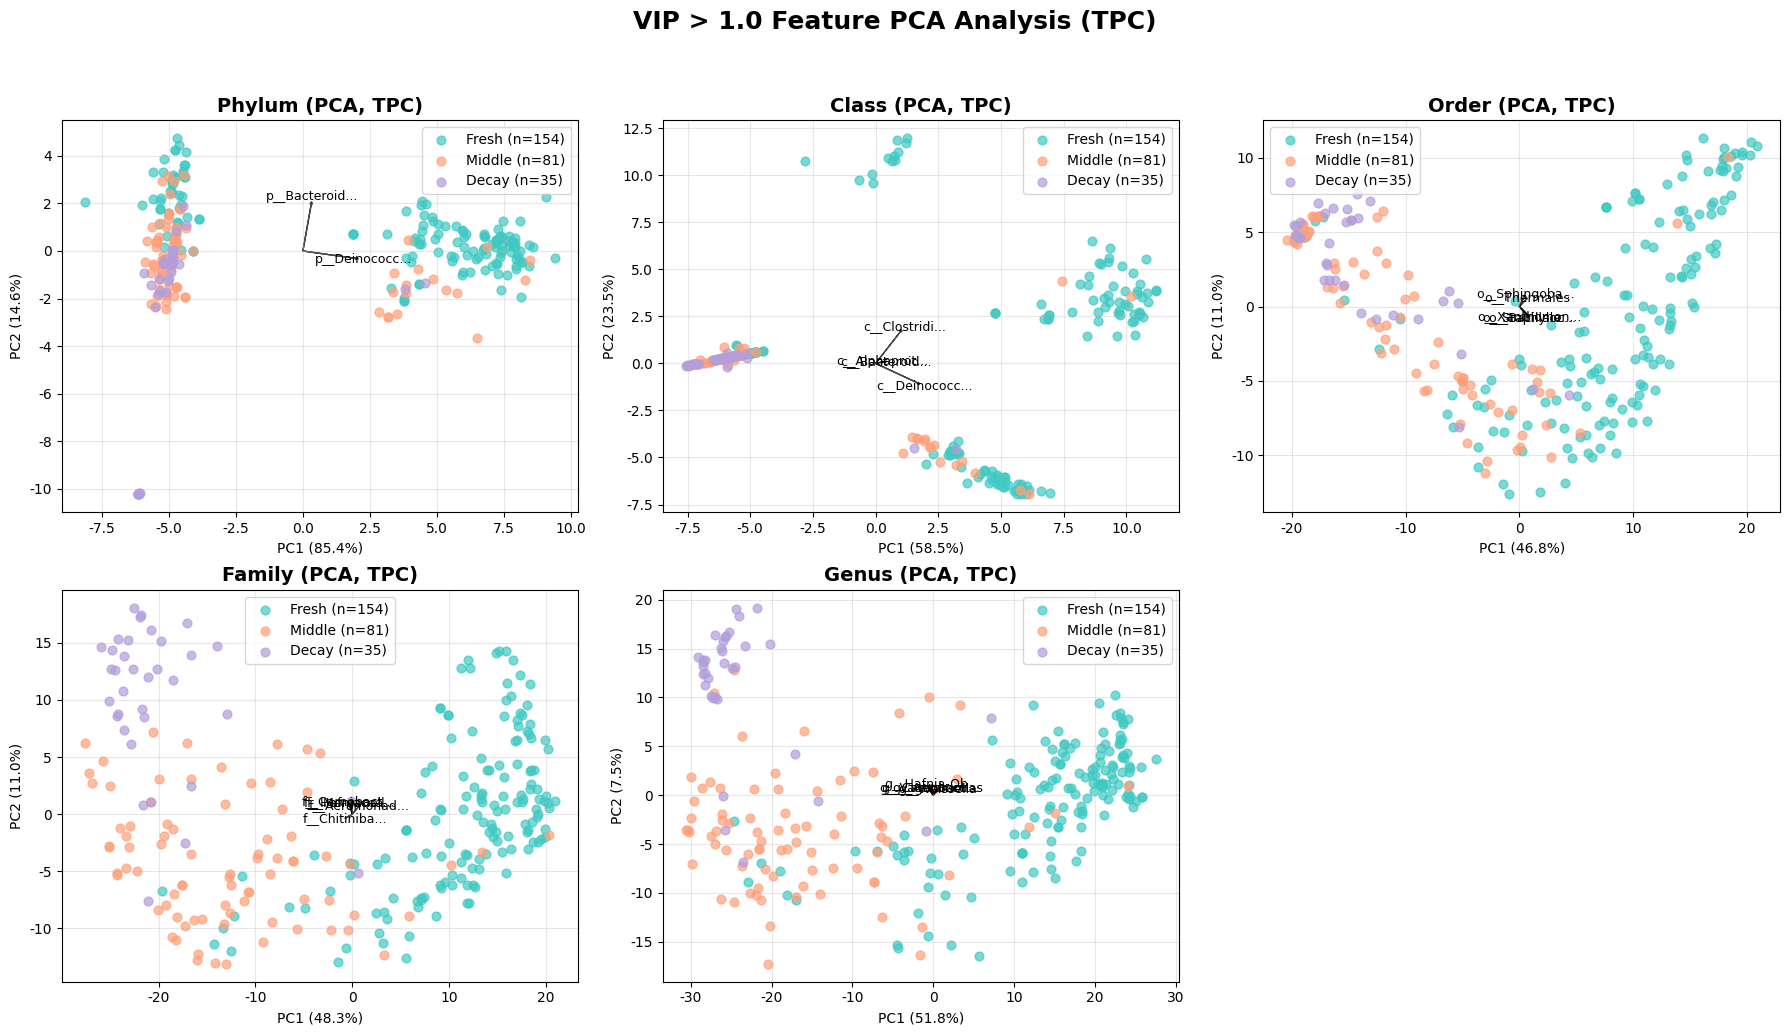

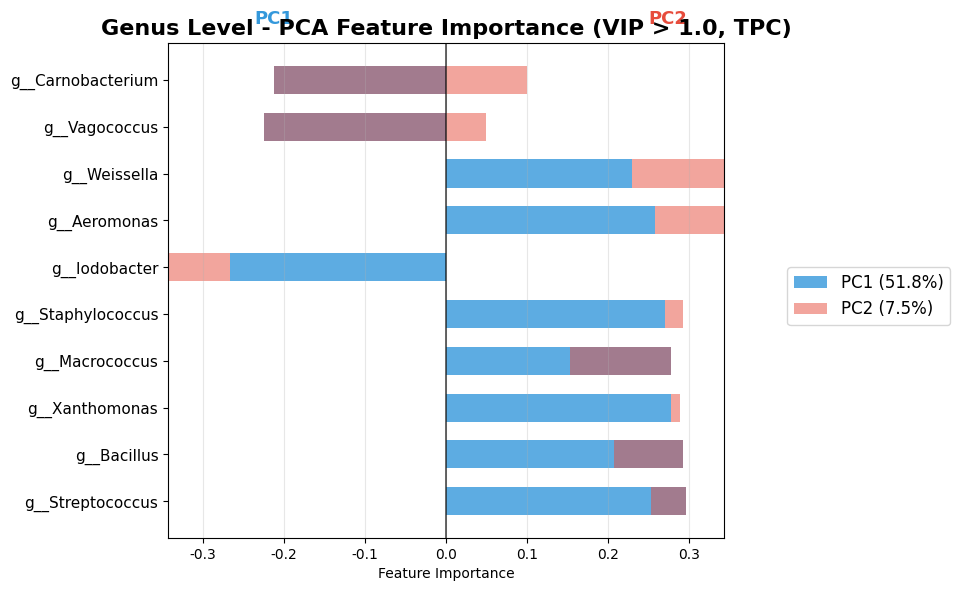

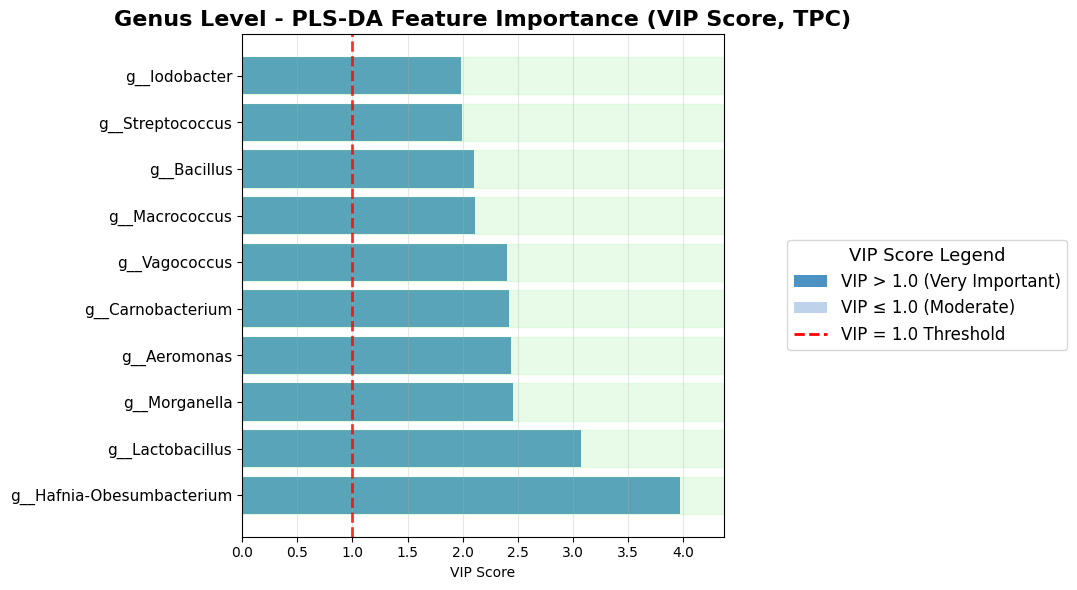

In [9]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 색상/라벨 변수 통일
colors = {0: "#40c9c3", 1: "#ffa07a", 2: "#b39ddb"}
label_names = {0: "Fresh", 1: "Middle", 2: "Decay"}

# 1. PLS-DA scatter (TPC 기준, 영어 텍스트)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
level_keys = list(vip_over1_dict.keys())
for idx, level_name in enumerate(level_keys):
    level_data = get_level_data(level_name)
    if level_data is None:
        print(f"{level_name}: No data, skipped")
        continue
    X = level_data['features']
    tpc = level_data['tpc']
    y = tpc_labeling(tpc)
    vip_features = vip_over1_dict[level_name]['Feature'].tolist()
    if not vip_features:
        print(f"{level_name}: No VIP > 1.0 feature, skipped")
        continue
    X_vip = X[vip_features]
    y_onehot = np.zeros((len(y), 3))
    for i in range(len(y)):
        y_onehot[i, y[i]] = 1
    plsda = PLSRegression(n_components=2, scale=False)
    X_pls = plsda.fit_transform(X_vip, y_onehot)[0]
    exp_var = np.var(X_pls, axis=0) / np.sum(np.var(X_pls, axis=0)) * 100
    ax = axes[idx]
    # --- scatter color specified ---
    for label in [0, 1, 2]:
        count = np.sum(y == label)
        ax.scatter(
            X_pls[y == label, 0], X_pls[y == label, 1],
            label=f"{label_names[label]} (n={count})", alpha=0.7, s=40, color=colors[label]
        )
    # --- scatter color specified ---
    loadings = plsda.x_weights_
    loading_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
    top_idx = np.argsort(loading_magnitudes)[-5:]
    for i in top_idx:
        ax.arrow(0, 0, loadings[i, 0]*2, loadings[i, 1]*2,
                 color='black', alpha=0.7, head_width=0.1, head_length=0.1)
        feat_name = vip_features[i]
        if len(feat_name) > 12:
            feat_name = feat_name[:12] + '...'
        ax.text(loadings[i, 0]*2.3, loadings[i, 1]*2.3, feat_name, fontsize=9, color='black', ha='center', va='center')
    ax.set_title(f"{level_name} (PLS-DA, TPC)", fontsize=14, fontweight='bold')
    ax.set_xlabel(f"PLS1 ({exp_var[0]:.1f}%)")
    ax.set_ylabel(f"PLS2 ({exp_var[1]:.1f}%)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='best')
for j in range(len(level_keys), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle("VIP > 1.0 Feature PLS-DA Analysis (TPC)", fontsize=18, fontweight='bold', y=1.03)
plt.show()

# 2. PCA scatter (TPC 기준, 영어 텍스트)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, level_name in enumerate(level_keys):
    level_data = get_level_data(level_name)
    if level_data is None:
        print(f"{level_name}: No data, skipped")
        continue
    X = level_data['features']
    tpc = level_data['tpc']
    y = tpc_labeling(tpc)
    vip_features = vip_over1_dict[level_name]['Feature'].tolist()
    if not vip_features:
        print(f"{level_name}: No VIP > 1.0 feature, skipped")
        continue
    X_vip = X[vip_features]
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_vip)
    exp_var = pca.explained_variance_ratio_ * 100
    ax = axes[idx]
    # --- scatter color specified ---
    for label in [0, 1, 2]:
        count = np.sum(y == label)
        ax.scatter(
            X_pca[y == label, 0], X_pca[y == label, 1],
            label=f"{label_names[label]} (n={count})", alpha=0.7, s=40, color=colors[label]
        )
    # --- scatter color specified ---
    loadings = pca.components_.T
    loading_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
    top_idx = np.argsort(loading_magnitudes)[-5:]
    for i in top_idx:
        ax.arrow(0, 0, loadings[i, 0]*2, loadings[i, 1]*2,
                 color='black', alpha=0.7, head_width=0.1, head_length=0.1)
        feat_name = vip_features[i]
        if len(feat_name) > 12:
            feat_name = feat_name[:12] + '...'
        ax.text(loadings[i, 0]*2.3, loadings[i, 1]*2.3, feat_name, fontsize=9, color='black', ha='center', va='center')
    ax.set_title(f"{level_name} (PCA, TPC)", fontsize=14, fontweight='bold')
    ax.set_xlabel(f"PC1 ({exp_var[0]:.1f}%)")
    ax.set_ylabel(f"PC2 ({exp_var[1]:.1f}%)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='best')
for j in range(len(level_keys), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle("VIP > 1.0 Feature PCA Analysis (TPC)", fontsize=18, fontweight='bold', y=1.03)
plt.show()

# 3. Genus level mirror bar chart (PCA, VIP Score, TPC 기준, 영어 텍스트)
level_name = 'Genus'
level_data = get_level_data(level_name)
vip_features = vip_over1_dict[level_name]['Feature'].tolist()
if vip_features:
    # PCA mirror bar chart (Top 10)
    X_vip = level_data['features'][vip_features]
    pca = PCA(n_components=2)
    pca.fit(X_vip)
    loadings = pca.components_.T
    exp_var = pca.explained_variance_ratio_ * 100
    pc1_loadings = loadings[:, 0]
    pc2_loadings = loadings[:, 1]
    feature_names = np.array(vip_features)
    top10_idx = np.argsort(np.abs(pc1_loadings))[-10:][::-1]
    top10_features = feature_names[top10_idx]
    top10_pc1 = pc1_loadings[top10_idx]
    top10_pc2 = pc2_loadings[top10_idx]
    ind = np.arange(len(top10_features))
    height = 0.6
    fig, ax = plt.subplots(figsize=(8, 6))
    bars1 = ax.barh(ind, top10_pc1, height, color='#3498db', label=f'PC1 ({exp_var[0]:.1f}%)', alpha=0.8)
    bars2 = ax.barh(ind, top10_pc2, height, color='#e74c3c', label=f'PC2 ({exp_var[1]:.1f}%)', left=top10_pc1, alpha=0.5)
    ax.set_yticks(ind)
    ax.set_yticklabels(top10_features, fontsize=11)
    ax.set_xlabel('Feature Importance')
    ax.set_title('Genus Level - PCA Feature Importance (VIP > 1.0, TPC)', fontsize=16, fontweight='bold')
    ax.axvline(0, color='black', linewidth=1.2, alpha=0.7)
    fig.legend(loc='center left', bbox_to_anchor=(0.98, 0.5), fontsize=12)
    ax.text(-max(abs(top10_pc1))*0.8, len(top10_features)+0.2, 'PC1', color='#3498db', fontsize=13, fontweight='bold')
    ax.text(max(abs(top10_pc2))*0.8, len(top10_features)+0.2, 'PC2', color='#e74c3c', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    max_val = max(np.max(np.abs(top10_pc1)), np.max(np.abs(top10_pc2)))
    ax.set_xlim(-max_val*1.1, max_val*1.1)
    plt.tight_layout(rect=[0, 0, 0.93, 1])
    plt.show()

    # VIP Score mirror bar chart (Top 10)
    vip_df = vip_over1_dict[level_name]
    top10_vip = vip_df.sort_values('VIP_Score', ascending=False).head(10)
    top10_features_vip = top10_vip['Feature'].values
    top10_scores = top10_vip['VIP_Score'].values
    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.barh(np.arange(10), top10_scores, color=['#1f77b4' if v > 1.0 else '#aec7e8' for v in top10_scores], alpha=0.8)
    ax.set_yticks(np.arange(10))
    ax.set_yticklabels(top10_features_vip, fontsize=11)
    ax.set_xlabel('VIP Score')
    ax.set_title('Genus Level - PLS-DA Feature Importance (VIP Score, TPC)', fontsize=16, fontweight='bold')
    ax.axvline(1.0, color='red', linestyle='--', linewidth=2, alpha=0.8)
    ax.grid(True, alpha=0.3, axis='x')
    for i in range(np.sum(top10_scores > 1.0)):
        ax.axhspan(i-0.4, i+0.4, alpha=0.2, color='lightgreen')
    ax.set_xlim(0, max(top10_scores)*1.1)
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, facecolor='#1f77b4', alpha=0.8, label='VIP > 1.0 (Very Important)'),
        plt.Rectangle((0, 0), 1, 1, facecolor='#aec7e8', alpha=0.8, label='VIP ≤ 1.0 (Moderate)'),
        plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='VIP = 1.0 Threshold')
    ]
    fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0.98, 0.5), fontsize=12, title='VIP Score Legend', title_fontsize=13)
    plt.tight_layout(rect=[0, 0, 0.93, 1])
    plt.show()

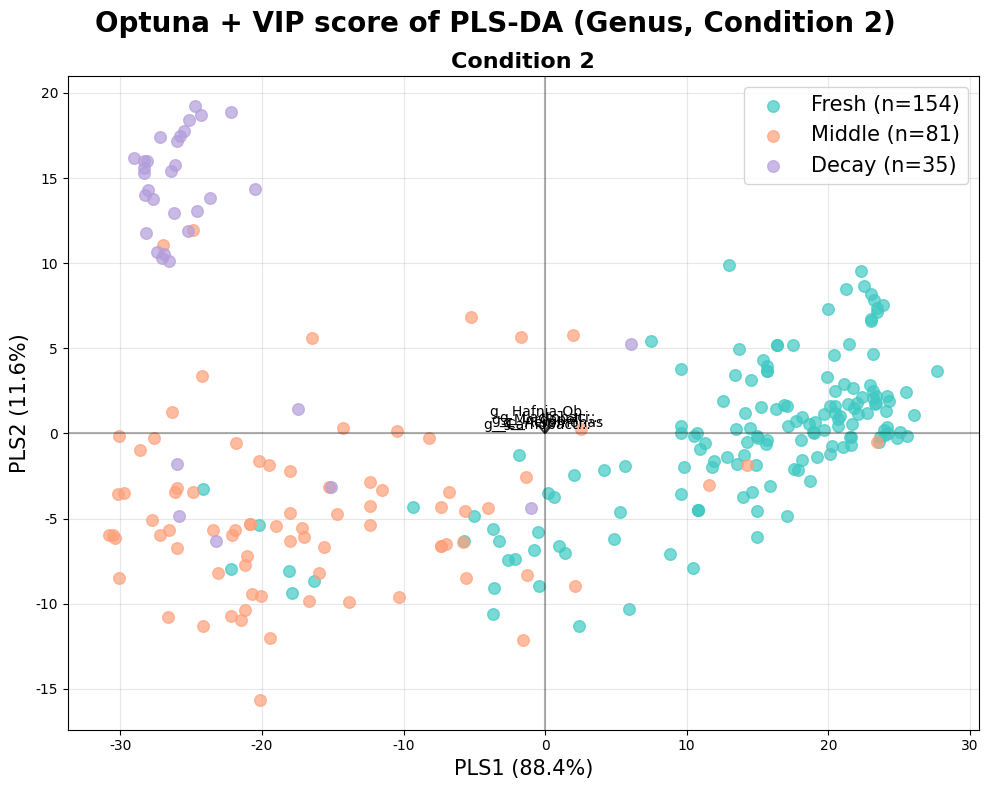

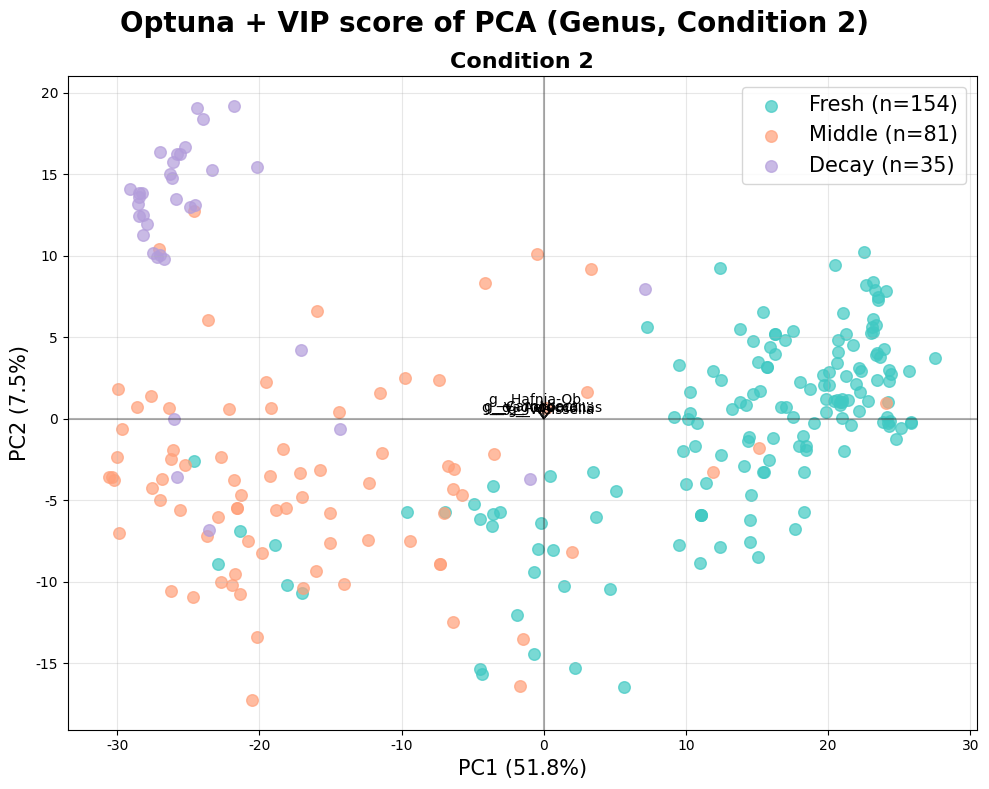

In [10]:
# Genus Level만 PLS-DA 단독 시각화 (VIP > 1.0, TPC 기준, Condition 2, Optuna + VIP score of PLS-DA)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression

colors = {0: "#40c9c3", 1: "#ffa07a", 2: "#b39ddb"}
label_names = {0: "Fresh", 1: "Middle", 2: "Decay"}

level_name = 'Genus'
level_data = get_level_data(level_name)
vip_features = vip_over1_dict[level_name]['Feature'].tolist()

if vip_features:
    X_vip = level_data['features'][vip_features]
    tpc = level_data['tpc']
    y = tpc_labeling(tpc)
    y_onehot = np.zeros((len(y), 3))
    for i in range(len(y)):
        y_onehot[i, y[i]] = 1
    plsda = PLSRegression(n_components=2, scale=False)
    X_pls = plsda.fit_transform(X_vip, y_onehot)[0]
    exp_var = np.var(X_pls, axis=0) / np.sum(np.var(X_pls, axis=0)) * 100

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    fig.suptitle('Optuna + VIP score of PLS-DA (Genus, Condition 2)', fontsize=20, fontweight='bold', y=0.98)

    for label in [0, 1, 2]:
        mask = y == label
        if np.sum(mask) > 0:
            ax.scatter(X_pls[mask, 0], X_pls[mask, 1],
                       c=colors[label], alpha=0.7, s=70,
                       label=f'{label_names[label]} (n={np.sum(mask)})')

    loadings = plsda.x_weights_
    loading_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
    top_idx = np.argsort(loading_magnitudes)[-5:]
    for i in top_idx:
        ax.arrow(0, 0, loadings[i, 0]*2, loadings[i, 1]*2,
                 color='black', alpha=0.7, head_width=0.12, head_length=0.12)
        feat_name = vip_features[i]
        if len(feat_name) > 12:
            feat_name = feat_name[:12] + '...'
        ax.text(loadings[i, 0]*2.3, loadings[i, 1]*2.3, feat_name, fontsize=10, color='black', ha='center', va='center')

    ax.set_xlabel(f'PLS1 ({exp_var[0]:.1f}%)', fontsize=15)
    ax.set_ylabel(f'PLS2 ({exp_var[1]:.1f}%)', fontsize=15)
    ax.set_title('Condition 2', fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    ax.legend(fontsize=15, loc='best')
    plt.tight_layout()
    plt.show()

# Genus Level만 PCA 단독 시각화 (VIP > 1.0, TPC 기준, Condition 2, Optuna + VIP score of PCA)

from sklearn.decomposition import PCA

if vip_features:
    X_vip = level_data['features'][vip_features]
    tpc = level_data['tpc']
    y = tpc_labeling(tpc)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_vip)
    exp_var = pca.explained_variance_ratio_ * 100

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    fig.suptitle('Optuna + VIP score of PCA (Genus, Condition 2)', fontsize=20, fontweight='bold', y=0.98)

    for label in [0, 1, 2]:
        mask = y == label
        if np.sum(mask) > 0:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                       c=colors[label], alpha=0.7, s=70,
                       label=f'{label_names[label]} (n={np.sum(mask)})')

    loadings = pca.components_.T
    loading_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
    top_idx = np.argsort(loading_magnitudes)[-5:]
    for i in top_idx:
        ax.arrow(0, 0, loadings[i, 0]*2, loadings[i, 1]*2,
                 color='black', alpha=0.7, head_width=0.12, head_length=0.12)
        feat_name = vip_features[i]
        if len(feat_name) > 12:
            feat_name = feat_name[:12] + '...'
        ax.text(loadings[i, 0]*2.3, loadings[i, 1]*2.3, feat_name, fontsize=10, color='black', ha='center', va='center')

    ax.set_xlabel(f'PC1 ({exp_var[0]:.1f}%)', fontsize=15)
    ax.set_ylabel(f'PC2 ({exp_var[1]:.1f}%)', fontsize=15)
    ax.set_title('Condition 2', fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    ax.legend(fontsize=15, loc='best')
    plt.tight_layout()
    plt.show()

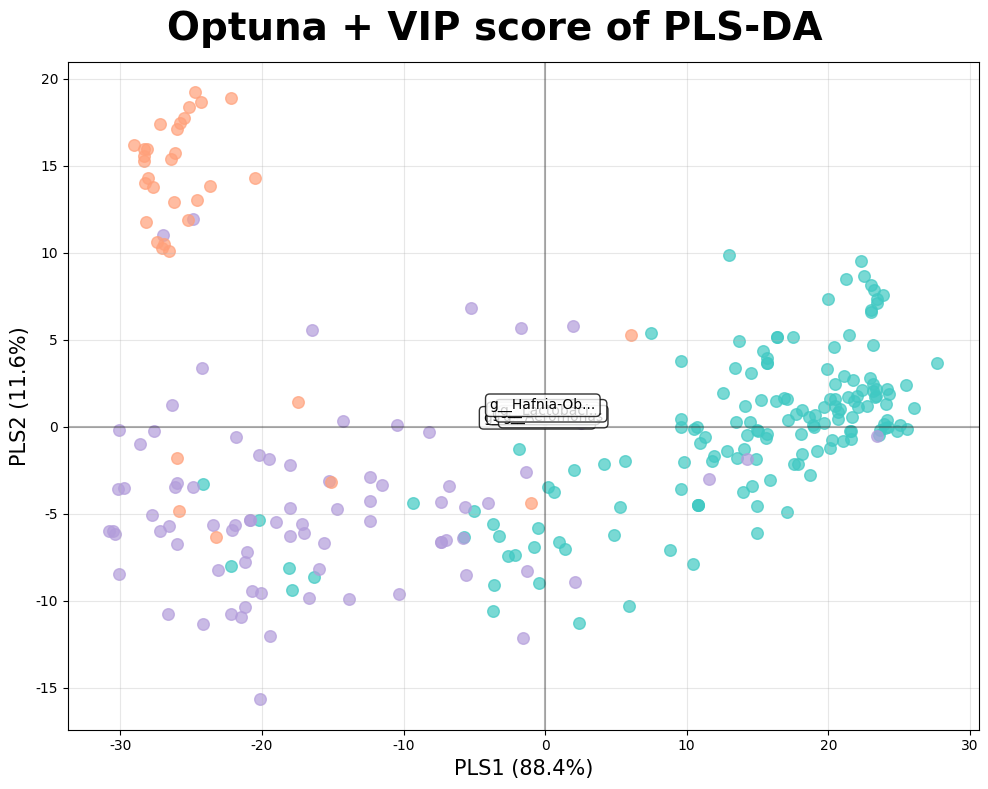

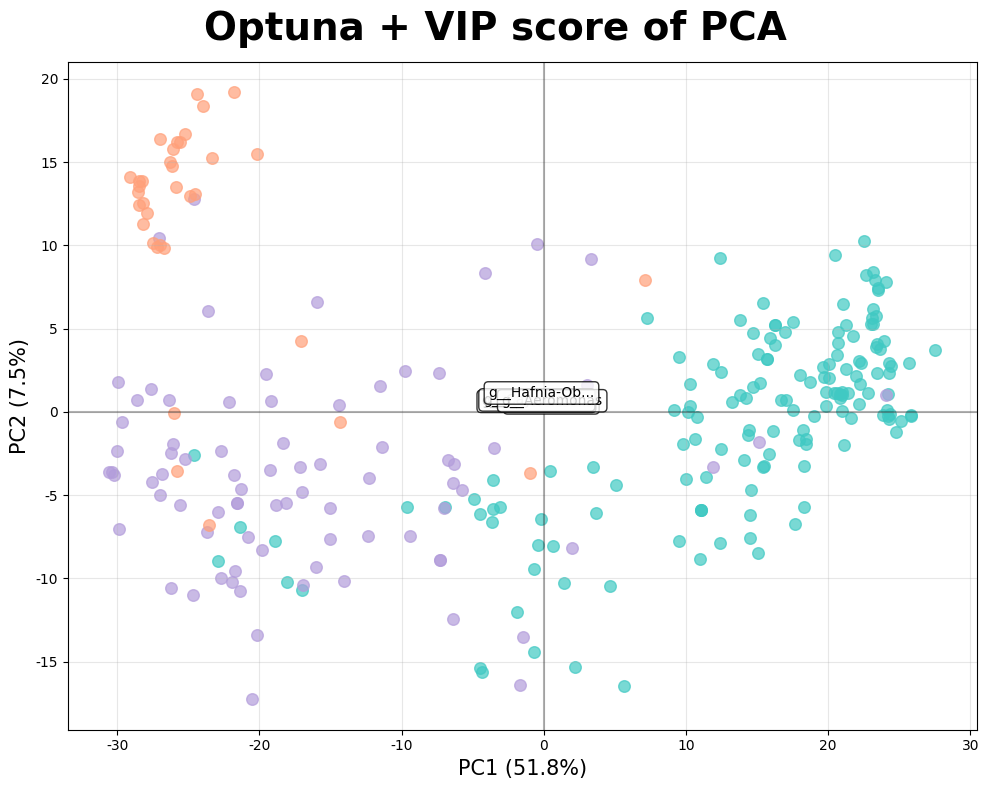

In [11]:
# Genus Level만 PLS-DA 단독 시각화 (VIP > 1.0, TPC 기준, Condition 2, Optuna + VIP score of PLS-DA)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression

colors = {0: "#40c9c3", 1: "#b39ddb", 2: "#ffa07a"}
label_names = {0: "Fresh", 1: "Middle", 2: "Spoilage"}  # Decay -> Spoilage

level_name = 'Genus'
level_data = get_level_data(level_name)
vip_features = vip_over1_dict[level_name]['Feature'].tolist()

if vip_features:
    X_vip = level_data['features'][vip_features]
    tpc = level_data['tpc']
    y = tpc_labeling(tpc)
    y_onehot = np.zeros((len(y), 3))
    for i in range(len(y)):
        y_onehot[i, y[i]] = 1
    plsda = PLSRegression(n_components=2, scale=False)
    X_pls = plsda.fit_transform(X_vip, y_onehot)[0]
    exp_var = np.var(X_pls, axis=0) / np.sum(np.var(X_pls, axis=0)) * 100

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    fig.suptitle('Optuna + VIP score of PLS-DA', fontsize=28, fontweight='bold', y=0.98)

    # 순서: Fresh, Middle, Spoilage
    for label in [0, 1, 2]:
        mask = y == label
        if np.sum(mask) > 0:
            ax.scatter(X_pls[mask, 0], X_pls[mask, 1],
                       c=colors[label], alpha=0.7, s=70,
                       label=f'{label_names[label]} (n={np.sum(mask)})')

    loadings = plsda.x_weights_
    loading_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
    top_idx = np.argsort(loading_magnitudes)[-5:]
    for i in top_idx:
        ax.arrow(0, 0, loadings[i, 0]*2, loadings[i, 1]*2,
                 fc='black', ec='black', alpha=0.7, head_width=0.12, head_length=0.12)  # 테두리 추가
        feat_name = vip_features[i]
        if len(feat_name) > 12:
            feat_name = feat_name[:12] + '...'
        ax.text(loadings[i, 0]*2.3, loadings[i, 1]*2.3, feat_name, fontsize=10, color='black', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.8))  # 텍스트 테두리 추가

    ax.set_xlabel(f'PLS1 ({exp_var[0]:.1f}%)', fontsize=15)
    ax.set_ylabel(f'PLS2 ({exp_var[1]:.1f}%)', fontsize=15)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Genus Level만 PCA 단독 시각화 (VIP > 1.0, TPC 기준, Condition 2, Optuna + VIP score of PCA)

from sklearn.decomposition import PCA

if vip_features:
    X_vip = level_data['features'][vip_features]
    tpc = level_data['tpc']
    y = tpc_labeling(tpc)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_vip)
    exp_var = pca.explained_variance_ratio_ * 100

    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    fig.suptitle('Optuna + VIP score of PCA', fontsize=28, fontweight='bold', y=0.98)

    # 순서: Fresh, Middle, Spoilage
    for label in [0, 1, 2]:
        mask = y == label
        if np.sum(mask) > 0:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                       c=colors[label], alpha=0.7, s=70,
                       label=f'{label_names[label]} (n={np.sum(mask)})')

    loadings = pca.components_.T
    loading_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
    top_idx = np.argsort(loading_magnitudes)[-5:]
    for i in top_idx:
        ax.arrow(0, 0, loadings[i, 0]*2, loadings[i, 1]*2,
                 fc='black', ec='black', alpha=0.7, head_width=0.12, head_length=0.12)  # 테두리 추가
        feat_name = vip_features[i]
        if len(feat_name) > 12:
            feat_name = feat_name[:12] + '...'
        ax.text(loadings[i, 0]*2.3, loadings[i, 1]*2.3, feat_name, fontsize=10, color='black', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black', alpha=0.8))  # 텍스트 테두리 추가

    ax.set_xlabel(f'PC1 ({exp_var[0]:.1f}%)', fontsize=15)
    ax.set_ylabel(f'PC2 ({exp_var[1]:.1f}%)', fontsize=15)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    plt.tight_layout()
    plt.show()

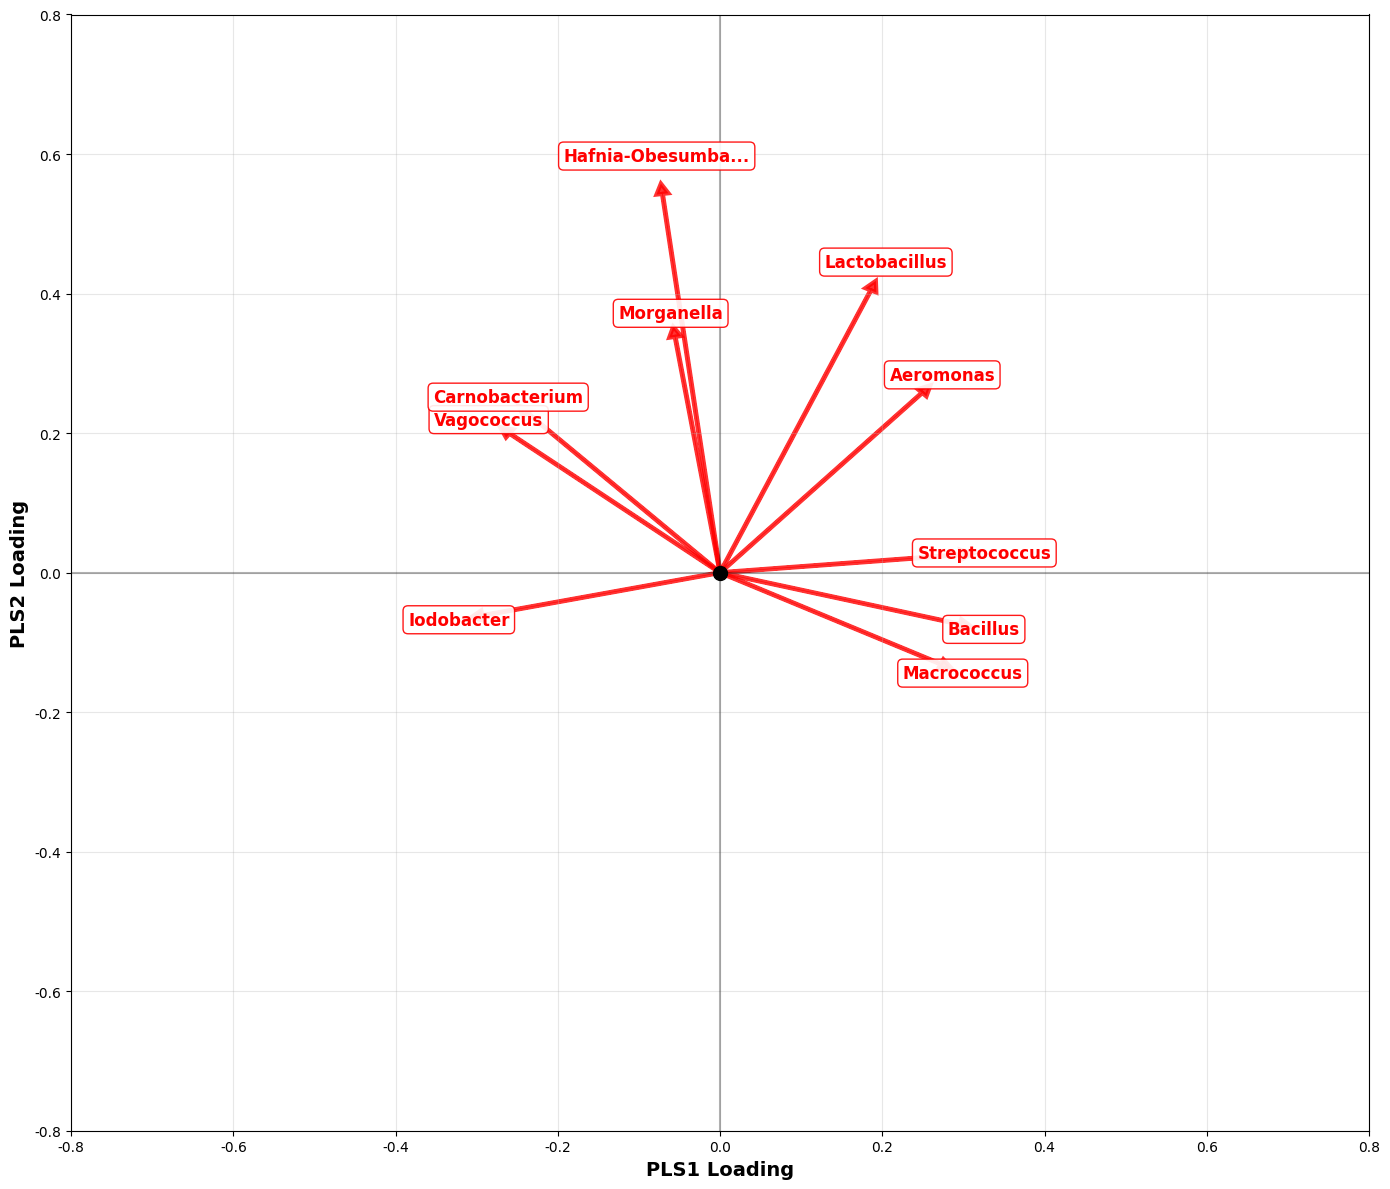

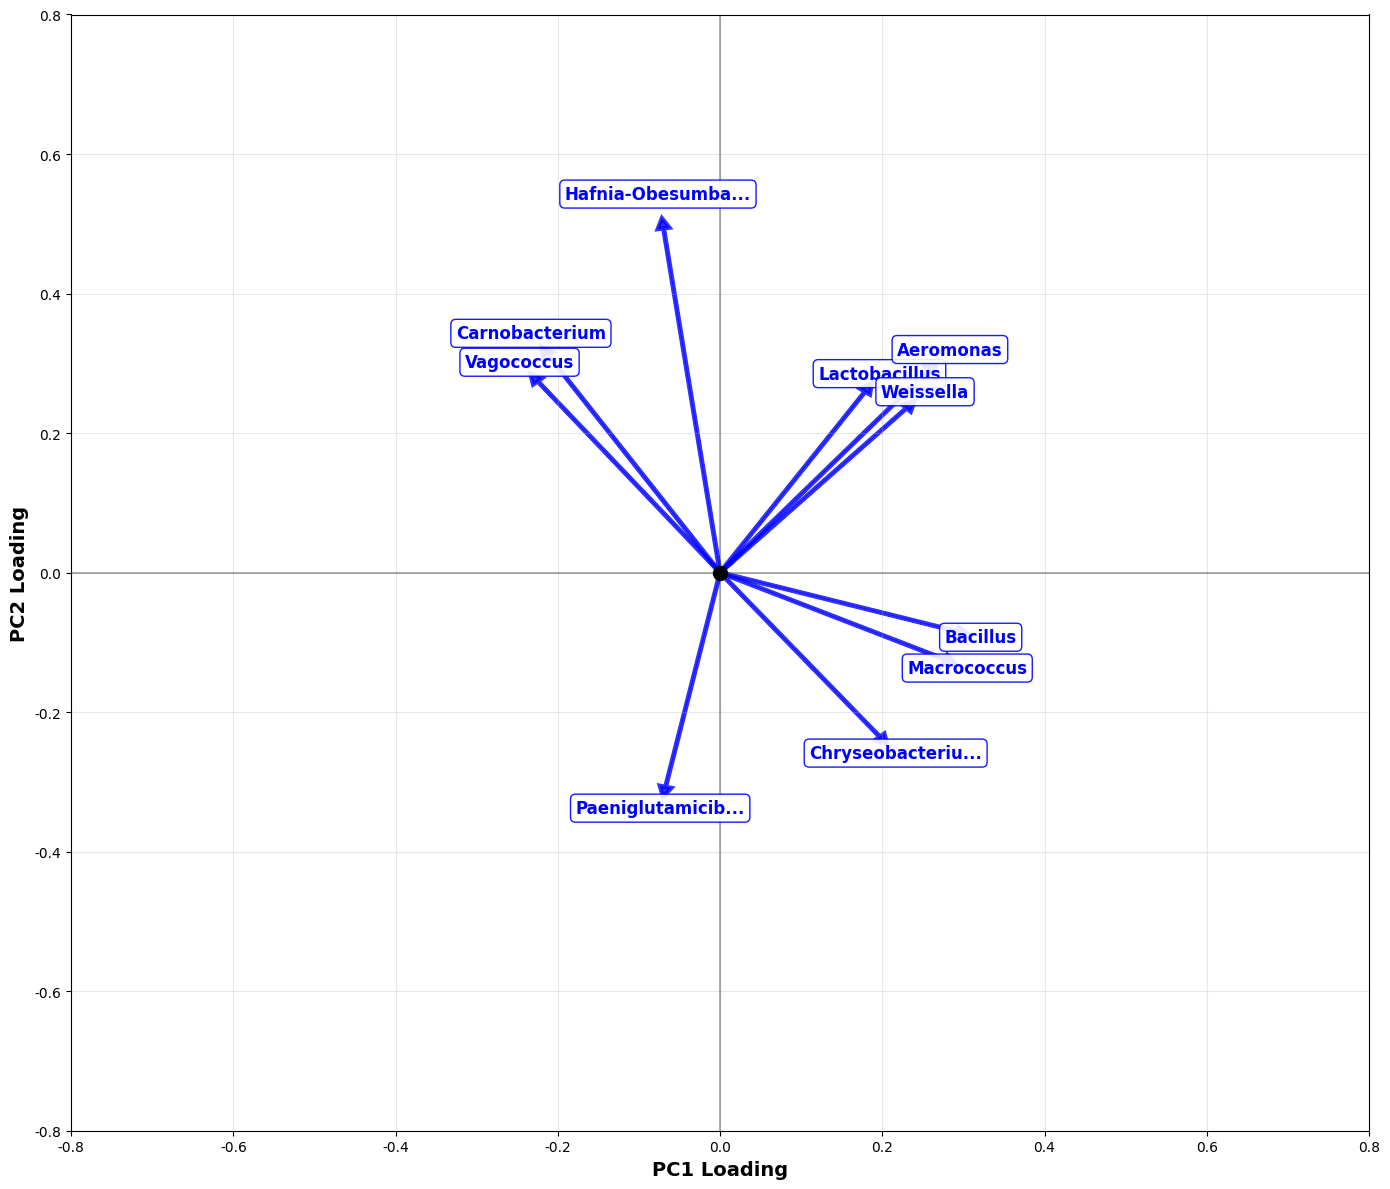

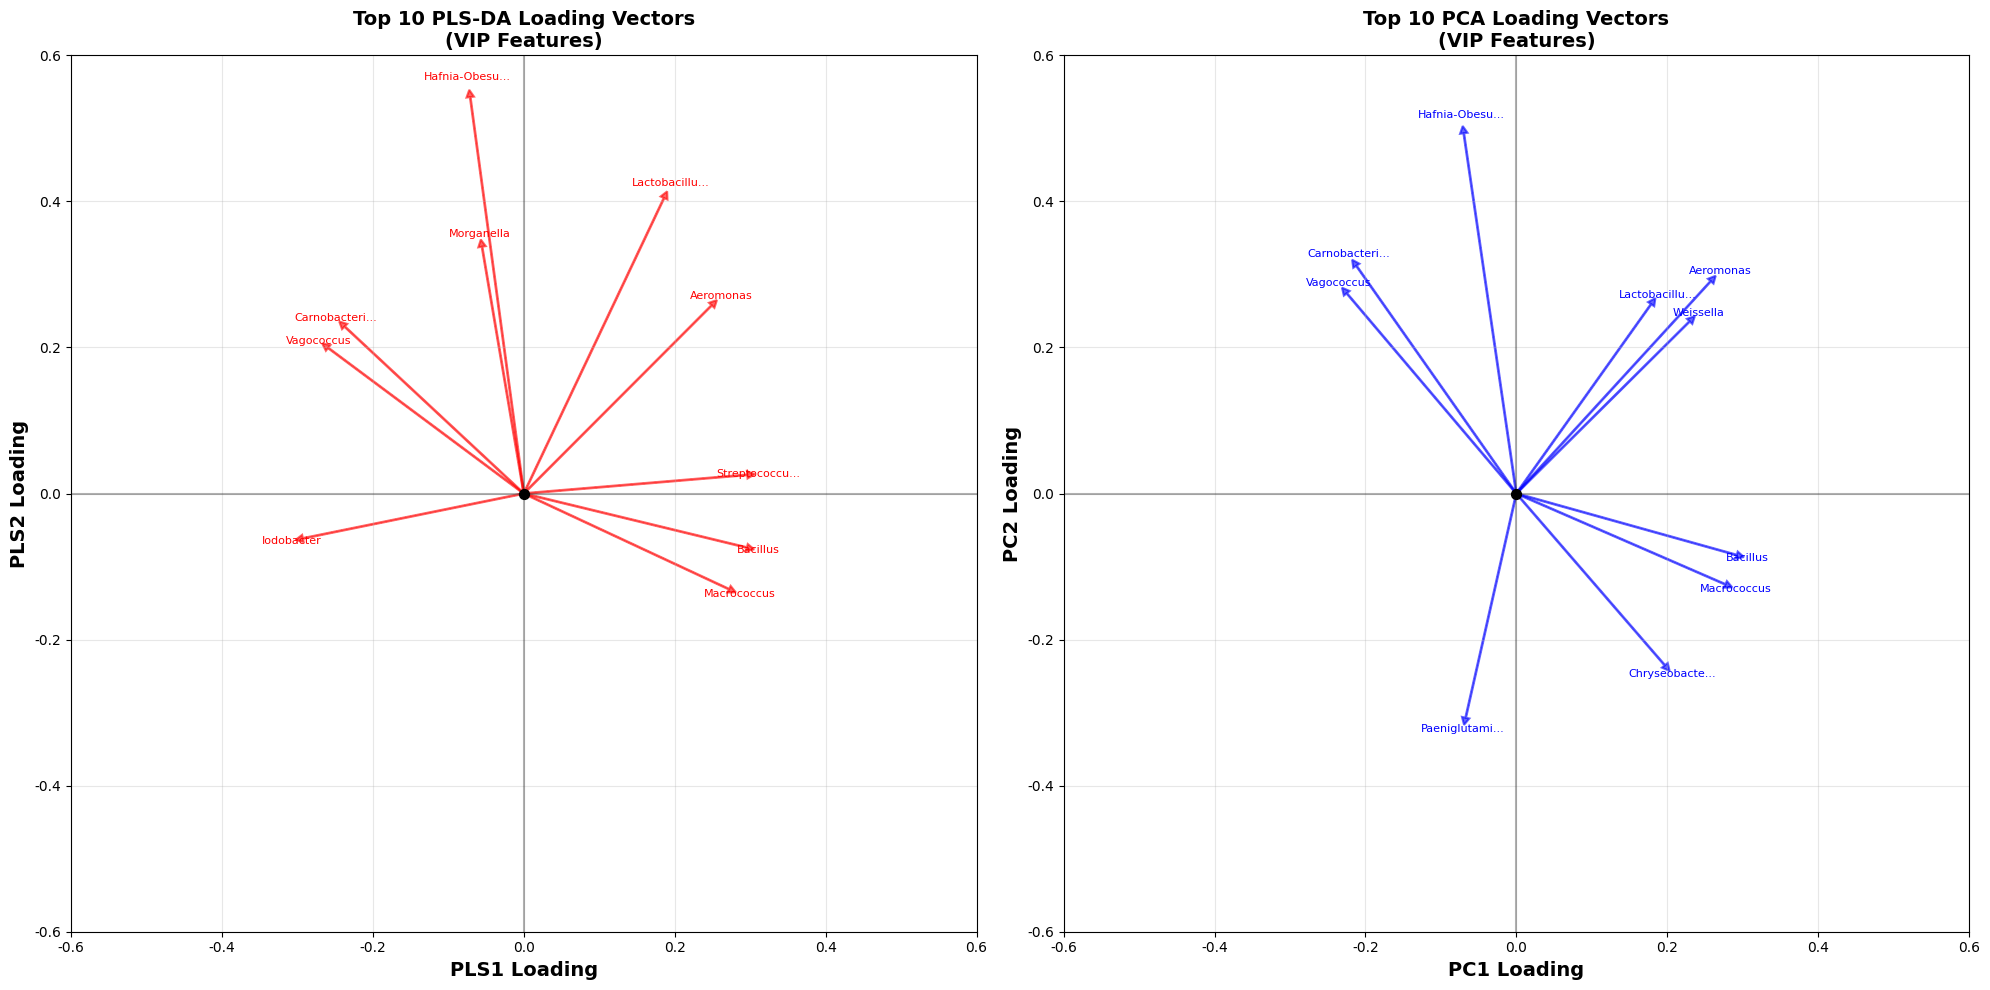

=== PLS-DA 벡터 정보 (상위 10개) ===
 1. Hafnia-Obesumbacterium    | PLS1: -0.071 | PLS2: +0.543 | Mag: 0.547
 2. Lactobacillus             | PLS1: +0.186 | PLS2: +0.405 | Mag: 0.445
 3. Aeromonas                 | PLS1: +0.249 | PLS2: +0.258 | Mag: 0.358
 4. Morganella                | PLS1: -0.055 | PLS2: +0.338 | Mag: 0.342
 5. Carnobacterium            | PLS1: -0.237 | PLS2: +0.229 | Mag: 0.330
 6. Vagococcus                | PLS1: -0.259 | PLS2: +0.199 | Mag: 0.327
 7. Bacillus                  | PLS1: +0.296 | PLS2: -0.074 | Mag: 0.305
 8. Macrococcus               | PLS1: +0.272 | PLS2: -0.131 | Mag: 0.302
 9. Iodobacter                | PLS1: -0.293 | PLS2: -0.061 | Mag: 0.299
10. Streptococcus             | PLS1: +0.296 | PLS2: +0.026 | Mag: 0.297

=== PCA 벡터 정보 (상위 10개) ===
 1. Hafnia-Obesumbacterium    | PC1: -0.070 | PC2: +0.493 | Mag: 0.498
 2. Aeromonas                 | PC1: +0.258 | PC2: +0.291 | Mag: 0.388
 3. Carnobacterium            | PC1: -0.212 | PC2: +0.312 | Mag: 0.377

In [12]:
# PCA와 PLS-DA 벡터만 확대 시각화 (VIP > 1.0 Features 상위 10개)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# Genus Level 데이터 사용 (VIP > 1.0 기준)
level_name = 'Genus'
level_data = get_level_data(level_name)
vip_features = vip_over1_dict[level_name]['Feature'].tolist()

if not vip_features:
    print(f"{level_name}: VIP > 1.0 feature 없음, 스킵")
else:
    X_vip = level_data['features'][vip_features]
    tpc = level_data['tpc']
    y = tpc_labeling(tpc)

    # One-hot encoding for PLS-DA
    y_onehot = np.zeros((len(y), 3))
    for i in range(len(y)):
        y_onehot[i, y[i]] = 1

    # PCA 수행
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_vip)
    loadings_pca = pca.components_.T

    # PLS-DA 수행  
    plsda = PLSRegression(n_components=2, scale=False)
    X_plsda = plsda.fit_transform(X_vip, y_onehot)[0]
    loadings_plsda = plsda.x_weights_

    # Loading magnitude 계산
    loading_magnitudes_pls = np.sqrt(loadings_plsda[:, 0]**2 + loadings_plsda[:, 1]**2)
    loading_magnitudes_pca = np.sqrt(loadings_pca[:, 0]**2 + loadings_pca[:, 1]**2)
    
    # 상위 10개 인덱스 추출
    top10_idx_pls = np.argsort(loading_magnitudes_pls)[-10:]
    top10_idx_pca = np.argsort(loading_magnitudes_pca)[-10:]

    # 1. PLS-DA 벡터만 확대 시각화 (상위 10개 VIP features)
    plt.figure(figsize=(14, 12))

    for i in top10_idx_pls:
        feat = vip_features[i]
        feat_name = feat.replace('g__', '')
        if len(feat_name) > 15:
            feat_name = feat_name[:15] + '...'
        
        # 벡터 그리기 (빨간색)
        plt.arrow(0, 0, loadings_plsda[i, 0], loadings_plsda[i, 1],
                 head_width=0.015, head_length=0.015, fc='red', ec='red', 
                 linewidth=3, alpha=0.8)
        
        # 텍스트 라벨
        plt.text(loadings_plsda[i, 0]*1.1, loadings_plsda[i, 1]*1.1, feat_name, 
                 fontsize=12, color='red', ha='center', va='center', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='red', alpha=0.9))

    plt.xlim(-0.8, 0.8)
    plt.ylim(-0.8, 0.8)
    plt.xlabel('PLS1 Loading', fontsize=14, fontweight='bold')
    plt.ylabel('PLS2 Loading', fontsize=14, fontweight='bold')

    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    plt.scatter([0], [0], s=100, color='black', marker='o', zorder=5)
    plt.tight_layout()
    plt.show()

    # 2. PCA 벡터만 확대 시각화 (상위 10개 VIP features)
    plt.figure(figsize=(14, 12))

    for i in top10_idx_pca:
        feat = vip_features[i]
        feat_name = feat.replace('g__', '')
        if len(feat_name) > 15:
            feat_name = feat_name[:15] + '...'
        
        # 벡터 그리기 (파란색)
        plt.arrow(0, 0, loadings_pca[i, 0], loadings_pca[i, 1],
                 head_width=0.015, head_length=0.015, fc='blue', ec='blue', 
                 linewidth=3, alpha=0.8)
        
        # 텍스트 라벨
        plt.text(loadings_pca[i, 0]*1.1, loadings_pca[i, 1]*1.1, feat_name, 
                 fontsize=12, color='blue', ha='center', va='center', fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='blue', alpha=0.9))

    plt.xlim(-0.8, 0.8)
    plt.ylim(-0.8, 0.8)
    plt.xlabel('PC1 Loading', fontsize=14, fontweight='bold')
    plt.ylabel('PC2 Loading', fontsize=14, fontweight='bold')

    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    plt.scatter([0], [0], s=100, color='black', marker='o', zorder=5)
    plt.tight_layout()
    plt.show()

    # 3. 상위 10개 벡터 비교 시각화
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

    # 상위 10개 PLS-DA 벡터
    for i in top10_idx_pls:
        feat = vip_features[i]
        feat_name = feat.replace('g__', '')
        if len(feat_name) > 12:
            feat_name = feat_name[:12] + '...'
        
        ax1.arrow(0, 0, loadings_plsda[i, 0], loadings_plsda[i, 1],
                  head_width=0.01, head_length=0.01, fc='red', ec='red', 
                  alpha=0.6, linewidth=1.5)
        ax1.text(loadings_plsda[i, 0]*1.05, loadings_plsda[i, 1]*1.05, feat_name, 
                 fontsize=8, color='red', ha='center', va='center')

    ax1.set_xlim(-0.6, 0.6)
    ax1.set_ylim(-0.6, 0.6)
    ax1.set_xlabel('PLS1 Loading', fontsize=14, fontweight='bold')
    ax1.set_ylabel('PLS2 Loading', fontsize=14, fontweight='bold')
    ax1.set_title('Top 10 PLS-DA Loading Vectors\n(VIP Features)', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax1.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    ax1.scatter([0], [0], s=50, color='black', marker='o', zorder=5)

    # 상위 10개 PCA 벡터
    for i in top10_idx_pca:
        feat = vip_features[i]
        feat_name = feat.replace('g__', '')
        if len(feat_name) > 12:
            feat_name = feat_name[:12] + '...'
        
        ax2.arrow(0, 0, loadings_pca[i, 0], loadings_pca[i, 1],
                  head_width=0.01, head_length=0.01, fc='blue', ec='blue', 
                  alpha=0.6, linewidth=1.5)
        ax2.text(loadings_pca[i, 0]*1.05, loadings_pca[i, 1]*1.05, feat_name, 
                 fontsize=8, color='blue', ha='center', va='center')

    ax2.set_xlim(-0.6, 0.6)
    ax2.set_ylim(-0.6, 0.6)
    ax2.set_xlabel('PC1 Loading', fontsize=14, fontweight='bold')
    ax2.set_ylabel('PC2 Loading', fontsize=14, fontweight='bold')
    ax2.set_title('Top 10 PCA Loading Vectors\n(VIP Features)', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0, color='k', linestyle='-', alpha=0.3)
    ax2.axvline(x=0, color='k', linestyle='-', alpha=0.3)
    ax2.scatter([0], [0], s=50, color='black', marker='o', zorder=5)

    plt.tight_layout()
    plt.show()

    # 벡터 정보 출력 (상위 10개만)
    print("=== PLS-DA 벡터 정보 (상위 10개) ===")
    sorted_idx_pls = np.argsort(loading_magnitudes_pls)[::-1]
    for rank, i in enumerate(sorted_idx_pls[:10], 1):
        feat_name = vip_features[i].replace('g__', '')
        pls1_load = loadings_plsda[i, 0]
        pls2_load = loadings_plsda[i, 1]
        magnitude = loading_magnitudes_pls[i]
        print(f"{rank:2d}. {feat_name:<25} | PLS1: {pls1_load:+.3f} | PLS2: {pls2_load:+.3f} | Mag: {magnitude:.3f}")

    print("\n=== PCA 벡터 정보 (상위 10개) ===")
    sorted_idx_pca = np.argsort(loading_magnitudes_pca)[::-1]
    for rank, i in enumerate(sorted_idx_pca[:10], 1):
        feat_name = vip_features[i].replace('g__', '')
        pc1_load = loadings_pca[i, 0]
        pc2_load = loadings_pca[i, 1]
        magnitude = loading_magnitudes_pca[i]
        print(f"{rank:2d}. {feat_name:<25} | PC1: {pc1_load:+.3f} | PC2: {pc2_load:+.3f} | Mag: {magnitude:.3f}")

전체 VIP > 1.0 Feature 수: 24
Hafnia 제거 후 Feature 수: 23
제거된 Feature 수: 1


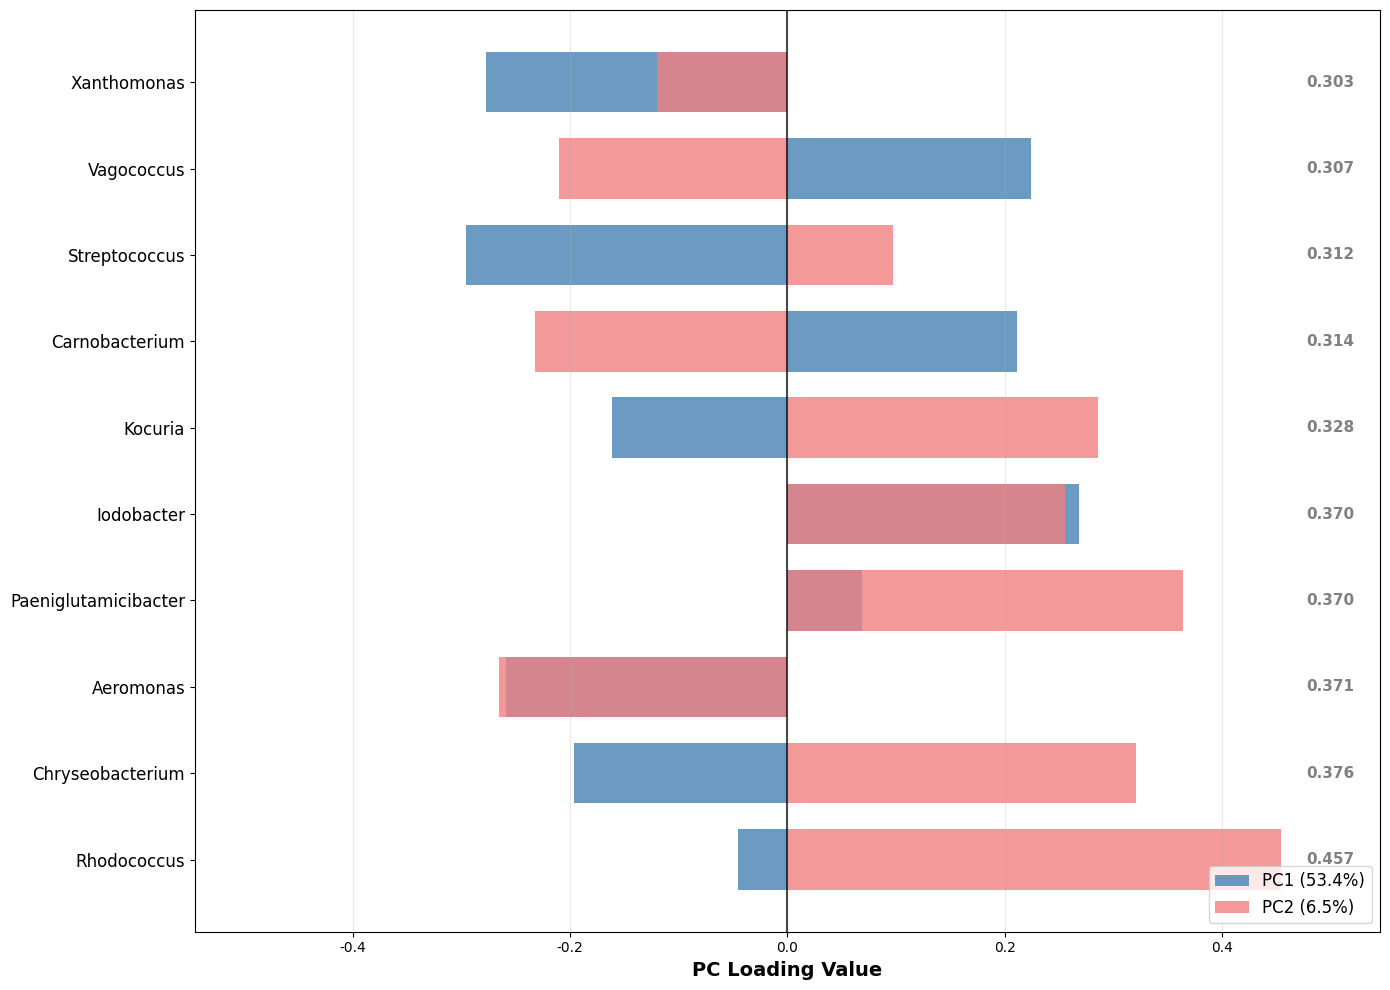

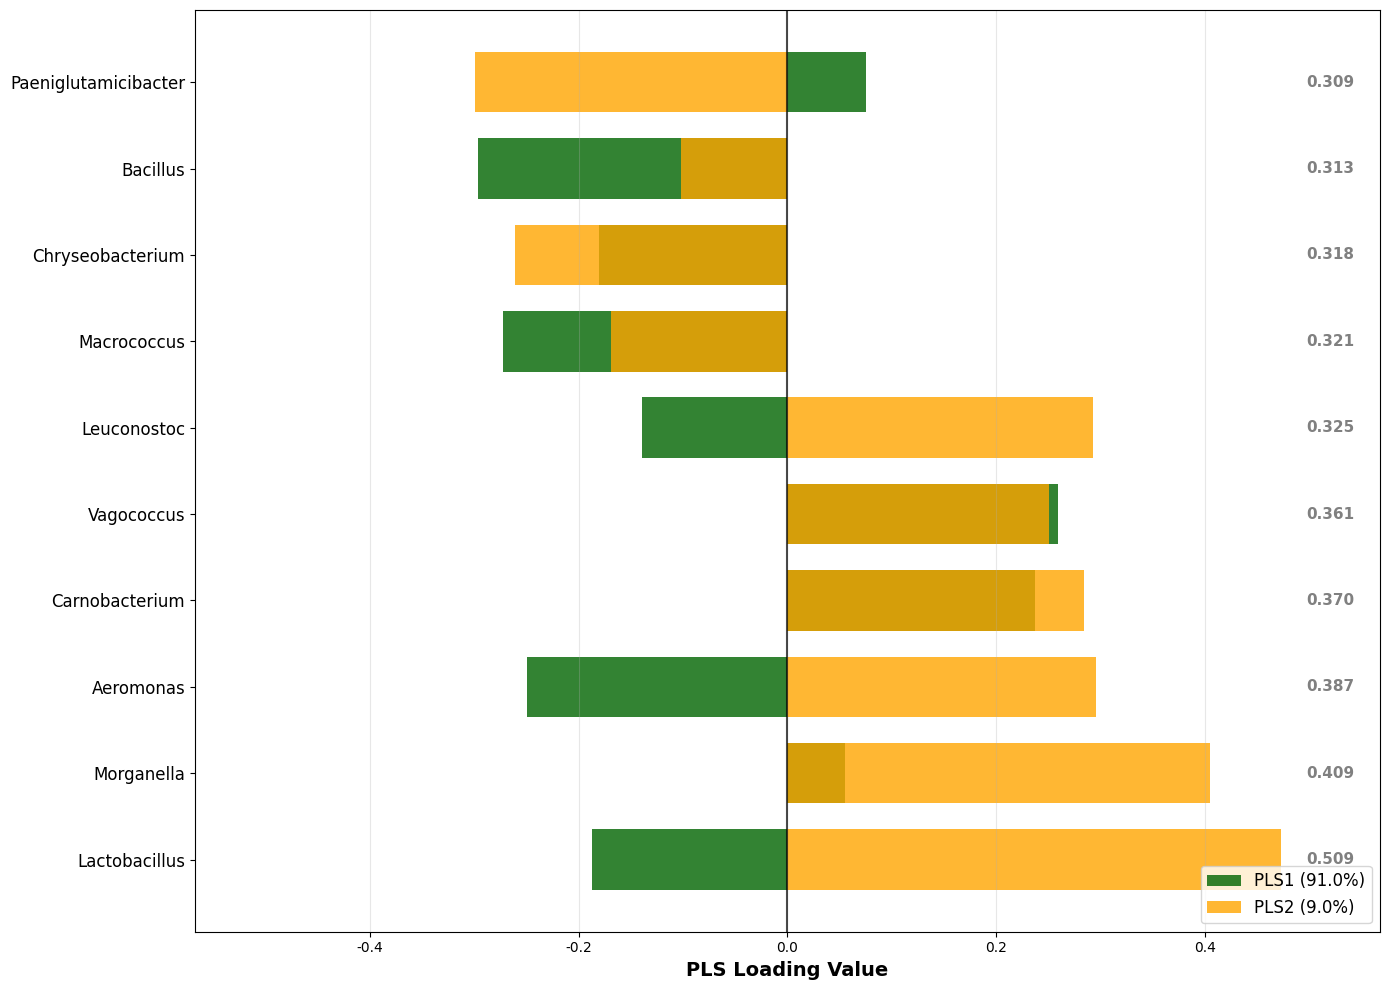

In [13]:
# VIP > 1.0 Features Ranking Figure (Hafnia 제외, Top 10)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression

# Genus Level 데이터 사용 (VIP > 1.0 기준)
level_name = 'Genus'
level_data = get_level_data(level_name)
vip_features = vip_over1_dict[level_name]['Feature'].tolist()

# Hafnia 포함된 feature 제거
vip_features_filtered = [feat for feat in vip_features if 'Hafnia' not in feat]
print(f"전체 VIP > 1.0 Feature 수: {len(vip_features)}")
print(f"Hafnia 제거 후 Feature 수: {len(vip_features_filtered)}")
print(f"제거된 Feature 수: {len(vip_features) - len(vip_features_filtered)}")

if not vip_features_filtered:
    print(f"{level_name}: Hafnia 제거 후 VIP > 1.0 feature 없음, 스킵")
else:
    X_vip = level_data['features'][vip_features_filtered]
    tpc = level_data['tpc']
    y = tpc_labeling(tpc)

    # One-hot encoding for PLS-DA
    y_onehot = np.zeros((len(y), 3))
    for i in range(len(y)):
        y_onehot[i, y[i]] = 1

    # PCA 수행
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_vip)
    loadings_pca = pca.components_.T

    # PLS-DA 수행  
    plsda = PLSRegression(n_components=2, scale=False)
    X_plsda = plsda.fit_transform(X_vip, y_onehot)[0]
    loadings_plsda = plsda.x_weights_

    # Loading magnitude 계산
    loading_magnitudes_pls = np.sqrt(loadings_plsda[:, 0]**2 + loadings_plsda[:, 1]**2)
    loading_magnitudes_pca = np.sqrt(loadings_pca[:, 0]**2 + loadings_pca[:, 1]**2)
    
    # 설명 분산 비율 계산
    exp_var_pca = pca.explained_variance_ratio_ * 100
    exp_var_pls = np.var(X_plsda, axis=0) / np.sum(np.var(X_plsda, axis=0)) * 100
    
    # 전체 feature를 magnitude 기준 내림차순 정렬
    sorted_idx_pca = np.argsort(loading_magnitudes_pca)[::-1]  
    sorted_idx_pls = np.argsort(loading_magnitudes_pls)[::-1]  
    
    # Feature 이름에서 g__ 제거
    feature_names_clean = [f.replace('g__', '') for f in vip_features_filtered]
    
    # Top 10만 선택
    top10_idx_pca = sorted_idx_pca[:10]
    top10_idx_pls = sorted_idx_pls[:10]
    
    # 1. PCA Feature Ranking Plot (Top 10)
    sorted_features_pca = [feature_names_clean[i] for i in top10_idx_pca]
    sorted_pc1 = loadings_pca[top10_idx_pca, 0]
    sorted_pc2 = loadings_pca[top10_idx_pca, 1]
    sorted_mag_pca = loading_magnitudes_pca[top10_idx_pca]
    
    y_pos = np.arange(len(sorted_features_pca))
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # PC1 (음수로 표시), PC2 (양수로 표시) - 모든 바 동일한 색상
    bars1 = ax.barh(y_pos, -sorted_pc1, height=0.7,
                     label=f"PC1 ({exp_var_pca[0]:.1f}%)",
                     alpha=0.8, color='steelblue')
    bars2 = ax.barh(y_pos, sorted_pc2, height=0.7,
                     label=f"PC2 ({exp_var_pca[1]:.1f}%)",
                     alpha=0.8, color='lightcoral')
    
    # Magnitude 값 표시
    for i, mag in enumerate(sorted_mag_pca):
        ax.text(max(np.abs(sorted_pc2))*1.05, i, f'{mag:.3f}', 
                ha='left', va='center', fontsize=11, fontweight='bold', color='gray')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_features_pca, fontsize=12)
    ax.set_xlabel('PC Loading Value', fontsize=14, fontweight='bold')

    
    ax.legend(fontsize=12, loc='lower right')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
    ax.grid(True, alpha=0.3, axis='x')
    
    max_val_pca = max(np.max(np.abs(sorted_pc1)), np.max(np.abs(sorted_pc2)))
    ax.set_xlim(-max_val_pca*1.2, max_val_pca*1.2)
    
    plt.tight_layout()
    plt.show()
    
    # 2. PLS-DA Feature Ranking Plot (Top 10)
    sorted_features_pls = [feature_names_clean[i] for i in top10_idx_pls]
    sorted_pls1 = loadings_plsda[top10_idx_pls, 0]
    sorted_pls2 = loadings_plsda[top10_idx_pls, 1]
    sorted_mag_pls = loading_magnitudes_pls[top10_idx_pls]
    
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # PLS1 (음수로 표시), PLS2 (양수로 표시) - 모든 바 동일한 색상
    bars3 = ax.barh(y_pos, -sorted_pls1, height=0.7,
                     label=f"PLS1 ({exp_var_pls[0]:.1f}%)",
                     alpha=0.8, color='darkgreen')
    bars4 = ax.barh(y_pos, sorted_pls2, height=0.7,
                     label=f"PLS2 ({exp_var_pls[1]:.1f}%)",
                     alpha=0.8, color='orange')
    
    # Magnitude 값 표시
    for i, mag in enumerate(sorted_mag_pls):
        ax.text(max(np.abs(sorted_pls2))*1.05, i, f'{mag:.3f}', 
                ha='left', va='center', fontsize=11, fontweight='bold', color='gray')
    
    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_features_pls, fontsize=12)
    ax.set_xlabel('PLS Loading Value', fontsize=14, fontweight='bold')

    
    ax.legend(fontsize=12, loc='lower right')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
    ax.grid(True, alpha=0.3, axis='x')
    
    max_val_pls = max(np.max(np.abs(sorted_pls1)), np.max(np.abs(sorted_pls2)))
    ax.set_xlim(-max_val_pls*1.2, max_val_pls*1.2)
    
    plt.tight_layout()
    plt.show()
    

## Paper용 figure 2 

/var/folders/f5/vpc6wvfd0d9g1tdw0h3gqqcc0000gn/T/ipykernel_7975/2144423807.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(x):.3f}' for x in ax.get_xticks()])


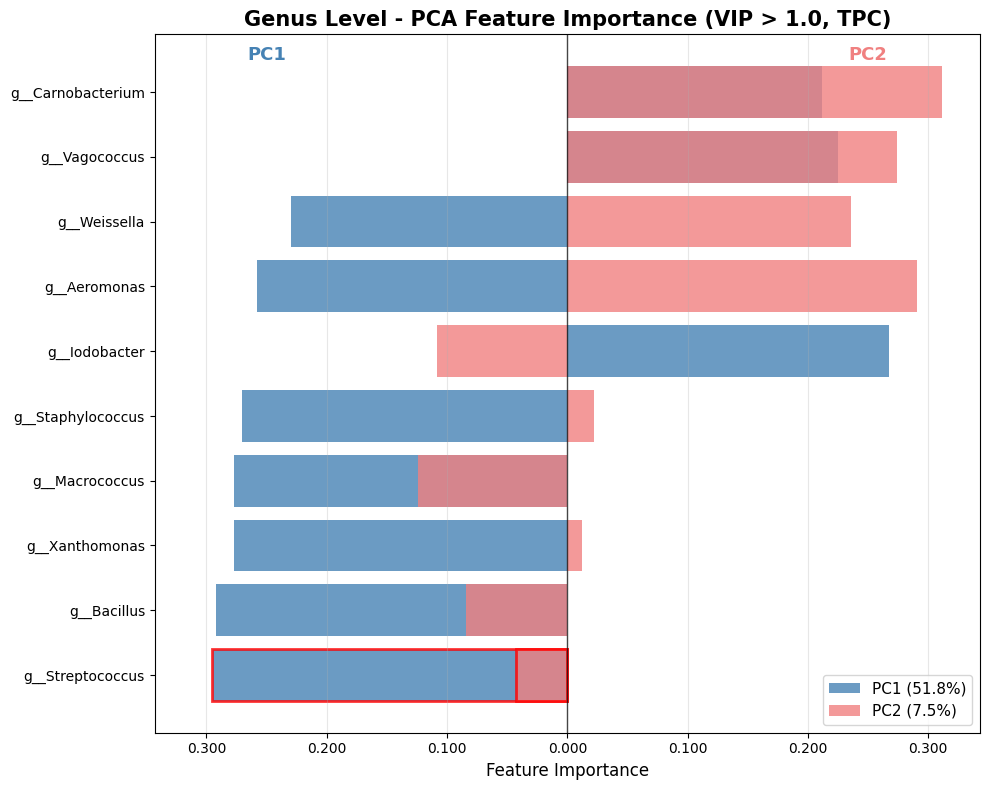

In [14]:
# Genus level PCA mirror bar chart (논문 스타일, 겹치지 않게)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

level_name = 'Genus'
level_data = get_level_data(level_name)
vip_features = vip_over1_dict[level_name]['Feature'].tolist()
if not vip_features:
    print(f"{level_name}: VIP > 1.0 feature 없음, 스킵")
else:
    X_vip = level_data['features'][vip_features]
    pca = PCA(n_components=2)
    pca.fit(X_vip)
    loadings = pca.components_.T
    exp_var = pca.explained_variance_ratio_ * 100

    pc1_loadings = loadings[:, 0]
    pc2_loadings = loadings[:, 1]
    feature_names = np.array(vip_features)
    top10_idx = np.argsort(np.abs(pc1_loadings))[-10:][::-1]
    top10_features = feature_names[top10_idx]
    top10_pc1 = pc1_loadings[top10_idx]
    top10_pc2 = pc2_loadings[top10_idx]

    y_pos = np.arange(len(top10_features))
    fig, ax = plt.subplots(figsize=(10, 8))
    # PC1: 음수 mirror, 파란색
    bars1 = ax.barh(y_pos, -top10_pc1, height=0.8,
                    label=f"PC1 ({exp_var[0]:.1f}%)",
                    alpha=0.8, color='steelblue')
    # PC2: 양수 mirror, 빨간색
    bars2 = ax.barh(y_pos, top10_pc2, height=0.8,
                    label=f"PC2 ({exp_var[1]:.1f}%)",
                    alpha=0.8, color='lightcoral')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(top10_features, fontsize=10)
    ax.set_xlabel('Feature Importance', fontsize=12)
    ax.set_title('Genus Level - PCA Feature Importance (VIP > 1.0, TPC)', fontsize=15, fontweight='bold')
    ax.legend(fontsize=11, loc='lower right')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1, alpha=0.7)
    ax.grid(True, alpha=0.3, axis='x')
    max_val = max(np.max(np.abs(top10_pc1)), np.max(np.abs(top10_pc2)))
    ax.set_xlim(-max_val*1.1, max_val*1.1)

    bars1[0].set_edgecolor('red')
    bars1[0].set_linewidth(2)
    bars2[0].set_edgecolor('red')
    bars2[0].set_linewidth(2)

    ax.set_xticklabels([f'{abs(x):.3f}' for x in ax.get_xticks()])
    ax.text(-max_val*0.8, len(top10_features)*0.95, 'PC1',
            fontsize=13, fontweight='bold', ha='center', color='steelblue')
    ax.text(max_val*0.8, len(top10_features)*0.95, 'PC2',
            fontsize=13, fontweight='bold', ha='center', color='lightcoral')

    plt.tight_layout()
    plt.show()

print("="*80)

## Heat map (Corrleation)
- 일단 Genus level로


=== Phylum VIP>1.0 Feature + TPC/TBARS Correlation Heatmap (TPC 기준, 하삼각형) ===


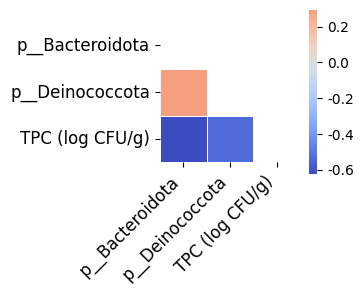

Phylum Level Heatmap 출력 완료


=== Class VIP>1.0 Feature + TPC/TBARS Correlation Heatmap (TPC 기준, 하삼각형) ===


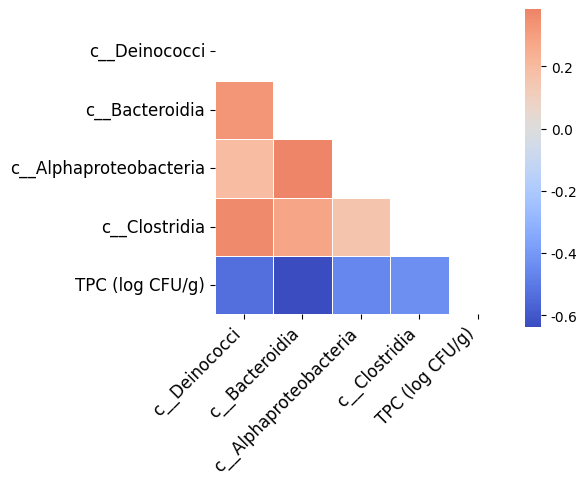

Class Level Heatmap 출력 완료


=== Order VIP>1.0 Feature + TPC/TBARS Correlation Heatmap (TPC 기준, 하삼각형) ===


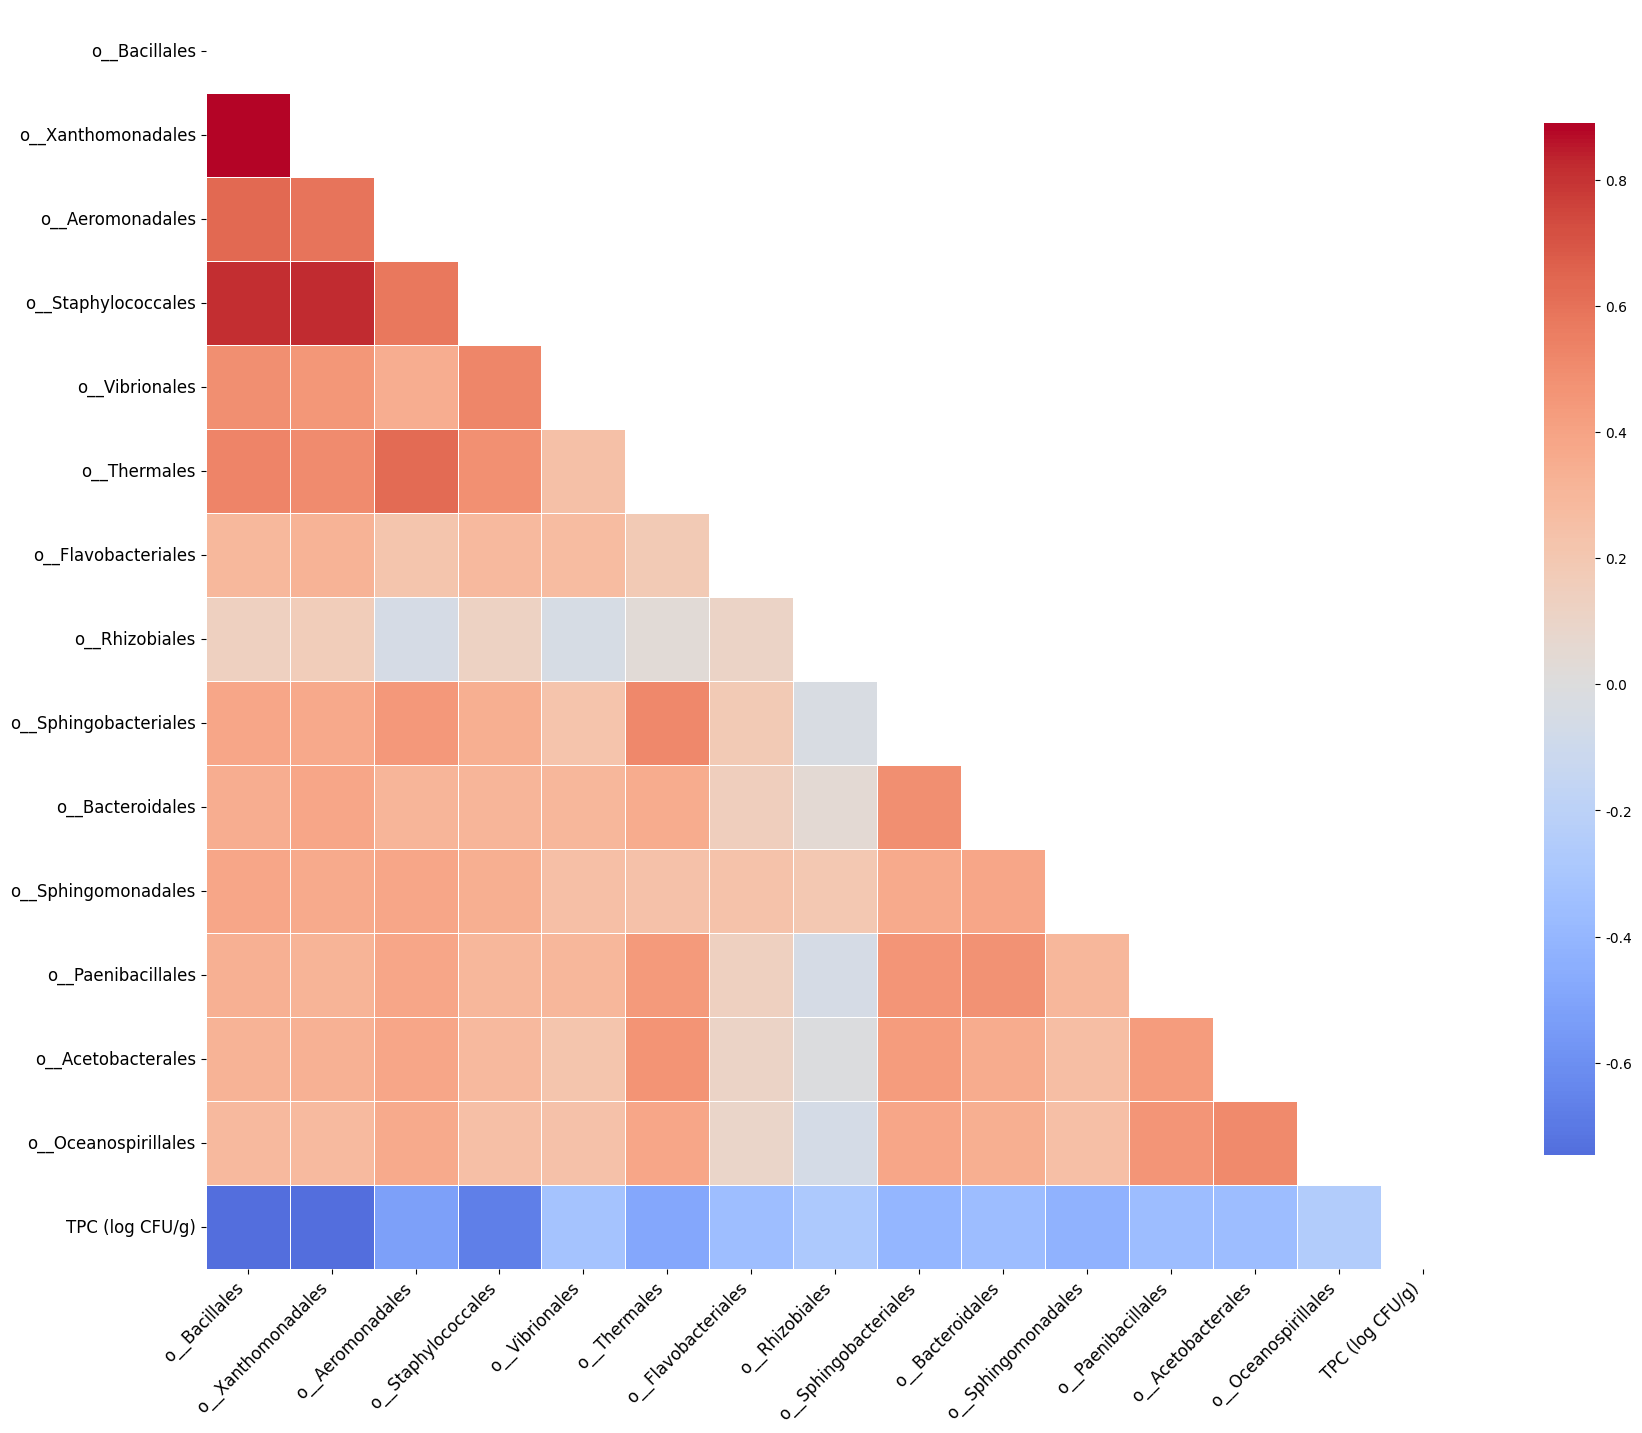

Order Level Heatmap 출력 완료


=== Family VIP>1.0 Feature + TPC/TBARS Correlation Heatmap (TPC 기준, 하삼각형) ===


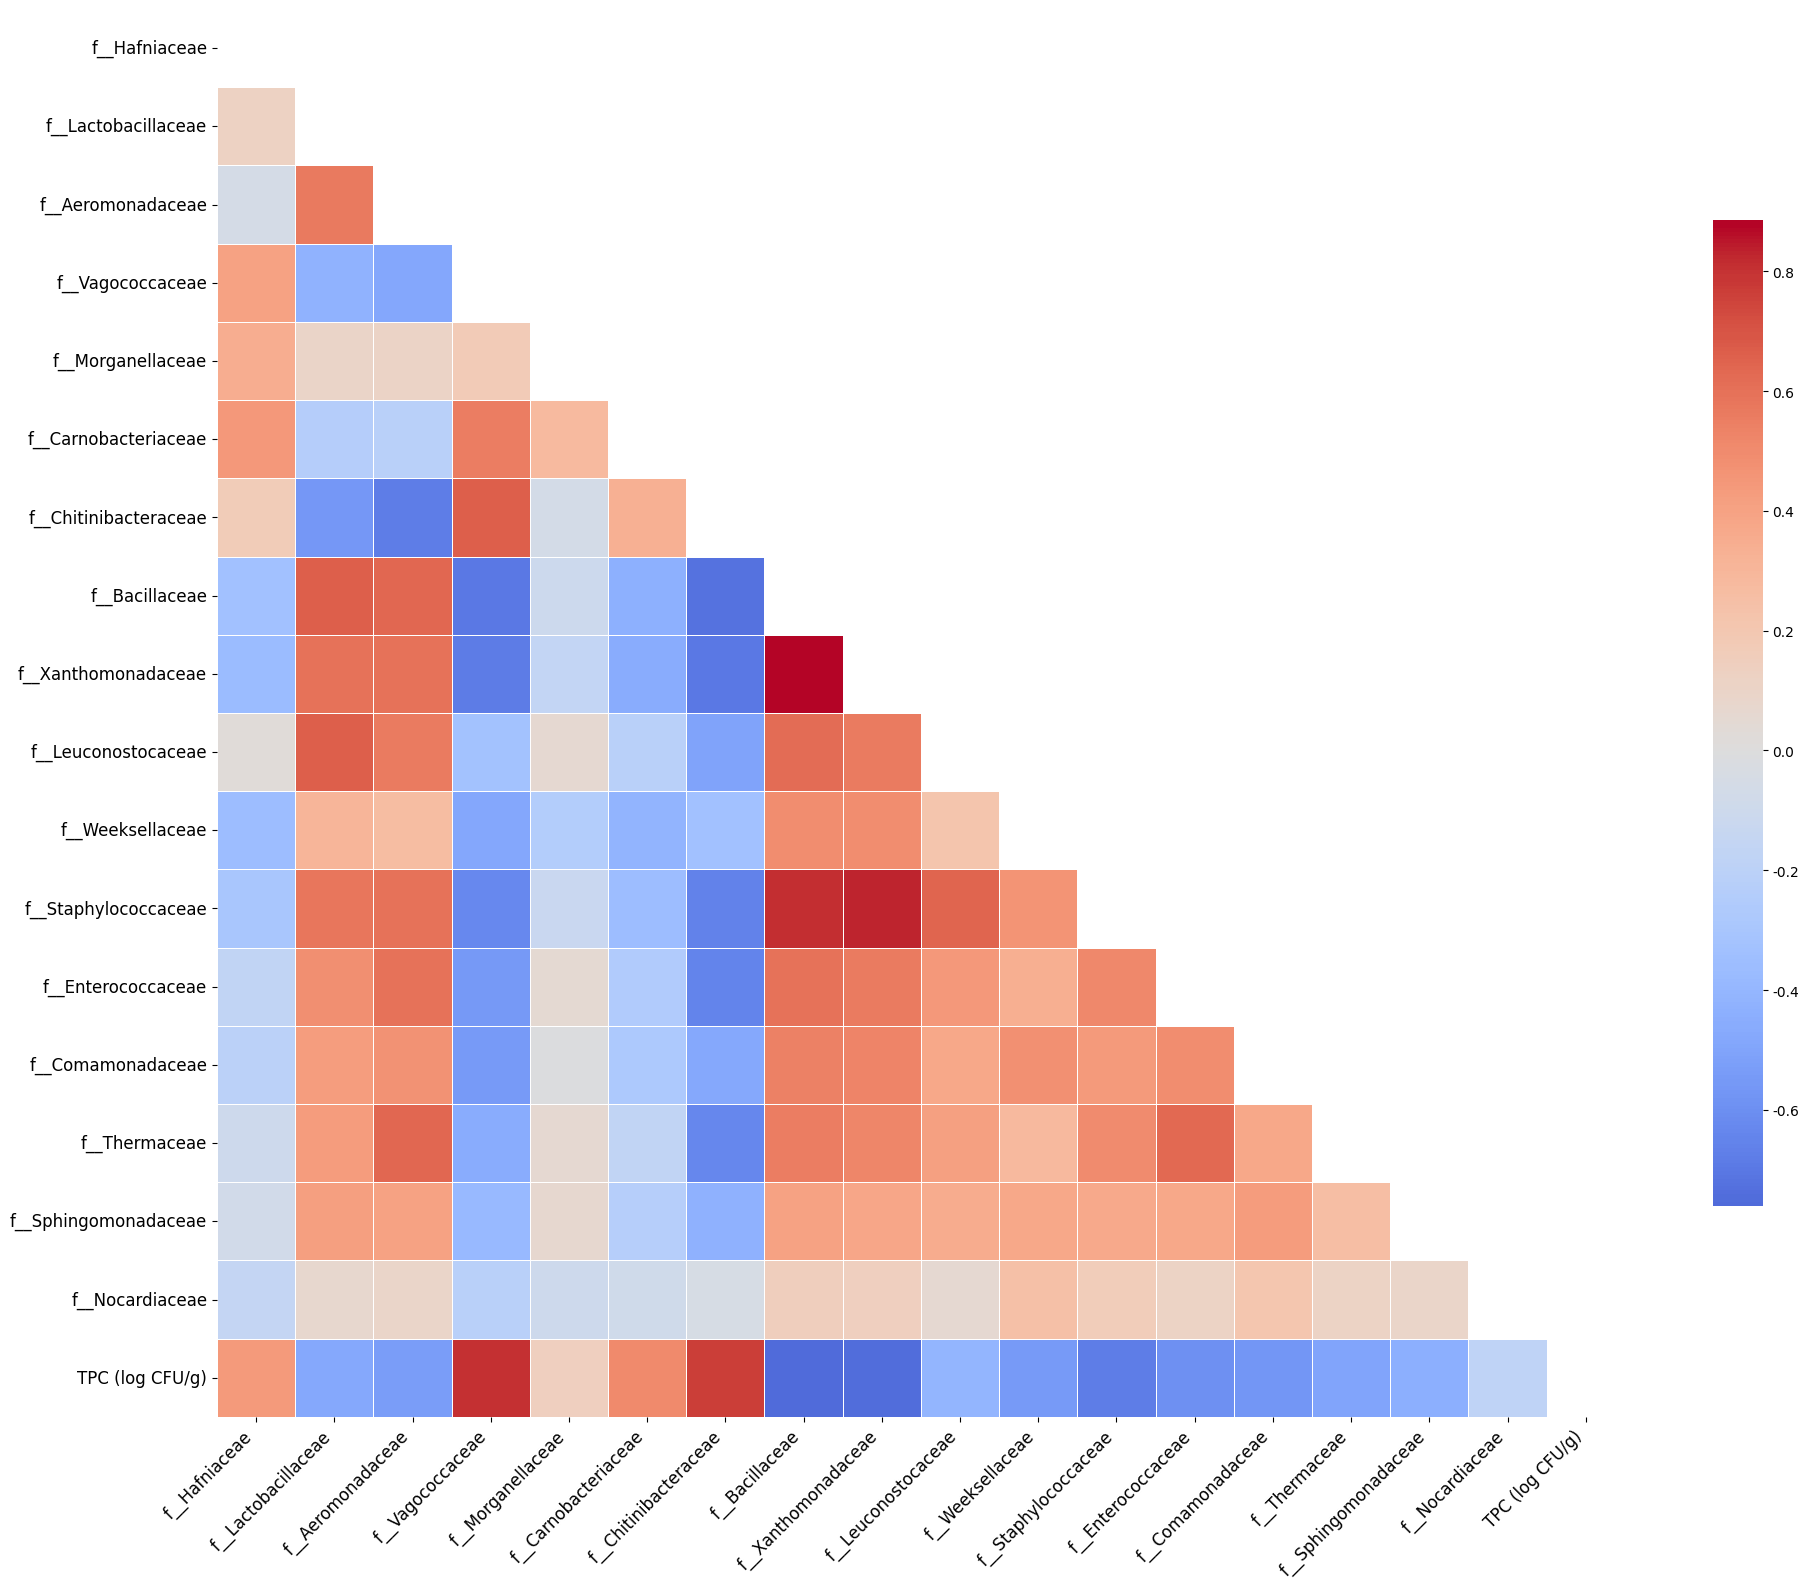

Family Level Heatmap 출력 완료


=== Genus VIP>1.0 Feature + TPC/TBARS Correlation Heatmap (TPC 기준, 하삼각형) ===


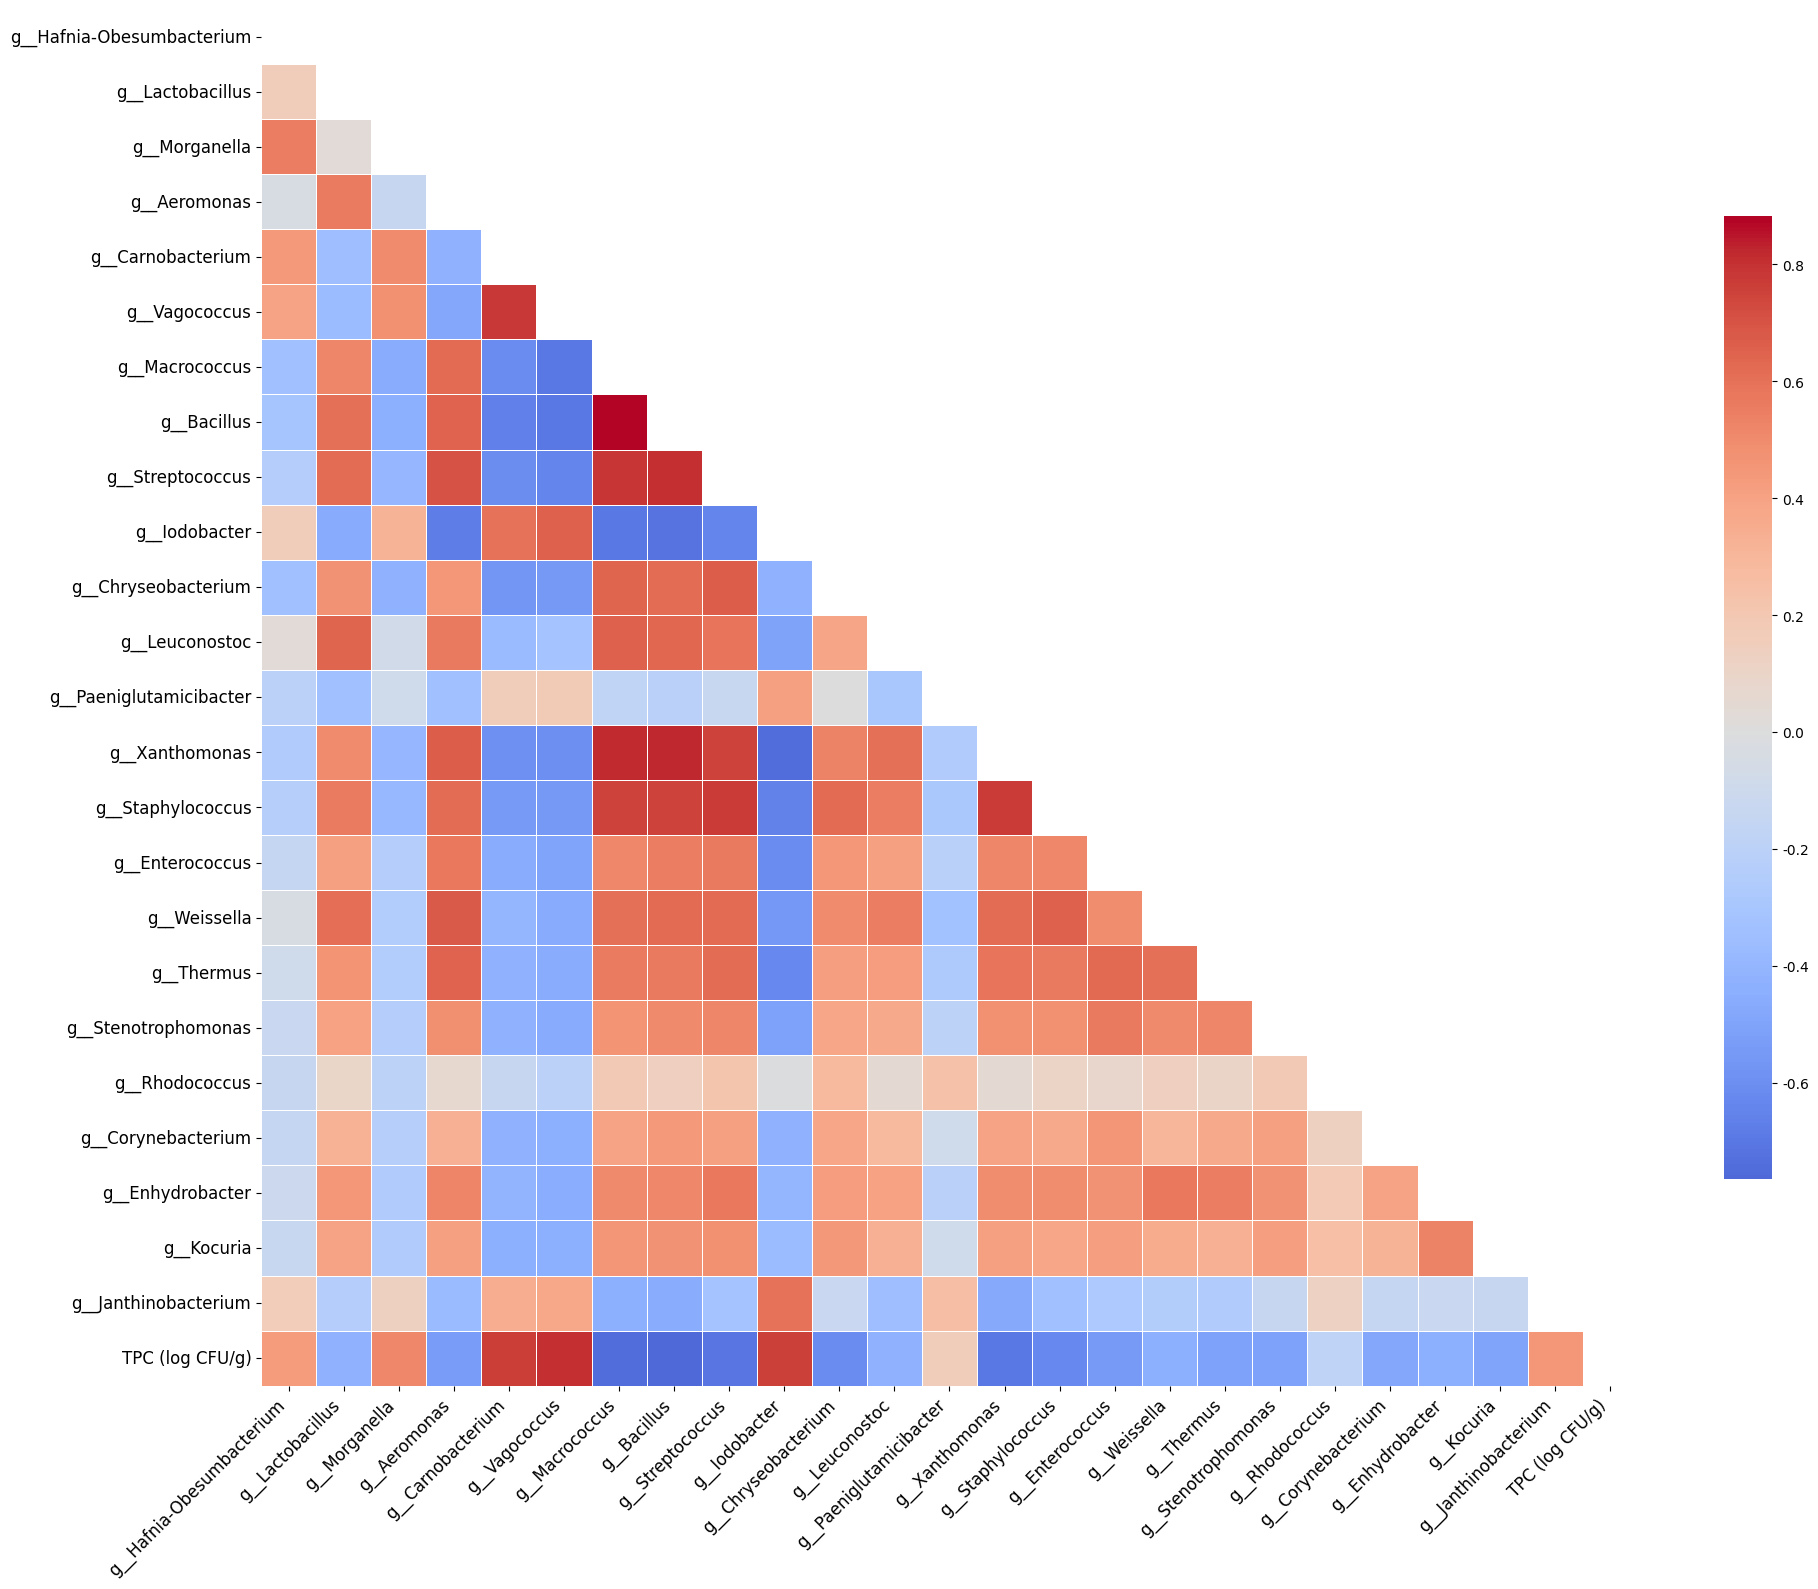

Genus Level Heatmap 출력 완료



In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

level_names = ['Phylum', 'Class', 'Order', 'Family', 'Genus']

for level_name in level_names:
    print(f"\n=== {level_name} VIP>1.0 Feature + TPC/TBARS Correlation Heatmap (TPC 기준, 하삼각형) ===")
    level_data = get_level_data(level_name)
    if level_data is None:
        print(f"{level_name}: 데이터 없음, 스킵")
        continue
    # VIP>1.0 feature 추출 (TPC 기준)
    if level_name not in vip_over1_dict:
        print(f"{level_name}: VIP Score 데이터 없음, 스킵")
        continue
    vip_features = vip_over1_dict[level_name]['Feature'].tolist()
    if not vip_features:
        print(f"{level_name}: VIP > 1.0 feature 없음, 스킵")
        continue
    X_vip = level_data['features'][vip_features]
    X_corr = X_vip.copy()
    X_corr['TPC (log CFU/g)'] = level_data['tpc']
    corr_matrix = X_corr.corr()
    
    # 상삼각형 마스크 생성 (대각선 위쪽 숨기기)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    plt.figure(figsize=(min(1.2*len(X_corr.columns), 20), min(1.2*len(X_corr.columns), 16)))
    sns.heatmap(
        corr_matrix, 
        mask=mask,  # 상삼각형 마스크 적용
        cmap='coolwarm', 
        center=0, 
        square=True, 
        linewidths=0.5, 
        cbar_kws={"shrink": 0.7},
        xticklabels=True, 
        yticklabels=True,
        annot=False  # 상관계수 수치 제거
    )
    
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(rotation=0, fontsize=12)
    plt.tight_layout()
    plt.show()
    
    print(f"{level_name} Level Heatmap 출력 완료\n")

## TBARS도 확인


=== Phylum Level: VIP Score > 1.0 (전처리된 TBARS 기준) ===
원본 유의 Feature 수: 12
괄호 제거 후 Feature 수: 11
제거된 Feature 수: 1
VIP > 1.0 Feature 개수: 3 / 11


,Feature,VIP_Score
0,p__Deinococcota,2.170090
1,p__Bacteroidota,1.979981
2,p__Campilobacterota,1.457115



=== Class Level: VIP Score > 1.0 (전처리된 TBARS 기준) ===
원본 유의 Feature 수: 13
괄호 제거 후 Feature 수: 12
제거된 Feature 수: 1
VIP > 1.0 Feature 개수: 5 / 12


,Feature,VIP_Score
0,c__Deinococci,1.922657
1,c__Alphaproteobacteria,1.500887
2,c__Campylobacteria,1.418327
3,c__Bacteroidia,1.333036
4,c__Clostridia,1.147188



=== Order Level: VIP Score > 1.0 (전처리된 TBARS 기준) ===
원본 유의 Feature 수: 48
괄호 제거 후 Feature 수: 45
제거된 Feature 수: 3
VIP > 1.0 Feature 개수: 13 / 45


,Feature,VIP_Score
0,o__Campylobacterales,2.297710
1,o__Clostridiales,2.178774
2,o__Bacillales,2.051702
3,o__Xanthomonadales,1.935219
4,o__Thermales,1.817413
5,o__Aeromonadales,1.673948
6,o__Staphylococcales,1.666320
7,o__Bifidobacteriales,1.469824
8,o__Bacteroidales,1.254572
9,o__Vibrionales,1.237864



=== Family Level: VIP Score > 1.0 (전처리된 TBARS 기준) ===
원본 유의 Feature 수: 85
괄호 제거 후 Feature 수: 79
제거된 Feature 수: 6
VIP > 1.0 Feature 개수: 27 / 79


,Feature,VIP_Score
0,f__Flavobacteriaceae,2.811795
1,f__Comamonadaceae,2.059412
2,f__Chitinibacteraceae,1.915150
3,f__Prevotellaceae,1.908131
4,f__Thermaceae,1.710392
5,f__Bacillaceae,1.693290
6,f__Arcobacteraceae,1.644813
7,f__Xanthomonadaceae,1.644236
8,f__Vagococcaceae,1.593572
9,f__Carnobacteriaceae,1.563760



=== Genus Level: VIP Score > 1.0 (전처리된 TBARS 기준) ===
원본 유의 Feature 수: 133
괄호 제거 후 Feature 수: 110
제거된 Feature 수: 23
VIP > 1.0 Feature 개수: 37 / 110


,Feature,VIP_Score
0,g__Flavobacterium,2.287738
1,g__Carnobacterium,2.191709
2,g__Vagococcus,2.139028
3,g__Rothia,2.085718
4,g__Streptococcus,2.050437
5,g__Iodobacter,1.962609
6,g__Bacillus,1.952036
7,g__Methylobacterium-Methylorubrum,1.930460
8,g__Weissella,1.907941
9,g__Macrococcus,1.894762


전처리된 TBARS 범위: 0.115 ~ 0.440

=== 모든 Level VIP > 1.0 Feature (전처리된 TBARS 기준, 괄호 Feature 제거) 추출 완료 ===


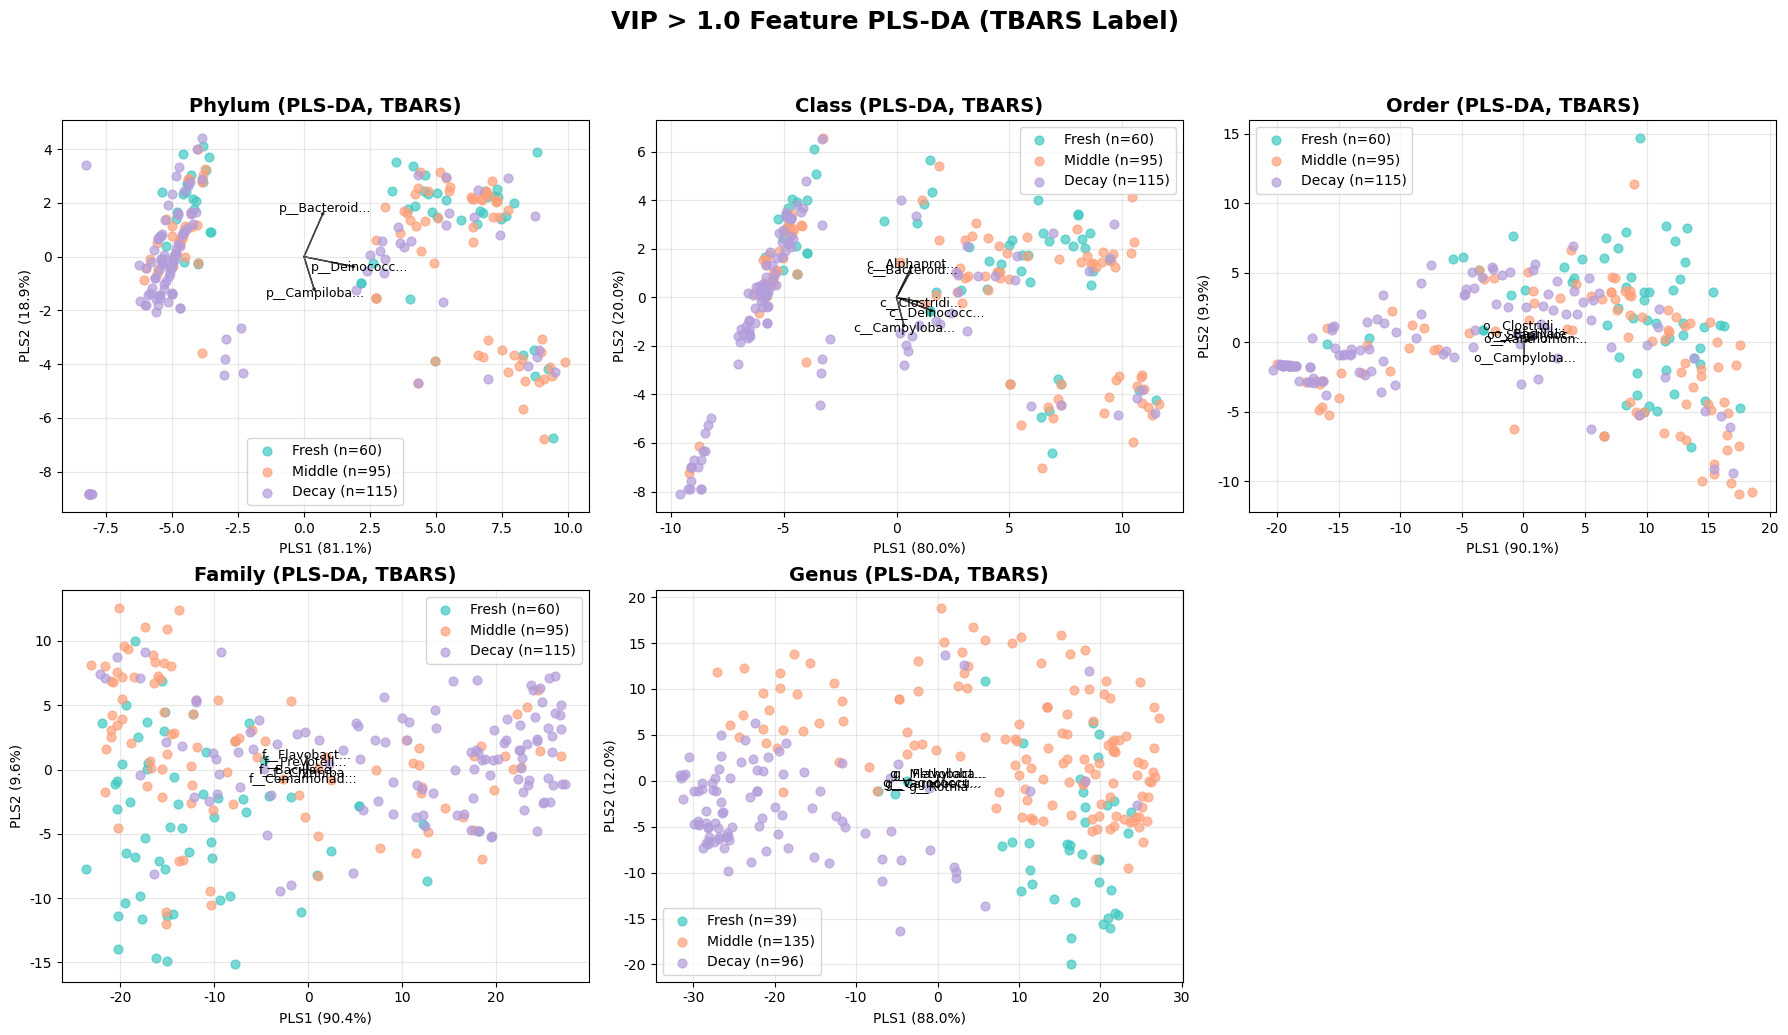

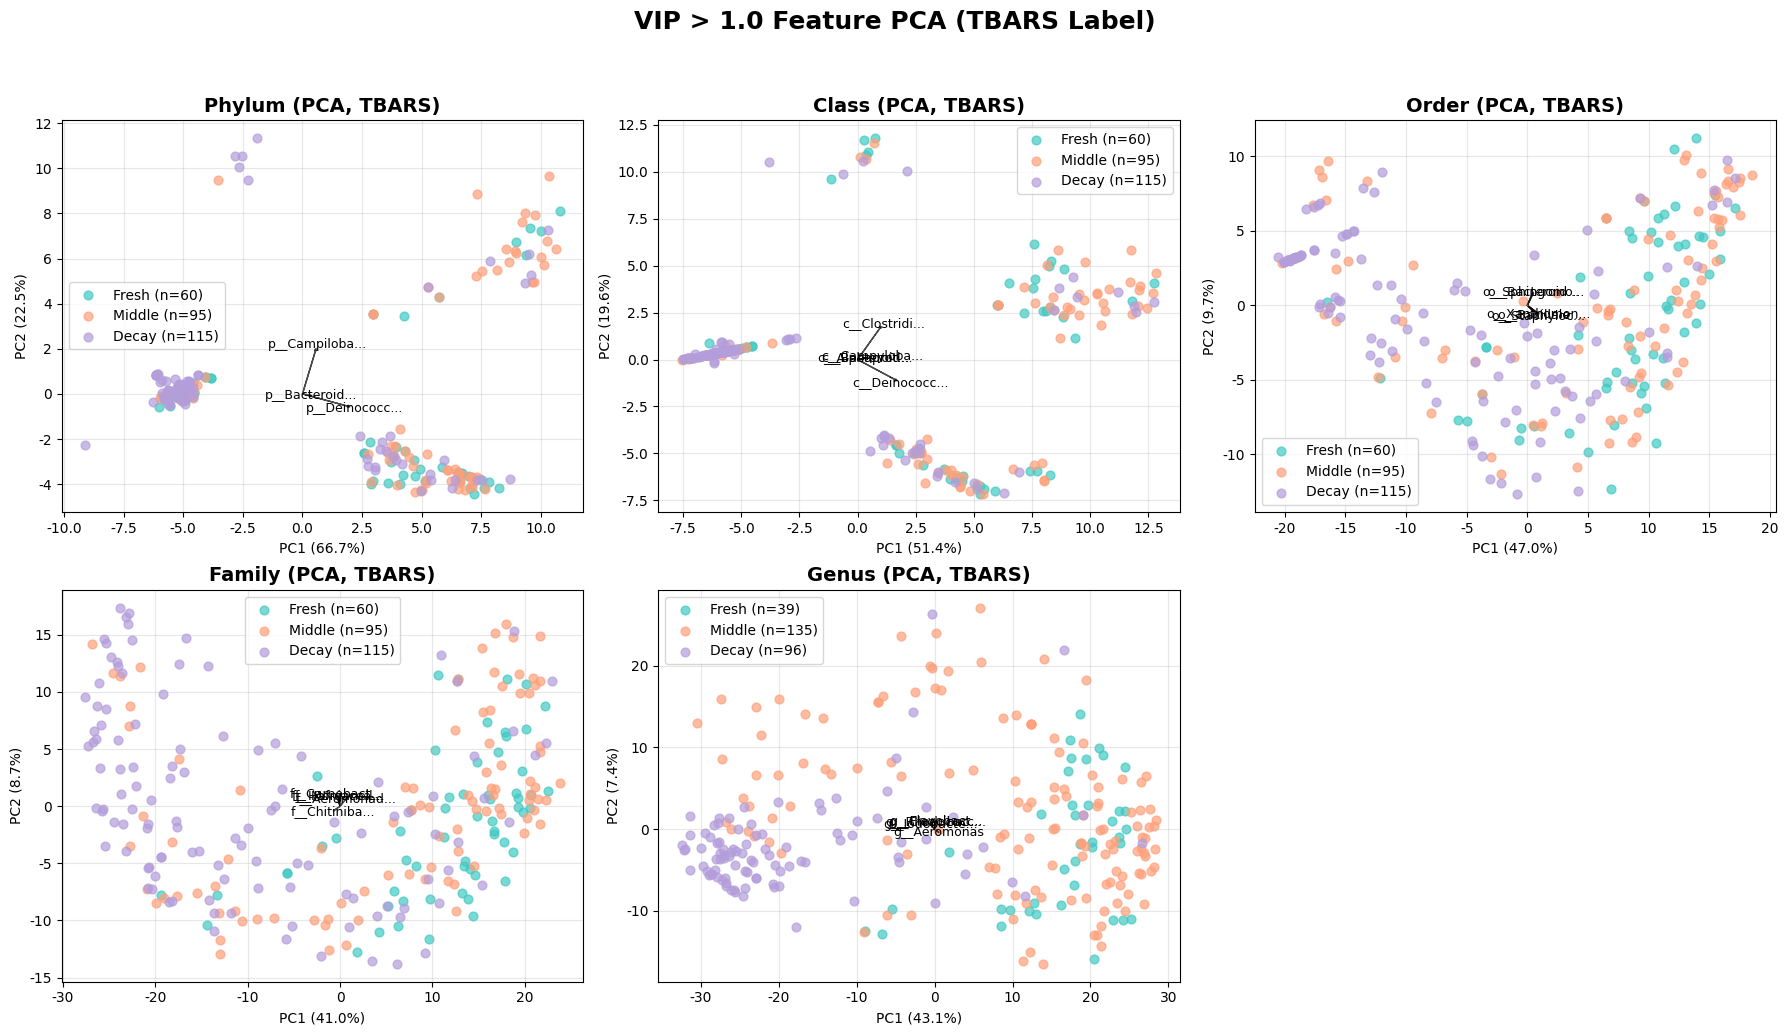

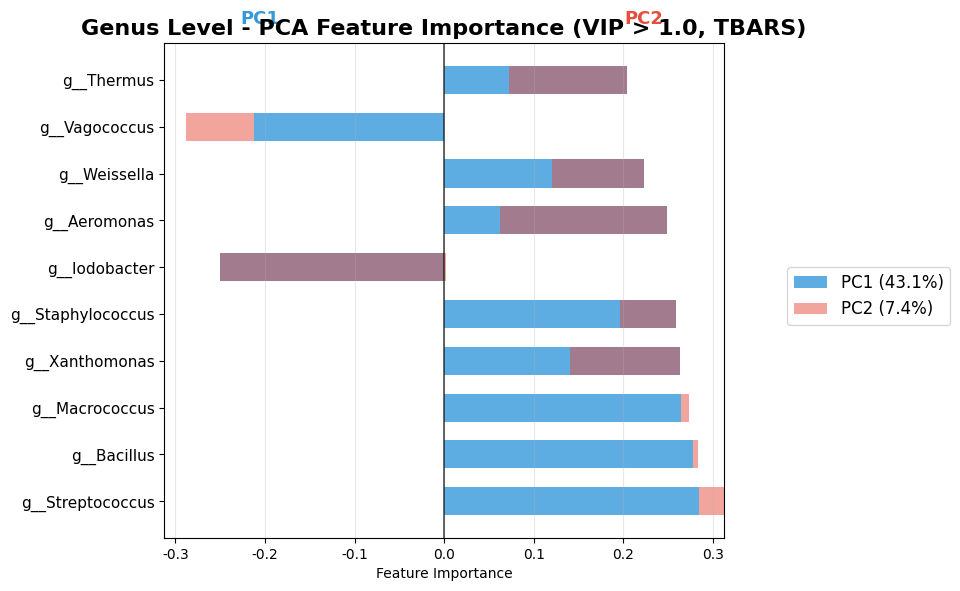

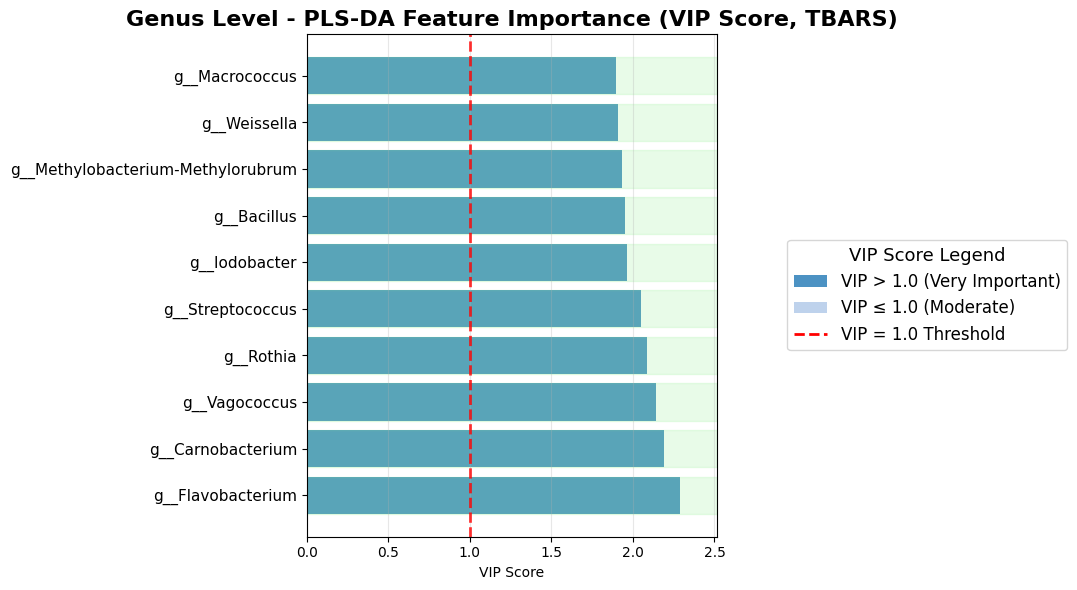

In [16]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from IPython.display import display

# 전처리된 TBARS 데이터 불러오기 (경로 수정)
tbars_preprocess_path = "/Users/taehokim/lab/BRL_AI/BRL_final/CLR_pkl/tbars_preprocessed_info.pkl"
with open(tbars_preprocess_path, 'rb') as f:
    tbars_preprocess_info = pickle.load(f)

# 전처리된 TBARS 데이터 추출
df_tbars_processed = tbars_preprocess_info['processed_df']

# get_level_data 함수 오버라이드 - 전처리된 TBARS 사용 (기존 함수명 유지)
def get_level_data_with_preprocessed_tbars(level_name):
    """전처리된 TBARS를 사용하는 특정 taxonomy level의 데이터를 반환하는 함수"""
    for name, data in final_taxonomic_levels:
        if name.lower() == level_name.lower():
            feature_cols = [col for col in data.columns if col not in ['Description', 'TPC (log CFU/g)', 'TBARS']]
            
            # Genus level인 경우 전처리된 TBARS 사용
            if name.lower() == 'genus':
                processed_tbars = df_tbars_processed['TBARS_preprocessed']
                return {
                    'data': data,
                    'features': data[feature_cols],
                    'feature_names': feature_cols,
                    'tpc': data['TPC (log CFU/g)'],
                    'tbars': processed_tbars,  # 전처리된 TBARS 사용
                    'description': data['Description'],
                    'significant_features': anova_results[name]['significant_features'],
                    'anova_results': anova_results[name],
                    'change_analysis': change_analysis_results[name]
                }
            else:
                return {
                    'data': data,
                    'features': data[feature_cols],
                    'feature_names': feature_cols,
                    'tpc': data['TPC (log CFU/g)'],
                    'tbars': data['TBARS'],  # 다른 레벨은 원본 사용
                    'description': data['Description'],
                    'significant_features': anova_results[name]['significant_features'],
                    'anova_results': anova_results[name],
                    'change_analysis': change_analysis_results[name]
                }
    return None

# TBARS 라벨링 함수 (수정된 임계값 사용)
def tbars_labeling(tbars_series):
    return np.where(
        tbars_series < 0.187, 0,
        np.where(tbars_series < 0.301, 1, 2)  # 0.301 → 0.298로 수정
    )  # 0: Fresh, 1: Middle, 2: Decay

level_names = ['Phylum', 'Class', 'Order', 'Family', 'Genus']
colors = {0: "#40c9c3", 1: "#ffa07a", 2: "#b39ddb"}
label_names = {0: "Fresh", 1: "Middle", 2: "Decay"}

# 1. VIP Score 1.0 이상 feature display 및 저장 (전처리된 TBARS 사용, 기존 변수명 유지)
vip_score_tbars = {}

for level_name in level_names:
    print(f"\n{'='*60}")
    print(f"=== {level_name} Level: VIP Score > 1.0 (전처리된 TBARS 기준) ===")
    print(f"{'='*60}")

    # Genus level은 전처리된 TBARS 사용, 다른 레벨은 기존 함수 사용
    if level_name.lower() == 'genus':
        level_data = get_level_data_with_preprocessed_tbars(level_name)
    else:
        level_data = get_level_data(level_name)
    
    # 괄호가 붙은 feature 제거 (예: g__Enterobacteriaceae(f))
    significant_features = level_data['significant_features']
    filtered_features = [feat for feat in significant_features if '(' not in feat]
    
    print(f"원본 유의 Feature 수: {len(significant_features)}")
    print(f"괄호 제거 후 Feature 수: {len(filtered_features)}")
    print(f"제거된 Feature 수: {len(significant_features) - len(filtered_features)}")
    
    if len(filtered_features) == 0:
        print("괄호 제거 후 사용 가능한 Feature가 없습니다.")
        vip_score_tbars[level_name] = pd.DataFrame(columns=['Feature', 'VIP_Score'])
        continue
    
    X = level_data['features'][filtered_features]
    y = tbars_labeling(level_data['tbars'])

    # One-hot encoding
    y_onehot = np.zeros((len(y), 3))
    for i in range(len(y)):
        y_onehot[i, y[i]] = 1

    # PLS-DA
    plsda = PLSRegression(n_components=2, scale=False)
    plsda.fit(X, y_onehot)

    # VIP score 계산
    x_weights = plsda.x_weights_
    SS = np.sum(x_weights**2, axis=1)
    vip_scores = np.sqrt(len(X.columns) * SS / np.sum(SS))

    vip_df = pd.DataFrame({
        'Feature': X.columns,
        'VIP_Score': vip_scores
    }).sort_values('VIP_Score', ascending=False)

    vip_over1 = vip_df[vip_df['VIP_Score'] > 1.0].reset_index(drop=True)
    vip_score_tbars[level_name] = vip_over1

    print(f"VIP > 1.0 Feature 개수: {len(vip_over1)} / {len(vip_df)}")
    if len(vip_over1) > 0:
        display(vip_over1)
    else:
        print("VIP > 1.0인 Feature가 없습니다.")
    
    # 전처리된 TBARS 범위 출력 (Genus level만)
    if level_name == 'Genus':
        print(f"전처리된 TBARS 범위: {level_data['tbars'].min():.3f} ~ {level_data['tbars'].max():.3f}")

print("\n=== 모든 Level VIP > 1.0 Feature (전처리된 TBARS 기준, 괄호 Feature 제거) 추출 완료 ===")

# 2. PLS-DA scatter (TBARS 기준) - 기존 코드 유지하되 데이터 소스만 변경
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, level_name in enumerate(level_names):
    # Genus level은 전처리된 TBARS 사용, 다른 레벨은 기존 함수 사용
    if level_name.lower() == 'genus':
        level_data = get_level_data_with_preprocessed_tbars(level_name)
    else:
        level_data = get_level_data(level_name)
        
    tbars = level_data['tbars']
    y = tbars_labeling(tbars)
    vip_features = vip_score_tbars[level_name]['Feature'].tolist()
    if not vip_features:
        print(f"{level_name}: VIP > 1.0 feature 없음, 스킵")
        continue
    X_vip = level_data['features'][vip_features]

    # PLS-DA
    y_onehot = np.zeros((len(y), 3))
    for i in range(len(y)):
        y_onehot[i, y[i]] = 1
    plsda = PLSRegression(n_components=2, scale=False)
    X_pls = plsda.fit_transform(X_vip, y_onehot)[0]
    exp_var = np.var(X_pls, axis=0) / np.sum(np.var(X_pls, axis=0)) * 100

    ax = axes[idx]
    for label in [0, 1, 2]:
        count = np.sum(y == label)
        ax.scatter(
            X_pls[y == label, 0], X_pls[y == label, 1],
            label=f"{label_names[label]} (n={count})", alpha=0.7, s=40, color=colors[label]
        )
    # 벡터(loading) 추가: 상위 5개만
    loadings = plsda.x_weights_
    loading_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
    top_idx = np.argsort(loading_magnitudes)[-5:]
    for i in top_idx:
        ax.arrow(0, 0, loadings[i, 0]*2, loadings[i, 1]*2,
                 color='black', alpha=0.7, head_width=0.1, head_length=0.1)
        feat_name = vip_features[i]
        if len(feat_name) > 12:
            feat_name = feat_name[:12] + '...'
        ax.text(loadings[i, 0]*2.3, loadings[i, 1]*2.3, feat_name, fontsize=9, color='black', ha='center', va='center')
    ax.set_title(f"{level_name} (PLS-DA, TBARS)", fontsize=14, fontweight='bold')
    ax.set_xlabel(f"PLS1 ({exp_var[0]:.1f}%)")
    ax.set_ylabel(f"PLS2 ({exp_var[1]:.1f}%)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='best')

for j in range(len(level_names), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle("VIP > 1.0 Feature PLS-DA (TBARS Label)", fontsize=18, fontweight='bold', y=1.03)
plt.show()

# 3. PCA scatter (TBARS 기준) - 기존 코드 유지하되 데이터 소스만 변경
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, level_name in enumerate(level_names):
    # Genus level은 전처리된 TBARS 사용, 다른 레벨은 기존 함수 사용
    if level_name.lower() == 'genus':
        level_data = get_level_data_with_preprocessed_tbars(level_name)
    else:
        level_data = get_level_data(level_name)
        
    tbars = level_data['tbars']
    y = tbars_labeling(tbars)
    vip_features = vip_score_tbars[level_name]['Feature'].tolist()
    if not vip_features:
        print(f"{level_name}: VIP > 1.0 feature 없음, 스킵")
        continue
    X_vip = level_data['features'][vip_features]

    # PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_vip)
    exp_var = pca.explained_variance_ratio_ * 100

    ax = axes[idx]
    for label in [0, 1, 2]:
        count = np.sum(y == label)
        ax.scatter(
            X_pca[y == label, 0], X_pca[y == label, 1],
            label=f"{label_names[label]} (n={count})", alpha=0.7, s=40, color=colors[label]
        )
    # 벡터(loading) 추가: 상위 5개만
    loadings = pca.components_.T
    loading_magnitudes = np.sqrt(loadings[:, 0]**2 + loadings[:, 1]**2)
    top_idx = np.argsort(loading_magnitudes)[-5:]
    for i in top_idx:
        ax.arrow(0, 0, loadings[i, 0]*2, loadings[i, 1]*2,
                 color='black', alpha=0.7, head_width=0.1, head_length=0.1)
        feat_name = vip_features[i]
        if len(feat_name) > 12:
            feat_name = feat_name[:12] + '...'
        ax.text(loadings[i, 0]*2.3, loadings[i, 1]*2.3, feat_name, fontsize=9, color='black', ha='center', va='center')
    ax.set_title(f"{level_name} (PCA, TBARS)", fontsize=14, fontweight='bold')
    ax.set_xlabel(f"PC1 ({exp_var[0]:.1f}%)")
    ax.set_ylabel(f"PC2 ({exp_var[1]:.1f}%)")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10, loc='best')

for j in range(len(level_names), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle("VIP > 1.0 Feature PCA (TBARS Label)", fontsize=18, fontweight='bold', y=1.03)
plt.show()

# 4. Genus level mirror bar chart (TBARS 기준, PCA/PLS-DA) - 기존 코드 유지하되 데이터 소스만 변경
level_name = 'Genus'
level_data = get_level_data_with_preprocessed_tbars(level_name)  # 전처리된 TBARS 사용
vip_features = vip_score_tbars[level_name]['Feature'].tolist()
if vip_features:
    # PCA mirror bar chart (Top 10)
    X_vip = level_data['features'][vip_features]
    pca = PCA(n_components=2)
    pca.fit(X_vip)
    loadings = pca.components_.T
    exp_var = pca.explained_variance_ratio_ * 100
    pc1_loadings = loadings[:, 0]
    pc2_loadings = loadings[:, 1]
    feature_names = np.array(vip_features)
    top10_idx = np.argsort(np.abs(pc1_loadings))[-10:][::-1]
    top10_features = feature_names[top10_idx]
    top10_pc1 = pc1_loadings[top10_idx]
    top10_pc2 = pc2_loadings[top10_idx]
    ind = np.arange(len(top10_features))
    height = 0.6
    fig, ax = plt.subplots(figsize=(8, 6))
    bars1 = ax.barh(ind, top10_pc1, height, color='#3498db', label=f'PC1 ({exp_var[0]:.1f}%)', alpha=0.8)
    bars2 = ax.barh(ind, top10_pc2, height, color='#e74c3c', label=f'PC2 ({exp_var[1]:.1f}%)', left=top10_pc1, alpha=0.5)
    ax.set_yticks(ind)
    ax.set_yticklabels(top10_features, fontsize=11)
    ax.set_xlabel('Feature Importance')
    ax.set_title('Genus Level - PCA Feature Importance (VIP > 1.0, TBARS)', fontsize=16, fontweight='bold')
    ax.axvline(0, color='black', linewidth=1.2, alpha=0.7)
    fig.legend(loc='center left', bbox_to_anchor=(0.98, 0.5), fontsize=12)
    ax.text(-max(abs(top10_pc1))*0.8, len(top10_features)+0.2, 'PC1', color='#3498db', fontsize=13, fontweight='bold')
    ax.text(max(abs(top10_pc2))*0.8, len(top10_features)+0.2, 'PC2', color='#e74c3c', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    max_val = max(np.max(np.abs(top10_pc1)), np.max(np.abs(top10_pc2)))
    ax.set_xlim(-max_val*1.1, max_val*1.1)
    plt.tight_layout(rect=[0, 0, 0.93, 1])
    plt.show()

    # VIP Score mirror bar chart (Top 10, PLS-DA)
    vip_df = vip_score_tbars[level_name]
    top10_vip = vip_df.sort_values('VIP_Score', ascending=False).head(10)
    top10_features_vip = top10_vip['Feature'].values
    top10_scores = top10_vip['VIP_Score'].values
    fig, ax = plt.subplots(figsize=(8, 6))
    bars = ax.barh(np.arange(10), top10_scores, color=['#1f77b4' if v > 1.0 else '#aec7e8' for v in top10_scores], alpha=0.8)
    ax.set_yticks(np.arange(10))
    ax.set_yticklabels(top10_features_vip, fontsize=11)
    ax.set_xlabel('VIP Score')
    ax.set_title('Genus Level - PLS-DA Feature Importance (VIP Score, TBARS)', fontsize=16, fontweight='bold')
    ax.axvline(1.0, color='red', linestyle='--', linewidth=2, alpha=0.8)
    ax.grid(True, alpha=0.3, axis='x')
    for i in range(np.sum(top10_scores > 1.0)):
        ax.axhspan(i-0.4, i+0.4, alpha=0.2, color='lightgreen')
    ax.set_xlim(0, max(top10_scores)*1.1)
    legend_elements = [
        plt.Rectangle((0, 0), 1, 1, facecolor='#1f77b4', alpha=0.8, label='VIP > 1.0 (Very Important)'),
        plt.Rectangle((0, 0), 1, 1, facecolor='#aec7e8', alpha=0.8, label='VIP ≤ 1.0 (Moderate)'),
        plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='VIP = 1.0 Threshold')
    ]
    fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0.98, 0.5), fontsize=12, title='VIP Score Legend', title_fontsize=13)
    plt.tight_layout(rect=[0, 0, 0.93, 1])
    plt.show()

## TBARS 기준으로 뽑힌 VIP Score 1.0 Feature 상관관계 분석

In [17]:
# TBARS 기준 VIP > 1.0 feature의 Genus level 상관관계 분석 Heatmap

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Genus level 데이터 및 VIP > 1.0 feature 추출
level_name = 'Genus'
level_data = get_level_data(level_name)
if level_data is None:
    print(f"{level_name}: 데이터 없음, 스킵")
else:
    # TBARS 기준 VIP > 1.0 feature 리스트
    vip_features = vip_score_tbars[level_name]['Feature'].tolist()
    if not vip_features:
        print(f"{level_name}: VIP > 1.0 feature 없음, 스킵")
    else:
        # Feature + TBARS + TPC 데이터프레임 생성
        X_vip = level_data['features'][vip_features].copy()
        X_vip['TBARS'] = level_data['tbars']
        X_vip['TPC (log CFU/g)'] = level_data['tpc']

        # 상관계수 행렬 계산
        corr_matrix = X_vip.corr()

        # 히트맵 시각화 (논문 스타일, 폰트/크기/색상 강조)
        plt.figure(figsize=(min(1.2*len(X_vip.columns), 22), min(1.2*len(X_vip.columns), 18)))
        ax = sns.heatmap(
            corr_matrix,
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1.2,
            cbar_kws={"shrink": 0.7, "label": "Correlation Coefficient"},
            xticklabels=True,
            yticklabels=True,
            annot=True,
            annot_kws={"size": 13, "weight": "bold"},
            fmt=".2f"
        )
        plt.title('Genus VIP>1.0 Feature + TBARS/TPC Correlation Heatmap (TBARS)', fontsize=26, fontweight='bold', pad=18)
        plt.xticks(rotation=60, fontsize=15, ha='right')
        plt.yticks(rotation=0, fontsize=15)
        ax.tick_params(axis='both', which='major', length=0)
        plt.tight_layout()
        plt.show()

KeyboardInterrupt: 

## PC1 VIP Score Feature Importance 

/var/folders/f5/vpc6wvfd0d9g1tdw0h3gqqcc0000gn/T/ipykernel_6737/2872172160.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(x):.3f}' for x in ax.get_xticks()])


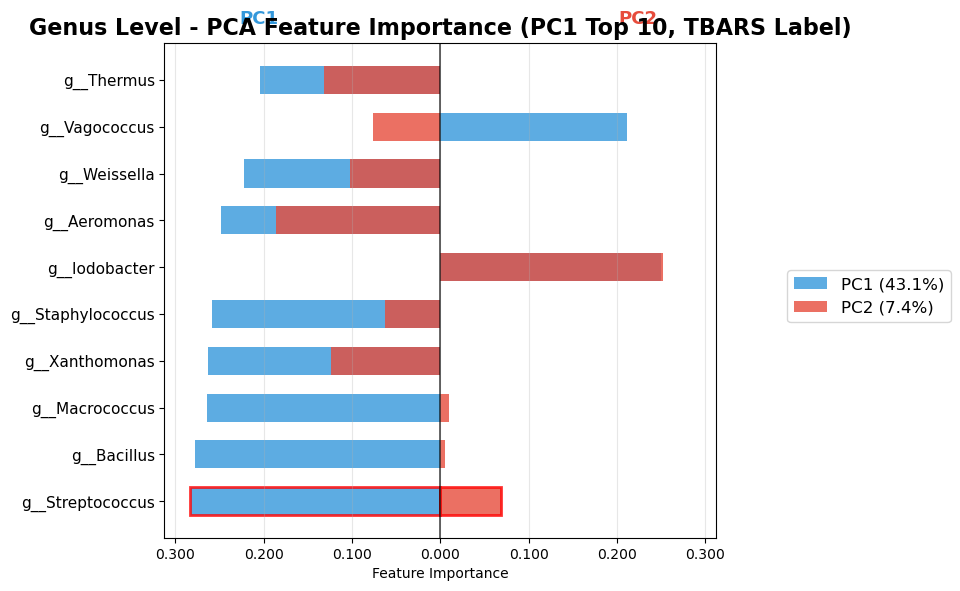

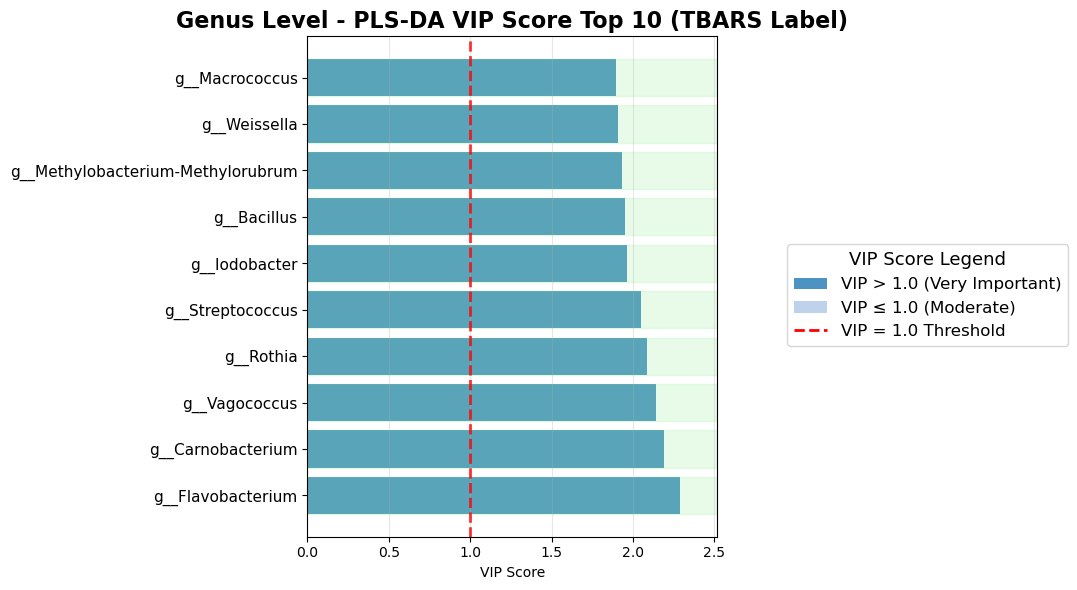

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1. TBARS 기준 Genus level PC1 Top 10 mirror bar chart
level_name = 'Genus'
level_data = get_level_data(level_name)
vip_features = vip_score_tbars[level_name]['Feature'].tolist()
if not vip_features:
    print(f"{level_name}: VIP > 1.0 feature 없음, 스킵")
else:
    X_vip = level_data['features'][vip_features]
    pca = PCA(n_components=2)
    pca.fit(X_vip)
    loadings = pca.components_.T
    exp_var = pca.explained_variance_ratio_ * 100

    pc1_loadings = loadings[:, 0]
    pc2_loadings = loadings[:, 1]
    feature_names = np.array(vip_features)
    top10_idx = np.argsort(np.abs(pc1_loadings))[-10:][::-1]
    top10_features = feature_names[top10_idx]
    top10_pc1 = pc1_loadings[top10_idx]
    top10_pc2 = pc2_loadings[top10_idx]

    ind = np.arange(len(top10_features))
    height = 0.6

    fig, ax = plt.subplots(figsize=(8, 6))
    bars1 = ax.barh(ind, -top10_pc1, height, color='#3498db', label=f'PC1 ({exp_var[0]:.1f}%)', alpha=0.8)
    bars2 = ax.barh(ind, top10_pc2, height, color='#e74c3c', label=f'PC2 ({exp_var[1]:.1f}%)', alpha=0.8)
    ax.set_yticks(ind)
    ax.set_yticklabels(top10_features, fontsize=11)
    ax.set_xlabel('Feature Importance')
    ax.set_title('Genus Level - PCA Feature Importance (PC1 Top 10, TBARS Label)', fontsize=16, fontweight='bold')
    ax.axvline(0, color='black', linewidth=1.2, alpha=0.7)
    fig.legend(loc='center left', bbox_to_anchor=(0.98, 0.5), fontsize=12)
    ax.text(-max(abs(top10_pc1))*0.8, len(top10_features)+0.2, 'PC1', color='#3498db', fontsize=13, fontweight='bold')
    ax.text(max(abs(top10_pc2))*0.8, len(top10_features)+0.2, 'PC2', color='#e74c3c', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    max_val = max(np.max(np.abs(top10_pc1)), np.max(np.abs(top10_pc2)))
    ax.set_xlim(-max_val*1.1, max_val*1.1)
    bars1[0].set_edgecolor('red'); bars1[0].set_linewidth(2)
    bars2[0].set_edgecolor('red'); bars2[0].set_linewidth(2)
    ax.set_xticklabels([f'{abs(x):.3f}' for x in ax.get_xticks()])
    plt.tight_layout(rect=[0, 0, 0.93, 1])
    plt.show()

# 2. TBARS 기준 Genus level VIP Score Top 10 mirror bar chart
vip_df = vip_score_tbars[level_name]
top10_vip = vip_df.sort_values('VIP_Score', ascending=False).head(10)
top10_features_vip = top10_vip['Feature'].values
top10_scores = top10_vip['VIP_Score'].values

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(np.arange(10), top10_scores, color=['#1f77b4' if v > 1.0 else '#aec7e8' for v in top10_scores], alpha=0.8)
ax.set_yticks(np.arange(10))
ax.set_yticklabels(top10_features_vip, fontsize=11)
ax.set_xlabel('VIP Score')
ax.set_title('Genus Level - PLS-DA VIP Score Top 10 (TBARS Label)', fontsize=16, fontweight='bold')
ax.axvline(1.0, color='red', linestyle='--', linewidth=2, alpha=0.8)
ax.grid(True, alpha=0.3, axis='x')
for i in range(np.sum(top10_scores > 1.0)):
    ax.axhspan(i-0.4, i+0.4, alpha=0.2, color='lightgreen')
ax.set_xlim(0, max(top10_scores)*1.1)
legend_elements = [
    plt.Rectangle((0, 0), 1, 1, facecolor='#1f77b4', alpha=0.8, label='VIP > 1.0 (Very Important)'),
    plt.Rectangle((0, 0), 1, 1, facecolor='#aec7e8', alpha=0.8, label='VIP ≤ 1.0 (Moderate)'),
    plt.Line2D([0], [0], color='red', linestyle='--', linewidth=2, label='VIP = 1.0 Threshold')
]
fig.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(0.98, 0.5), fontsize=12, title='VIP Score Legend', title_fontsize=13)
plt.tight_layout(rect=[0, 0, 0.93, 1])
plt.show()

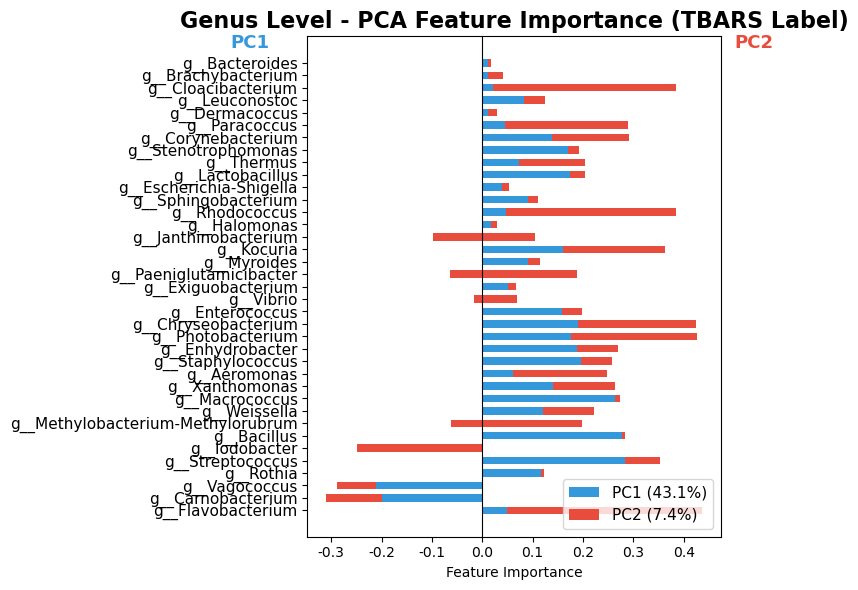

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Genus level mirror bar chart (TBARS 기준)
level_name = 'Genus'
level_data = get_level_data(level_name)
vip_features = vip_score_tbars[level_name]['Feature'].tolist()
if not vip_features:
    print(f"{level_name}: VIP > 1.0 feature 없음, 스킵")
else:
    X_vip = level_data['features'][vip_features]

    # PCA
    pca = PCA(n_components=2)
    pca.fit(X_vip)
    loadings = pca.components_.T  # shape: (feature, PC)
    exp_var = pca.explained_variance_ratio_ * 100

    feature_names = vip_features
    pc1_loadings = loadings[:, 0]
    pc2_loadings = loadings[:, 1]

    ind = np.arange(len(feature_names))
    height = 0.6

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(ind, pc1_loadings, height, color='#3498db', label=f'PC1 ({exp_var[0]:.1f}%)')
    ax.barh(ind, pc2_loadings, height, color='#e74c3c', label=f'PC2 ({exp_var[1]:.1f}%)', left=pc1_loadings)

    ax.set_yticks(ind)
    ax.set_yticklabels(feature_names, fontsize=11)
    ax.set_xlabel('Feature Importance')
    ax.set_title('Genus Level - PCA Feature Importance (TBARS Label)', fontsize=16, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.legend(loc='lower right', fontsize=11)
    ax.text(-0.5, len(feature_names)+0.2, 'PC1', color='#3498db', fontsize=13, fontweight='bold')
    ax.text(0.5, len(feature_names)+0.2, 'PC2', color='#e74c3c', fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()

## TPC 분류 모델 학습 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# TPC 라벨링 함수
def tpc_labeling(tpc_series):
    return np.where(
        tpc_series < 4.369, 0, 
        np.where(tpc_series < 6.427, 1, 2)
    )  # 0: Fresh, 1: Middle, 2: Decay

# TBARS 라벨링 함수
def tbars_labeling(tbars_series):
    return np.where(
        tbars_series < 0.187, 0,
        np.where(tbars_series < 0.301, 1, 2)
    )  # 0: Fresh, 1: Middle, 2: Decay

# 모델 및 파라미터 정의
models = {
    "RandomForest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [5, 10, None],
            "min_samples_split": [2, 5]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(random_state=42, eval_metric='mlogloss'),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.01, 0.1, 0.2]
        }
    },
    "SVC": {
        "model": SVC(random_state=42, probability=True),
        "params": {
            "C": [0.1, 1, 10],
            "kernel": ["rbf", "linear"],
            "gamma": ["scale", "auto"]
        }
    },
    "LogisticRegression": {
        "model": LogisticRegression(random_state=42, max_iter=1000),
        "params": {
            "C": [0.1, 1, 10],
            "solver": ["liblinear", "lbfgs"]
        }
    },
    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7, 9],
            "weights": ["uniform", "distance"]
        }
    }
}

# TPC 기준 모델 학습 (CLR 변환된 데이터로 스케일링 불필요)
print("=== TPC 기준 VIP > 1.0 Features 모델 학습 (CLR 변환 완료) ===")
all_model_results = {}

for level_name in ['Phylum', 'Class', 'Order', 'Family', 'Genus']:
    print(f"\n[{level_name} Level]")
    all_model_results[level_name] = {}
    
    # 데이터 준비
    level_data = get_level_data(level_name)
    if level_data is None:
        print(f"  데이터 없음, 스킵")
        continue
    
    # VIP > 1.0 features 사용
    vip_features = vip_over1_dict[level_name]['Feature'].tolist()
    if not vip_features:
        print(f"  VIP > 1.0 feature 없음, 스킵")
        continue
    
    X = level_data['features'][vip_features]
    y = tpc_labeling(level_data['tpc'])
    
    # Train/Test 분할
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # 각 모델 학습 (모든 모델에 동일한 원본 CLR 데이터 사용)
    for model_name, model_info in models.items():
        print(f"  {model_name} 학습 중...")
        
        # GridSearch
        grid_search = GridSearchCV(
            model_info["model"], 
            model_info["params"], 
            cv=3, 
            scoring='f1_macro',
            n_jobs=-1
        )
        
        # 모든 모델에 원본 CLR 데이터 사용
        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_
        
        # 예측
        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)
        
        # 결과 저장
        all_model_results[level_name][model_name] = {
            "Best_Model": best_model,
            "Best_Params": grid_search.best_params_,
            "X_test": X_test,  # 원본 CLR 데이터
            "y_test": y_test,
            "train_accuracy": accuracy_score(y_train, y_train_pred),
            "test_accuracy": accuracy_score(y_test, y_test_pred),
            "train_f1_score": f1_score(y_train, y_train_pred, average='macro'),
            "test_f1_score": f1_score(y_test, y_test_pred, average='macro'),
            "Overfitting_Acc": accuracy_score(y_train, y_train_pred) - accuracy_score(y_test, y_test_pred),
            "Overfitting_F1": f1_score(y_train, y_train_pred, average='macro') - f1_score(y_test, y_test_pred, average='macro')
        }
        
        print(f"    Test Acc: {all_model_results[level_name][model_name]['test_accuracy']:.3f}, "
              f"Test F1: {all_model_results[level_name][model_name]['test_f1_score']:.3f}")

print("\n=== TPC 기준 모델 학습 완료 ===")

=== TPC 기준 VIP > 1.0 Features 모델 학습 (CLR 변환 완료) ===

[Phylum Level]
  RandomForest 학습 중...
    Test Acc: 0.685, Test F1: 0.563
  XGBoost 학습 중...
    Test Acc: 0.685, Test F1: 0.597
  SVC 학습 중...
    Test Acc: 0.648, Test F1: 0.551
  LogisticRegression 학습 중...
    Test Acc: 0.778, Test F1: 0.671
  KNN 학습 중...
    Test Acc: 0.722, Test F1: 0.648

[Class Level]
  RandomForest 학습 중...
    Test Acc: 0.685, Test F1: 0.574
  XGBoost 학습 중...
    Test Acc: 0.593, Test F1: 0.452
  SVC 학습 중...
    Test Acc: 0.796, Test F1: 0.683
  LogisticRegression 학습 중...
    Test Acc: 0.778, Test F1: 0.671
  KNN 학습 중...
    Test Acc: 0.759, Test F1: 0.716

[Order Level]
  RandomForest 학습 중...
    Test Acc: 0.778, Test F1: 0.680
  XGBoost 학습 중...
    Test Acc: 0.741, Test F1: 0.685
  SVC 학습 중...
    Test Acc: 0.815, Test F1: 0.787
  LogisticRegression 학습 중...
    Test Acc: 0.815, Test F1: 0.782
  KNN 학습 중...
    Test Acc: 0.815, Test F1: 0.782

[Family Level]
  RandomForest 학습 중...
    Test Acc: 0.833, Test F1:

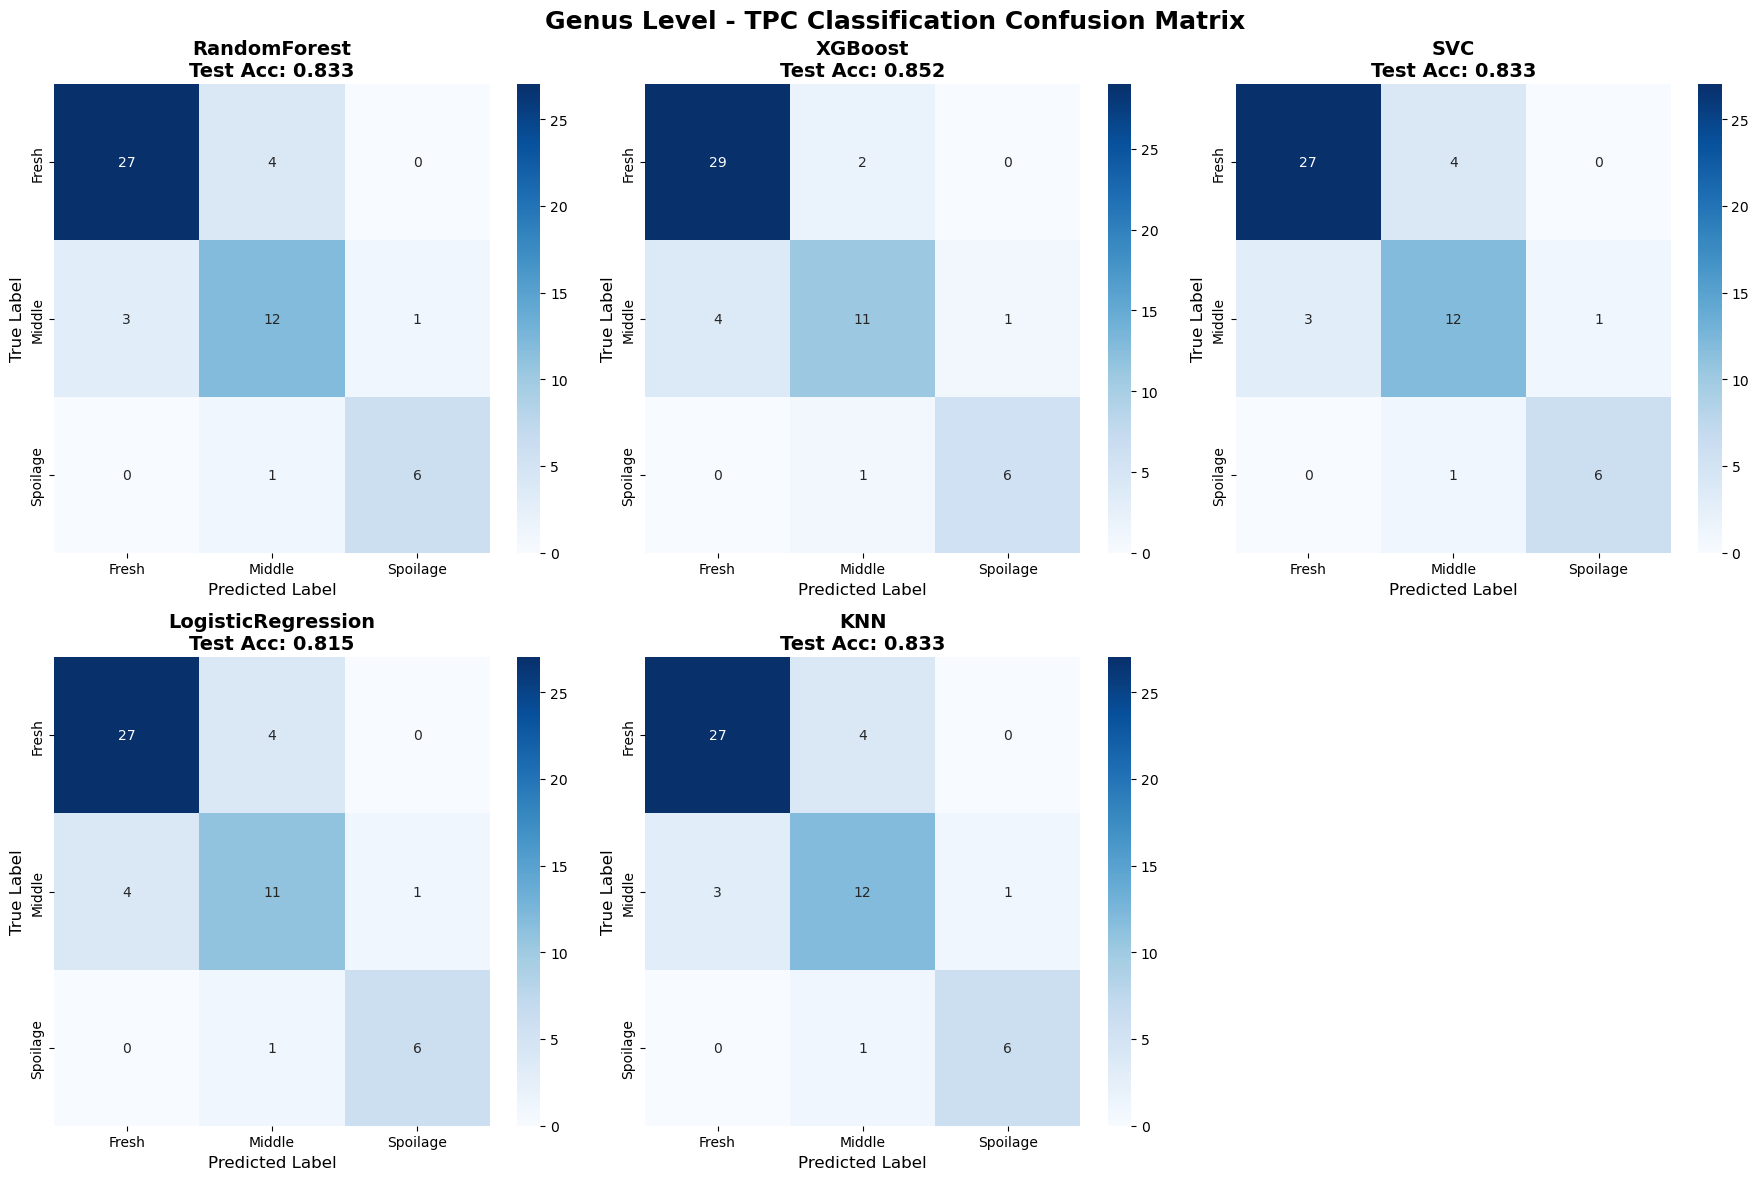

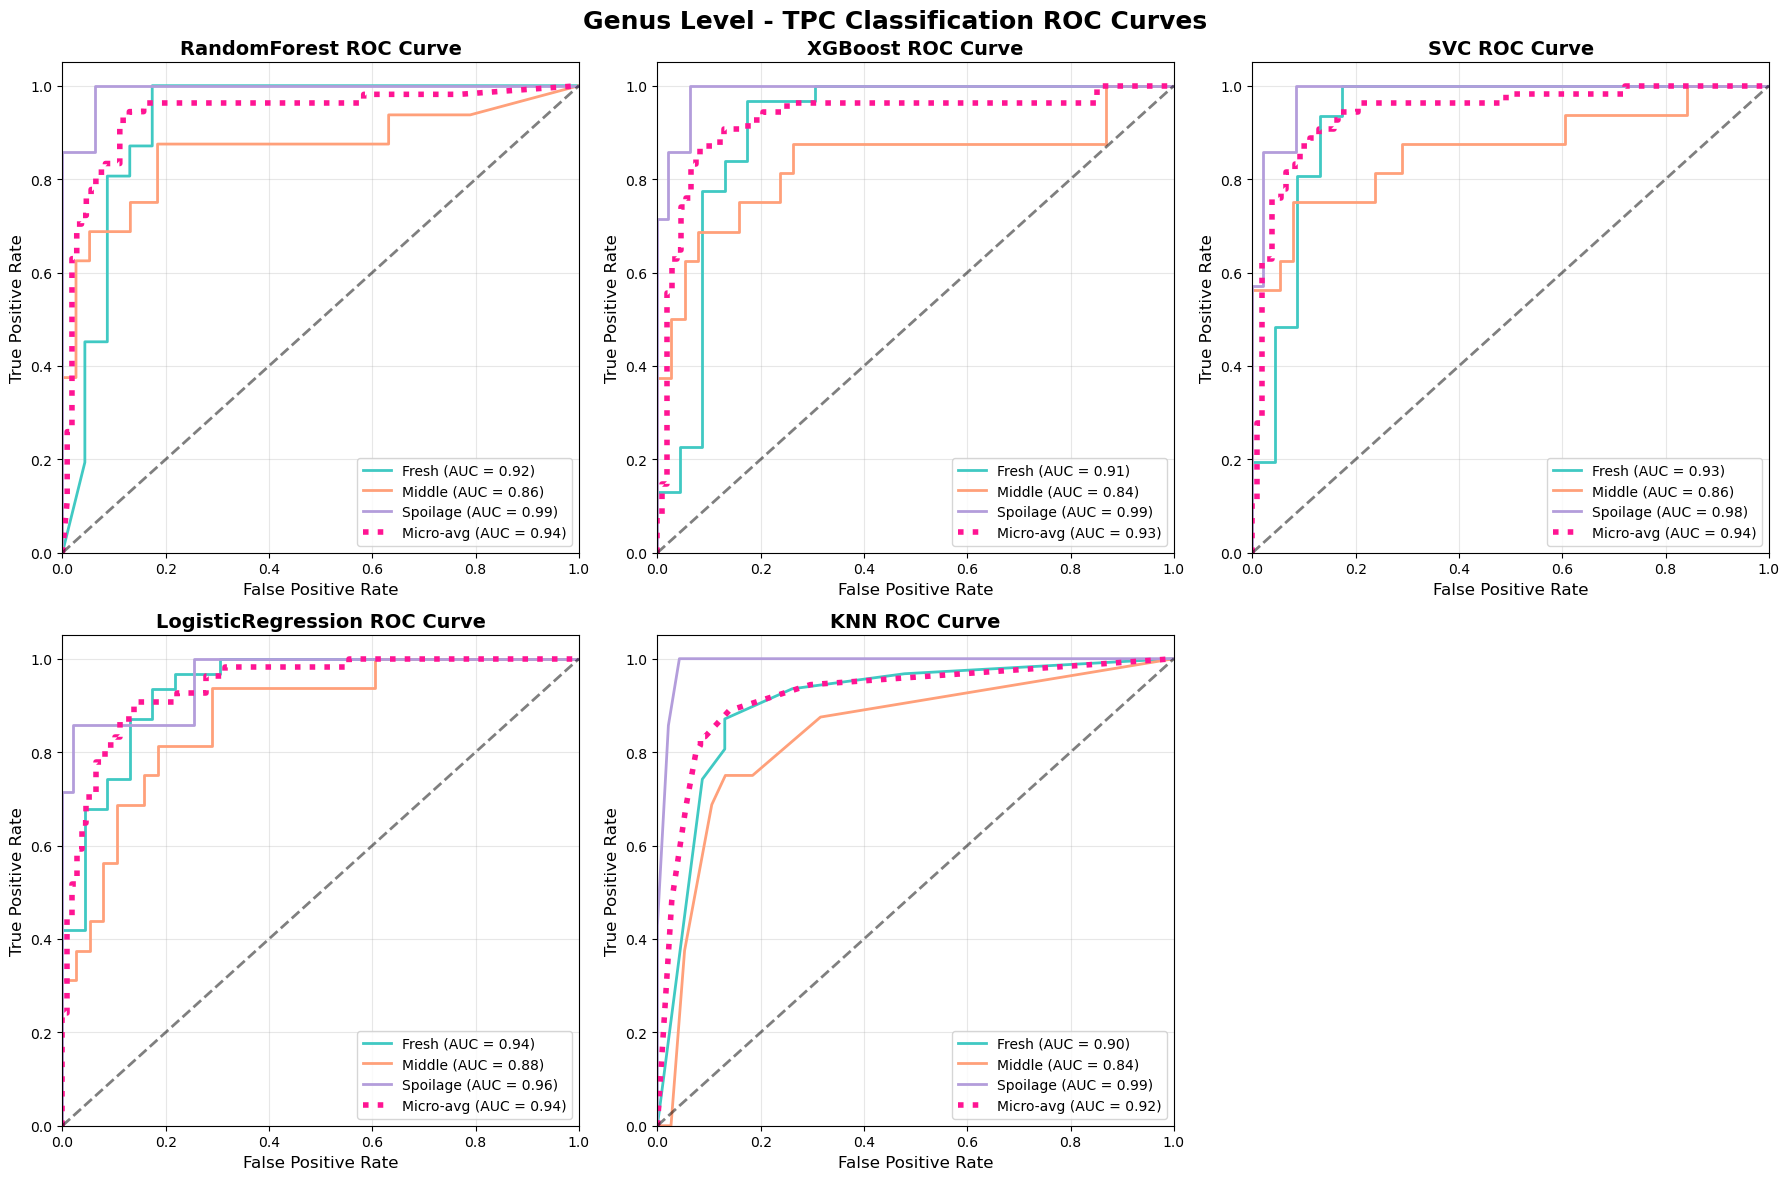


=== Genus Level TPC 분류 모델 성능 요약 ===
             Model Train_Acc Test_Acc Train_F1 Test_F1 Overfit_Acc Overfit_F1
      RandomForest     0.963    0.833    0.950   0.823      +0.130     +0.126
           XGBoost     1.000    0.852    1.000   0.832      +0.148     +0.168
               SVC     0.926    0.833    0.903   0.823      +0.093     +0.080
LogisticRegression     0.935    0.815    0.910   0.805      +0.120     +0.105
               KNN     0.912    0.833    0.884   0.823      +0.079     +0.060


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
import warnings
warnings.filterwarnings('ignore')

# Genus level TPC 분류 모델 성능 시각화
def plot_genus_model_performance():
    """Genus level TPC 분류 모델의 Confusion Matrix와 ROC Curve 시각화"""
    
    # all_model_results가 정의되어 있는지 확인
    if 'all_model_results' not in globals():
        print("❌ all_model_results가 정의되지 않았습니다. 먼저 모델 학습을 실행해주세요.")
        return
    
    taxonomy_level = 'Genus'
    
    if taxonomy_level not in all_model_results:
        print(f"❌ {taxonomy_level} 레벨의 모델 결과가 없습니다.")
        return
    
    # 사용할 모델 리스트
    model_list = ['RandomForest', 'XGBoost', 'SVC', 'LogisticRegression', 'KNN']
    
    # 색상 매핑
    colors = {0: "#40c9c3", 1: "#ffa07a", 2: "#b39ddb"}
    label_names = {0: "Fresh", 1: "Middle", 2: "Spoilage"}
    
    # 1. Confusion Matrix 시각화
    fig_cm, axes_cm = plt.subplots(2, 3, figsize=(18, 12))
    axes_cm = axes_cm.flatten()
    
    for idx, model in enumerate(model_list):
        if model not in all_model_results[taxonomy_level]:
            print(f"⚠️  {model} 모델 결과가 없습니다.")
            continue
            
        # 모델 결과 가져오기
        model_result = all_model_results[taxonomy_level][model]
        best_model = model_result["Best_Model"]
        X_test = model_result["X_test"]
        y_test = model_result["y_test"]
        
        # 예측
        y_pred = best_model.predict(X_test)
        
        # Confusion Matrix 계산
        cm = confusion_matrix(y_test, y_pred)
        
        # Confusion Matrix 시각화
        ax = axes_cm[idx]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                   xticklabels=['Fresh', 'Middle', 'Spoilage'],
                   yticklabels=['Fresh', 'Middle', 'Spoilage'],
                   ax=ax)
        ax.set_title(f'{model}\nTest Acc: {model_result["test_accuracy"]:.3f}', 
                    fontsize=14, fontweight='bold')
        ax.set_xlabel('Predicted Label', fontsize=12)
        ax.set_ylabel('True Label', fontsize=12)
    
    # 빈 subplot 제거
    if len(model_list) < len(axes_cm):
        fig_cm.delaxes(axes_cm[-1])
    
    plt.suptitle(f'{taxonomy_level} Level - TPC Classification Confusion Matrix', 
                fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    # 2. ROC Curve 시각화
    fig_roc, axes_roc = plt.subplots(2, 3, figsize=(18, 12))
    axes_roc = axes_roc.flatten()
    
    for idx, model in enumerate(model_list):
        if model not in all_model_results[taxonomy_level]:
            continue
            
        # 모델 결과 가져오기
        model_result = all_model_results[taxonomy_level][model]
        best_model = model_result["Best_Model"]
        X_test = model_result["X_test"]
        y_test = model_result["y_test"]
        
        # 예측 확률 계산
        if hasattr(best_model, "predict_proba"):
            y_score = best_model.predict_proba(X_test)
        elif hasattr(best_model, "decision_function"):
            y_score = best_model.decision_function(X_test)
            # decision_function이 1D인 경우 처리
            if y_score.ndim == 1:
                # 이진 분류로 변환하거나 스킵
                print(f"⚠️  {model} 모델의 decision_function이 1D입니다. ROC 커브를 건너뜁니다.")
                continue
        else:
            print(f"⚠️  {model} 모델이 확률 예측을 지원하지 않습니다.")
            continue
        
        # 멀티클래스를 위한 label binarization
        y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
        n_classes = y_test_bin.shape[1]
        
        ax = axes_roc[idx]
        
        # 각 클래스별 ROC 커브 계산 및 시각화
        fpr = dict()
        tpr = dict()
        roc_auc = dict()
        
        for i in range(n_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            
            ax.plot(fpr[i], tpr[i], 
                   color=list(colors.values())[i],
                   lw=2, 
                   label=f'{list(label_names.values())[i]} (AUC = {roc_auc[i]:.2f})')
        
        # Micro-average ROC curve
        fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
        
        ax.plot(fpr["micro"], tpr["micro"],
               color='deeppink', linestyle=':', linewidth=4,
               label=f'Micro-avg (AUC = {roc_auc["micro"]:.2f})')
        
        # 대각선 (랜덤 분류기)
        ax.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5)
        
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate', fontsize=12)
        ax.set_ylabel('True Positive Rate', fontsize=12)
        ax.set_title(f'{model} ROC Curve', fontsize=14, fontweight='bold')
        ax.legend(loc="lower right", fontsize=10)
        ax.grid(True, alpha=0.3)
    
    # 빈 subplot 제거
    if len(model_list) < len(axes_roc):
        fig_roc.delaxes(axes_roc[-1])
    
    plt.suptitle(f'{taxonomy_level} Level - TPC Classification ROC Curves', 
                fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    # 3. 성능 요약 테이블
    print(f"\n{'='*80}")
    print(f"=== {taxonomy_level} Level TPC 분류 모델 성능 요약 ===")
    print(f"{'='*80}")
    
    performance_summary = []
    
    for model in model_list:
        if model not in all_model_results[taxonomy_level]:
            continue
            
        model_result = all_model_results[taxonomy_level][model]
        
        performance_summary.append({
            'Model': model,
            'Train_Acc': f"{model_result['train_accuracy']:.3f}",
            'Test_Acc': f"{model_result['test_accuracy']:.3f}",
            'Train_F1': f"{model_result['train_f1_score']:.3f}",
            'Test_F1': f"{model_result['test_f1_score']:.3f}",
            'Overfit_Acc': f"{model_result['Overfitting_Acc']:+.3f}",
            'Overfit_F1': f"{model_result['Overfitting_F1']:+.3f}"
        })
    
    if performance_summary:
        summary_df = pd.DataFrame(performance_summary)
        print(summary_df.to_string(index=False))
    
    print(f"{'='*80}")

# 함수 실행
plot_genus_model_performance()

## SHAP 후분석

🚀 Genus 레벨 SHAP 후분석 시작...

=== Genus Level SHAP Analysis (LogisticRegression) ===
📊 분석 정보:
   • Feature 수: 24
   • Test 샘플 수: 54
   • 클래스 수: 3
   • 모델 성능: Acc=0.815, F1=0.805
   • SHAP 값 형태: <class 'numpy.ndarray'>
   • SHAP 배열 형태: (54, 24, 3)
✅ SHAP 분석 완료

📊 Genus 레벨 SHAP 시각화 시작...

🔍 Genus Level 분석 중...
   📈 Summary Plot 생성...


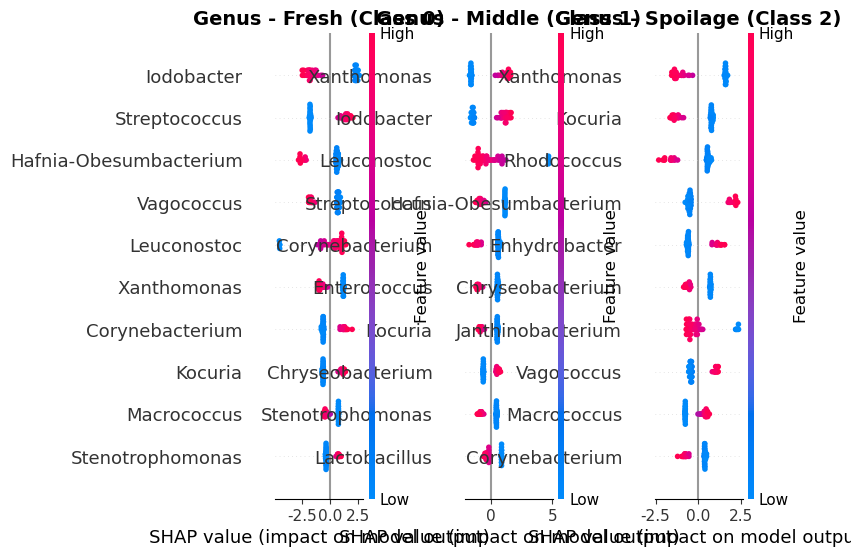

   📊 Feature Importance 분석...


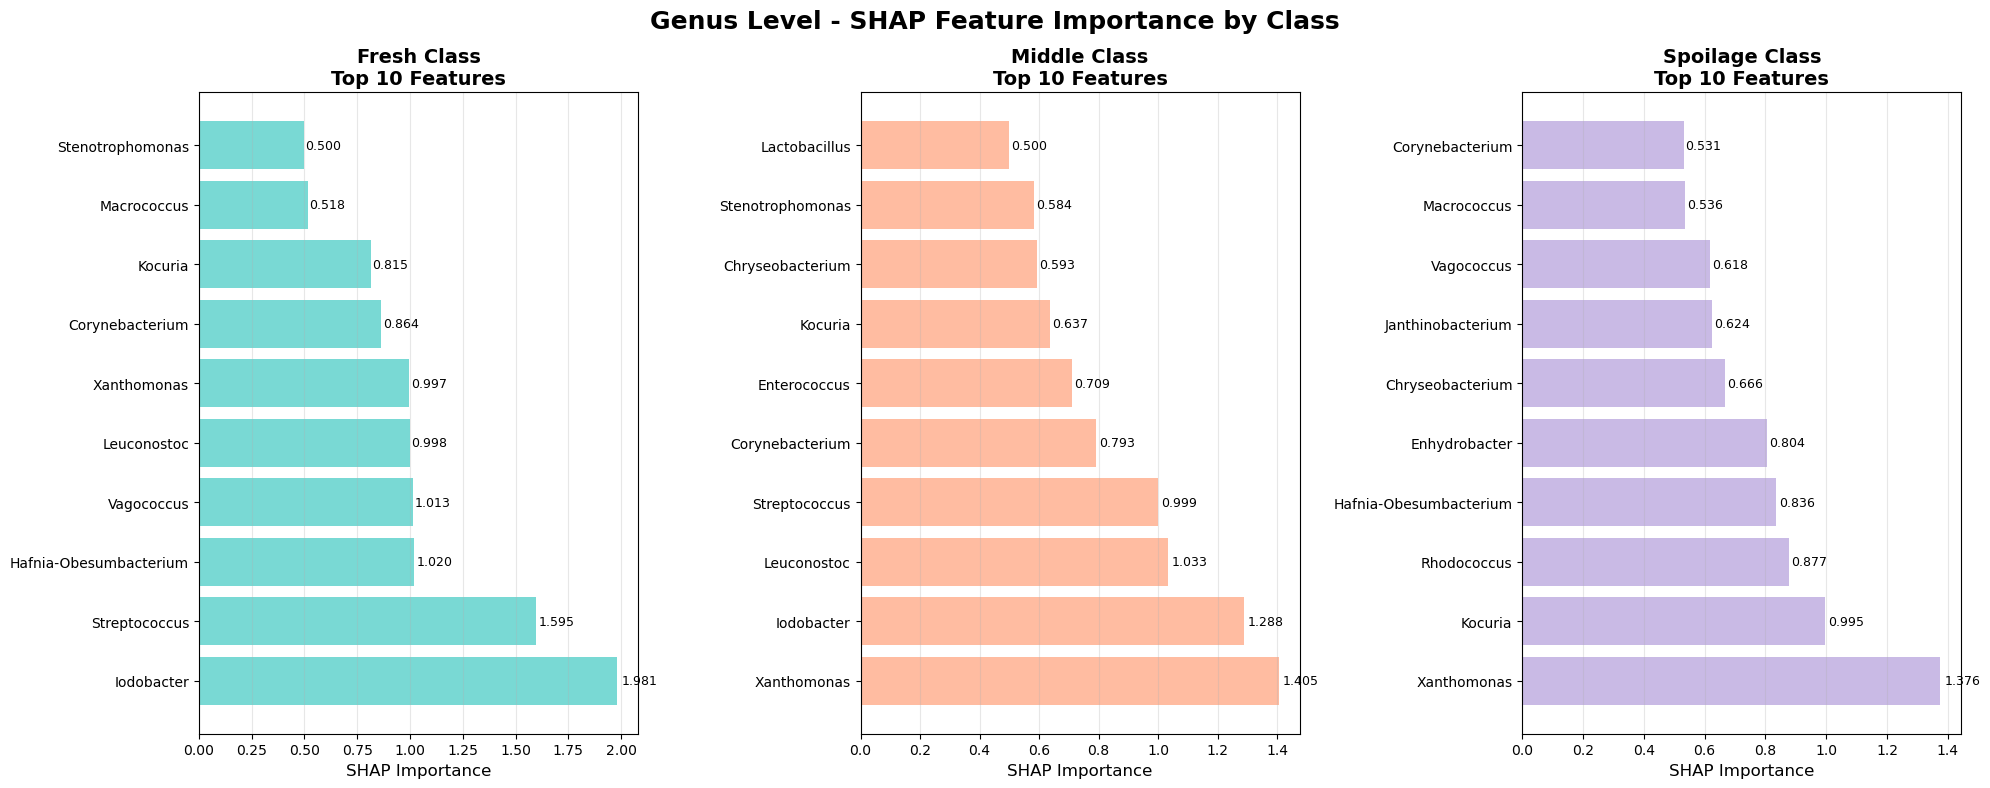


✅ Genus 레벨 SHAP 후분석 완료!

📝 Feature 이름 변환 확인:
원본 Feature 수: 24
정리된 Feature 수: 24

변환 예시:
  g__Hafnia-Obesumbacterium → Hafnia-Obesumbacterium
  g__Lactobacillus → Lactobacillus
  g__Morganella → Morganella
  g__Aeromonas → Aeromonas
  g__Carnobacterium → Carnobacterium


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# SHAP 초기화
shap.initjs()

def perform_shap_analysis_genus_only():
    """Genus 레벨 TPC 분류 모델(LogisticRegression)에 대한 SHAP 후분석"""
    
    # all_model_results가 정의되어 있는지 확인
    if 'all_model_results' not in globals():
        print("❌ all_model_results가 정의되지 않았습니다. 먼저 모델 학습을 실행해주세요.")
        return None
    
    level_name = 'Genus'
    print(f"\n{'='*80}")
    print(f"=== {level_name} Level SHAP Analysis (LogisticRegression) ===")
    print(f"{'='*80}")
    
    # 해당 레벨에 LogisticRegression 결과가 있는지 확인
    if (level_name not in all_model_results or 
        'LogisticRegression' not in all_model_results[level_name]):
        print(f"❌ {level_name} 레벨의 LogisticRegression 결과가 없습니다.")
        return None
    
    # 모델 결과 가져오기
    model_result = all_model_results[level_name]['LogisticRegression']
    best_model = model_result['Best_Model']
    X_test = model_result['X_test']
    y_test = model_result['y_test']
    
    # VIP features 가져오기
    vip_features = vip_over1_dict[level_name]['Feature'].tolist()
    if not vip_features:
        print(f"❌ {level_name}: VIP > 1.0 feature 없음")
        return None
    
    # Feature 이름에서 "g__" 접두사 제거
    clean_feature_names = [feat.replace('g__', '') for feat in vip_features]
    
    print(f"📊 분석 정보:")
    print(f"   • Feature 수: {len(vip_features)}")
    print(f"   • Test 샘플 수: {len(X_test)}")
    print(f"   • 클래스 수: {len(np.unique(y_test))}")
    print(f"   • 모델 성능: Acc={model_result['test_accuracy']:.3f}, F1={model_result['test_f1_score']:.3f}")
    
    try:
        # SHAP Explainer 생성 (LogisticRegression용)
        explainer = shap.LinearExplainer(best_model, X_test)
        shap_values = explainer.shap_values(X_test)
        
        print(f"   • SHAP 값 형태: {type(shap_values)}")
        
        # SHAP 값의 형태 확인 및 처리
        if isinstance(shap_values, list):
            # 다중 클래스: 각 클래스별 SHAP 값이 리스트로 반환
            print(f"   • 다중 클래스 SHAP 값: {len(shap_values)}개 클래스")
            shap_values_class0 = shap_values[0] if len(shap_values) > 0 else None
            shap_values_class1 = shap_values[1] if len(shap_values) > 1 else None
            shap_values_class2 = shap_values[2] if len(shap_values) > 2 else None
            
            for i, sv in enumerate(shap_values):
                print(f"   • 클래스 {i} SHAP 형태: {sv.shape}")
                
        elif isinstance(shap_values, np.ndarray):
            print(f"   • SHAP 배열 형태: {shap_values.shape}")
            
            if shap_values.ndim == 3:
                # 3차원 배열: (samples, features, classes)
                shap_values_class0 = shap_values[:, :, 0] if shap_values.shape[2] > 0 else None
                shap_values_class1 = shap_values[:, :, 1] if shap_values.shape[2] > 1 else None
                shap_values_class2 = shap_values[:, :, 2] if shap_values.shape[2] > 2 else None
            elif shap_values.ndim == 2:
                # 2차원 배열: 단일 클래스 또는 이진 분류
                shap_values_class0 = shap_values
                shap_values_class1 = None
                shap_values_class2 = None
            else:
                print(f"   ⚠️  예상치 못한 SHAP 값 차원: {shap_values.ndim}")
                shap_values_class0 = shap_values
                shap_values_class1 = None
                shap_values_class2 = None
        else:
            print(f"   ⚠️  예상치 못한 SHAP 값 타입: {type(shap_values)}")
            shap_values_class0 = shap_values
            shap_values_class1 = None
            shap_values_class2 = None
        
        # 결과 저장
        shap_result = {
            'explainer': explainer,
            'shap_values': shap_values,
            'shap_values_class0': shap_values_class0,
            'shap_values_class1': shap_values_class1,
            'shap_values_class2': shap_values_class2,
            'X_test': X_test,
            'y_test': y_test,
            'feature_names': clean_feature_names,  # 정리된 이름 사용
            'original_feature_names': vip_features,  # 원본 이름도 보관
            'model': best_model,
            'n_classes': len(np.unique(y_test))
        }
        
        print(f"✅ SHAP 분석 완료")
        return shap_result
        
    except Exception as e:
        print(f"❌ SHAP 분석 중 오류 발생: {str(e)}")
        import traceback
        traceback.print_exc()
        return None

def plot_genus_shap_summary(shap_result, max_display=10):
    """Genus 레벨 SHAP Summary Plot 생성"""
    if shap_result is None:
        print("❌ SHAP 결과가 없습니다.")
        return
    
    try:
        # 다중 클래스 SHAP 시각화
        if shap_result['shap_values_class1'] is not None and shap_result['shap_values_class2'] is not None:
            fig, axes = plt.subplots(1, 3, figsize=(20, 8))
            
            class_names = ['Fresh (Class 0)', 'Middle (Class 1)', 'Spoilage (Class 2)']
            shap_values_list = [
                shap_result['shap_values_class0'],
                shap_result['shap_values_class1'], 
                shap_result['shap_values_class2']
            ]
            
            for idx, (class_name, shap_vals) in enumerate(zip(class_names, shap_values_list)):
                if shap_vals is not None:
                    plt.sca(axes[idx])
                    shap.summary_plot(
                        shap_vals, 
                        shap_result['X_test'], 
                        feature_names=shap_result['feature_names'],  # 정리된 이름 사용
                        max_display=max_display,
                        show=False,
                        plot_type='dot'
                    )
                    plt.title(f'Genus - {class_name}', fontsize=14, fontweight='bold')
                else:
                    axes[idx].text(0.5, 0.5, f'No SHAP values\nfor {class_name}', 
                                 ha='center', va='center', transform=axes[idx].transAxes)
                    axes[idx].set_title(f'Genus - {class_name}', fontsize=14, fontweight='bold')
            
            plt.tight_layout()
            plt.show()
            
        else:
            # 단일 클래스 또는 이진 분류
            plt.figure(figsize=(12, 8))
            if shap_result['shap_values_class0'] is not None:
                shap.summary_plot(
                    shap_result['shap_values_class0'],
                    shap_result['X_test'],
                    feature_names=shap_result['feature_names'],  # 정리된 이름 사용
                    max_display=max_display,
                    show=False
                )
                plt.title('Genus Level - SHAP Summary Plot', fontsize=16, fontweight='bold')
            else:
                plt.text(0.5, 0.5, 'No SHAP values available', ha='center', va='center')
                plt.title('Genus Level - SHAP Summary Plot (No Data)', fontsize=16, fontweight='bold')
            
            plt.tight_layout()
            plt.show()
            
    except Exception as e:
        print(f"❌ Genus Summary Plot 생성 중 오류: {str(e)}")

def analyze_genus_feature_importance(shap_result):
    """Genus 레벨 Feature Importance 분석 및 시각화"""
    if shap_result is None:
        print("❌ SHAP 결과가 없습니다.")
        return None
    
    try:
        # 각 클래스별 Feature Importance 계산
        if shap_result['shap_values_class1'] is not None and shap_result['shap_values_class2'] is not None:
            importance_data = []
            
            class_info = [
                ('Fresh', shap_result['shap_values_class0']),
                ('Middle', shap_result['shap_values_class1']),
                ('Spoilage', shap_result['shap_values_class2'])
            ]
            
            for class_idx, (class_name, shap_vals) in enumerate(class_info):
                if shap_vals is not None:
                    # 절댓값 평균으로 Feature Importance 계산
                    feature_importance = np.abs(shap_vals).mean(axis=0)
                    
                    for feat_idx, feat_name in enumerate(shap_result['feature_names']):
                        importance_data.append({
                            'Feature': feat_name,
                            'Class': class_name,
                            'Importance': feature_importance[feat_idx],
                            'Class_Index': class_idx
                        })
            
            if not importance_data:
                print("❌ Feature Importance 데이터를 계산할 수 없습니다.")
                return None
                
            importance_df = pd.DataFrame(importance_data)
            
            # 클래스별 Top 10 Feature 시각화
            fig, axes = plt.subplots(1, 3, figsize=(20, 8))
            
            for class_idx, class_name in enumerate(['Fresh', 'Middle', 'Spoilage']):
                class_data = importance_df[importance_df['Class'] == class_name]
                if not class_data.empty:
                    class_data = class_data.nlargest(10, 'Importance')
                    
                    ax = axes[class_idx]
                    if len(class_data) > 0:
                        bars = ax.barh(range(len(class_data)), class_data['Importance'].values, 
                                      color=['#40c9c3', '#ffa07a', '#b39ddb'][class_idx], alpha=0.7)
                        
                        ax.set_yticks(range(len(class_data)))
                        ax.set_yticklabels(class_data['Feature'].values, fontsize=10)
                        ax.set_xlabel('SHAP Importance', fontsize=12)
                        ax.set_title(f'{class_name} Class\nTop 10 Features', fontsize=14, fontweight='bold')
                        ax.grid(True, alpha=0.3, axis='x')
                        
                        # 값 표시
                        for i, bar in enumerate(bars):
                            width = bar.get_width()
                            ax.text(width + width*0.01, bar.get_y() + bar.get_height()/2, 
                                   f'{width:.3f}', ha='left', va='center', fontsize=9)
                    else:
                        ax.text(0.5, 0.5, f'No data for\n{class_name}', ha='center', va='center', 
                               transform=ax.transAxes)
                        ax.set_title(f'{class_name} Class\n(No Data)', fontsize=14, fontweight='bold')
                else:
                    axes[class_idx].text(0.5, 0.5, f'No data for\n{class_name}', 
                                        ha='center', va='center', transform=axes[class_idx].transAxes)
                    axes[class_idx].set_title(f'{class_name} Class\n(No Data)', fontsize=14, fontweight='bold')
            
            plt.suptitle('Genus Level - SHAP Feature Importance by Class', 
                        fontsize=18, fontweight='bold')
            plt.tight_layout()
            plt.show()
            
            return importance_df
        
        else:
            # 단일 클래스인 경우
            if shap_result['shap_values_class0'] is not None:
                feature_importance = np.abs(shap_result['shap_values_class0']).mean(axis=0)
                importance_df = pd.DataFrame({
                    'Feature': shap_result['feature_names'],
                    'Importance': feature_importance
                }).sort_values('Importance', ascending=False)
                
                # Top 10 시각화
                top_10 = importance_df.head(10)
                
                plt.figure(figsize=(12, 8))
                bars = plt.barh(range(len(top_10)), top_10['Importance'].values, 
                               color='steelblue', alpha=0.7)
                
                plt.yticks(range(len(top_10)), top_10['Feature'].values)
                plt.xlabel('SHAP Importance')
                plt.title('Genus Level - Top 10 SHAP Feature Importance', 
                         fontsize=16, fontweight='bold')
                plt.grid(True, alpha=0.3, axis='x')
                
                # 값 표시
                for i, bar in enumerate(bars):
                    width = bar.get_width()
                    plt.text(width + width*0.01, bar.get_y() + bar.get_height()/2, 
                            f'{width:.3f}', ha='left', va='center')
                
                plt.tight_layout()
                plt.show()
                
                return importance_df
            else:
                print("❌ SHAP 값이 없습니다.")
                return None
                
    except Exception as e:
        print(f"❌ Feature Importance 분석 중 오류: {str(e)}")
        return None

# Genus 레벨 SHAP 분석 실행
print("🚀 Genus 레벨 SHAP 후분석 시작...")
genus_shap_result = perform_shap_analysis_genus_only()

if genus_shap_result is not None:
    print(f"\n{'='*80}")
    print("📊 Genus 레벨 SHAP 시각화 시작...")
    print(f"{'='*80}")
    
    print("\n🔍 Genus Level 분석 중...")
    
    # 1. Summary Plot
    print("   📈 Summary Plot 생성...")
    plot_genus_shap_summary(genus_shap_result, max_display=10)
    
    # 2. Feature Importance 분석
    print("   📊 Feature Importance 분석...")
    genus_importance_df = analyze_genus_feature_importance(genus_shap_result)
    
    print(f"\n{'='*80}")
    print("✅ Genus 레벨 SHAP 후분석 완료!")
    print(f"{'='*80}")
    
    # Feature 이름 변환 확인
    print("\n📝 Feature 이름 변환 확인:")
    print(f"원본 Feature 수: {len(genus_shap_result['original_feature_names'])}")
    print(f"정리된 Feature 수: {len(genus_shap_result['feature_names'])}")
    print("\n변환 예시:")
    for i in range(min(5, len(genus_shap_result['original_feature_names']))):
        print(f"  {genus_shap_result['original_feature_names'][i]} → {genus_shap_result['feature_names'][i]}")
else:
    print("❌ SHAP 분석을 완료할 수 없습니다.")

In [ ]:
# Genus 레벨 TPC 기준 VIP > 1.0 Feature 리스트 확인
print("=== Genus 레벨 TPC 기준 VIP > 1.0 Features ===")
print(f"총 Feature 수: {len(vip_over1_dict['Genus']['Feature'])}")
print("\n사용된 모든 Feature 목록:")
print("-" * 60)

for i, feature in enumerate(vip_over1_dict['Genus']['Feature'], 1):
    # VIP Score도 함께 표시
    vip_score = vip_over1_dict['Genus'].loc[vip_over1_dict['Genus']['Feature'] == feature, 'VIP_Score'].iloc[0]
    print(f"{i:2d}. {feature} (VIP: {vip_score:.3f})")

print(f"\n총 {len(vip_over1_dict['Genus']['Feature'])}개의 Feature가 LogisticRegression 모델에 사용되었습니다.")

# Feature 이름 정리 (g__ 접두사 제거된 버전)
print("\n=== 정리된 Feature 이름 (SHAP 시각화용) ===")
print("-" * 60)

clean_features = [feat.replace('g__', '') for feat in vip_over1_dict['Genus']['Feature']]
for i, (original, clean) in enumerate(zip(vip_over1_dict['Genus']['Feature'], clean_features), 1):
    print(f"{i:2d}. {clean}")

print(f"\n=== Feature 접두사 분석 ===")
prefixes = {}
for feature in vip_over1_dict['Genus']['Feature']:
    if '__' in feature:
        prefix = feature.split('__')[0] + '__'
        prefixes[prefix] = prefixes.get(prefix, 0) + 1

for prefix, count in prefixes.items():
    print(f"{prefix}: {count}개 feature")

# 모델 성능 정보도 함께 출력
if 'all_model_results' in globals() and 'Genus' in all_model_results and 'LogisticRegression' in all_model_results['Genus']:
    model_result = all_model_results['Genus']['LogisticRegression']
    print(f"\n=== 모델 성능 정보 ===")
    print(f"Test Accuracy: {model_result['test_accuracy']:.3f}")
    print(f"Test F1 Score: {model_result['test_f1_score']:.3f}")
    print(f"Best Parameters: {model_result['Best_Params']}")
    print(f"Test 샘플 수: {len(model_result['X_test'])}")
    print(f"Feature 수: {model_result['X_test'].shape[1]}")

# 추가: Feature별 통계 정보
print(f"\n=== Feature 통계 정보 ===")
genus_data = get_level_data('Genus')
if genus_data is not None:
    feature_stats = []
    for feature in vip_over1_dict['Genus']['Feature']:
        feature_data = genus_data['features'][feature]
        stats = {
            'Feature': feature.replace('g__', ''),
            'Mean': feature_data.mean(),
            'Std': feature_data.std(),
            'Min': feature_data.min(),
            'Max': feature_data.max(),
            'Range': feature_data.max() - feature_data.min()
        }
        feature_stats.append(stats)
    
    stats_df = pd.DataFrame(feature_stats)
    print(f"\nFeature 통계 요약:")
    print(stats_df.round(3).to_string(index=False))

=== Genus 레벨 TPC 기준 VIP > 1.0 Features ===
총 Feature 수: 24

사용된 모든 Feature 목록:
------------------------------------------------------------
 1. g__Hafnia-Obesumbacterium (VIP: 3.971)
 2. g__Lactobacillus (VIP: 3.071)
 3. g__Morganella (VIP: 2.452)
 4. g__Aeromonas (VIP: 2.436)
 5. g__Carnobacterium (VIP: 2.420)
 6. g__Vagococcus (VIP: 2.398)
 7. g__Macrococcus (VIP: 2.109)
 8. g__Bacillus (VIP: 2.099)
 9. g__Streptococcus (VIP: 1.991)
10. g__Iodobacter (VIP: 1.983)
11. g__Chryseobacterium (VIP: 1.975)
12. g__Leuconostoc (VIP: 1.951)
13. g__Paeniglutamicibacter (VIP: 1.849)
14. g__Xanthomonas (VIP: 1.848)
15. g__Staphylococcus (VIP: 1.738)
16. g__Enterococcus (VIP: 1.512)
17. g__Weissella (VIP: 1.477)
18. g__Thermus (VIP: 1.266)
19. g__Stenotrophomonas (VIP: 1.222)
20. g__Rhodococcus (VIP: 1.204)
21. g__Corynebacterium (VIP: 1.186)
22. g__Enhydrobacter (VIP: 1.125)
23. g__Kocuria (VIP: 1.125)
24. g__Janthinobacterium (VIP: 1.016)

총 24개의 Feature가 LogisticRegression 모델에 사용되었습니다.

=== 정리된

In [ ]:
# Genus 레벨 TPC 기준 모델 학습에 사용된 모든 Feature 목록
print("=== Genus 레벨 TPC 기준 모델 학습 Feature 목록 ===")
print(f"총 Feature 수: {len(vip_over1_dict['Genus']['Feature'])}")
print("\n사용된 모든 Feature:")
print("="*80)

for i, feature in enumerate(vip_over1_dict['Genus']['Feature'], 1):
    # VIP Score도 함께 표시
    vip_score = vip_over1_dict['Genus'].loc[vip_over1_dict['Genus']['Feature'] == feature, 'VIP_Score'].iloc[0]
    print(f"{i:2d}. {feature:<50} (VIP Score: {vip_score:.4f})")

print("="*80)
print(f"✅ 총 {len(vip_over1_dict['Genus']['Feature'])}개 Feature가 모델 학습에 사용되었습니다.")

# 추가 정보
if 'all_model_results' in globals() and 'Genus' in all_model_results:
    print(f"\n📊 모델 학습 정보:")
    for model_name in all_model_results['Genus'].keys():
        model_result = all_model_results['Genus'][model_name]
        print(f"   • {model_name}: Test Acc={model_result['test_accuracy']:.3f}, Test F1={model_result['test_f1_score']:.3f}")

# Feature 이름만 깔끔하게 (접두사 제거)
print(f"\n=== 정리된 Feature 이름 (접두사 제거) ===")
print("="*80)
clean_features = [feat.replace('g__', '') for feat in vip_over1_dict['Genus']['Feature']]
for i, clean_name in enumerate(clean_features, 1):
    print(f"{i:2d}. {clean_name}")
print("="*80)

=== Genus 레벨 TPC 기준 모델 학습 Feature 목록 ===
총 Feature 수: 24

사용된 모든 Feature:
 1. g__Hafnia-Obesumbacterium                          (VIP Score: 3.9710)
 2. g__Lactobacillus                                   (VIP Score: 3.0712)
 3. g__Morganella                                      (VIP Score: 2.4523)
 4. g__Aeromonas                                       (VIP Score: 2.4365)
 5. g__Carnobacterium                                  (VIP Score: 2.4197)
 6. g__Vagococcus                                      (VIP Score: 2.3976)
 7. g__Macrococcus                                     (VIP Score: 2.1090)
 8. g__Bacillus                                        (VIP Score: 2.0992)
 9. g__Streptococcus                                   (VIP Score: 1.9913)
10. g__Iodobacter                                      (VIP Score: 1.9833)
11. g__Chryseobacterium                                (VIP Score: 1.9753)
12. g__Leuconostoc                                     (VIP Score: 1.9506)
13. g__Paeniglutamicibacte

## 모델학습 결과 엑셀 파일에 저장

In [ ]:
# import os
# import pandas as pd

# def overfit_emoji(acc, f1):
#     if abs(acc) < 0.15 and abs(f1) < 0.15:
#         return "🟩 Low"
#     elif abs(acc) < 0.3 and abs(f1) < 0.3:
#         return "🟨 Caution"
#     else:
#         return "🟥 High"

# # 디렉토리 생성
# result_dir = "model_result"
# os.makedirs(result_dir, exist_ok=True)

# # TPC 결과 DataFrame 생성
# model_order = ["RandomForest", "XGBoost", "SVC", "LogisticRegression", "KNN"]
# taxonomy_order = ['Phylum', 'Class', 'Order', 'Family', 'Genus']

# result_rows_tpc = []
# for level_name, model_dict in all_model_results.items():
#     for model_name, res in model_dict.items():
#         row = {
#             "Model": model_name,
#             "Level": level_name,
#             "Train_Accuracy": res["train_accuracy"],
#             "Test_Accuracy": res["test_accuracy"],
#             "Train_F1_Macro": res["train_f1_score"],
#             "Test_F1_Macro": res["test_f1_score"],
#             "Overfitting_Acc": res["Overfitting_Acc"],
#             "Overfitting_F1": res["Overfitting_F1"],
#             "Best_Params": str(res["Best_Params"])
#         }
#         result_rows_tpc.append(row)

# df_tpc = pd.DataFrame(result_rows_tpc)
# df_tpc = df_tpc[[
#     "Model", "Level", "Train_Accuracy", "Test_Accuracy", "Train_F1_Macro", "Test_F1_Macro", "Overfitting_Acc", "Overfitting_F1", "Best_Params"
# ]]

# def overfit_flag(row):
#     if abs(row["Overfitting_Acc"]) < 0.15 and abs(row["Overfitting_F1"]) < 0.15:
#         return "🟩 Low"
#     elif abs(row["Overfitting_Acc"]) < 0.3 and abs(row["Overfitting_F1"]) < 0.3:
#         return "🟨 Caution"
#     else:
#         return "🟥 High"

# df_tpc["Overfitting_Flag"] = df_tpc.apply(overfit_flag, axis=1)
# df_tpc["Model"] = pd.Categorical(df_tpc["Model"], categories=model_order, ordered=True)
# df_tpc["Level"] = pd.Categorical(df_tpc["Level"], categories=taxonomy_order, ordered=True)
# df_tpc = df_tpc.sort_values(["Model", "Level"]).reset_index(drop=True)

# # TBARS 결과 DataFrame 생성 (all_model_results_tbars 사용)
# result_rows_tbars = []
# for level_name, model_dict in all_model_results_tbars.items():
#     for model_name, res in model_dict.items():
#         row = {
#             "Model": model_name,
#             "Level": level_name,
#             "Train_Accuracy": res["train_accuracy"],
#             "Test_Accuracy": res["test_accuracy"],
#             "Train_F1_Macro": res["train_f1_score"],
#             "Test_F1_Macro": res["test_f1_score"],
#             "Overfitting_Acc": res["Overfitting_Acc"],
#             "Overfitting_F1": res["Overfitting_F1"],
#             "Best_Params": str(res["Best_Params"])
#         }
#         result_rows_tbars.append(row)

# df_tbars = pd.DataFrame(result_rows_tbars)
# df_tbars = df_tbars[[
#     "Model", "Level", "Train_Accuracy", "Test_Accuracy", "Train_F1_Macro", "Test_F1_Macro", "Overfitting_Acc", "Overfitting_F1", "Best_Params"
# ]]
# df_tbars["Overfitting_Flag"] = df_tbars.apply(overfit_flag, axis=1)
# df_tbars["Model"] = pd.Categorical(df_tbars["Model"], categories=model_order, ordered=True)
# df_tbars["Level"] = pd.Categorical(df_tbars["Level"], categories=taxonomy_order, ordered=True)
# df_tbars = df_tbars.sort_values(["Model", "Level"]).reset_index(drop=True)

# # 엑셀로 시트1(TPC), 시트2(TBARS) 저장
# excel_path = os.path.join(result_dir, "vip_model_result.xlsx")
# with pd.ExcelWriter(excel_path) as writer:
#     df_tpc.to_excel(writer, sheet_name="TPC", index=False)
#     df_tbars.to_excel(writer, sheet_name="TBARS", index=False)
# print(f"VIP 모델 분류 결과가 '{excel_path}'에 [TPC], [TBARS] 시트로 저장되었습니다.")

VIP 모델 분류 결과가 'model_result/vip_model_result.xlsx'에 [TPC], [TBARS] 시트로 저장되었습니다.


## relative abundace

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Genus level 데이터 불러오기
# level_name = 'Genus'
# level_data = get_level_data(level_name)
# if level_data is None:
#     print(f"{level_name}: 데이터 없음, 스킵")
# else:
#     # Day 정보 추출
#     df = level_data['data'].copy()
#     df['Day'] = df['Description'].str.extract(r'A(\d+)', expand=False).astype(int)

#     # TPC 기준 VIP > 1.0 feature
#     vip_tpc_features = vip_over1_dict[level_name]['Feature'].tolist()
#     # TBARS 기준 VIP > 1.0 feature
#     vip_tbars_features = vip_score_tbars[level_name]['Feature'].tolist()

#     # 1. TPC 기준 VIP > 1.0 feature heatmap
#     if vip_tpc_features:
#         plot_df_tpc = df[['Day'] + vip_tpc_features].groupby('Day').mean().sort_index()
#         plt.figure(figsize=(0.5 * len(vip_tpc_features) + 4, 1.2 * len(plot_df_tpc) + 2))
#         ax = sns.heatmap(
#             plot_df_tpc,
#             cmap='coolwarm',
#             annot=False,
#             cbar_kws={'label': 'Mean CLR Abundance'},
#             xticklabels=vip_tpc_features,
#             yticklabels=plot_df_tpc.index
#         )
#         plt.title("Genus Level - TPC)  VIP>1.0 Feature Mean CLR Abundance by Day", fontsize=16, fontweight='bold')
#         plt.xlabel("Feature")
#         plt.ylabel("Day")
#         plt.xticks(rotation=60, ha='right')
#         plt.yticks(rotation=0)
#         plt.tight_layout()
#         plt.show()
#     else:
#         print("TPC 기준 VIP > 1.0 feature 없음, 스킵")

#     # 2. TBARS 기준 VIP > 1.0 feature heatmap
#     if vip_tbars_features:
#         plot_df_tbars = df[['Day'] + vip_tbars_features].groupby('Day').mean().sort_index()
#         plt.figure(figsize=(0.5 * len(vip_tbars_features) + 4, 1.2 * len(plot_df_tbars) + 2))
#         ax = sns.heatmap(
#             plot_df_tbars,
#             cmap='coolwarm',
#             annot=False,
#             cbar_kws={'label': 'Mean CLR Abundance'},
#             xticklabels=vip_tbars_features,
#             yticklabels=plot_df_tbars.index
#         )
#         plt.title("Genus Level - TBARS) VIP>1.0 Feature Mean CLR Abundance by Day", fontsize=16, fontweight='bold')
#         plt.xlabel("Feature")
#         plt.ylabel("Day")
#         plt.xticks(rotation=60, ha='right')
#         plt.yticks(rotation=0)
#         plt.tight_layout()
#         plt.show()
#     else:
#         print("TBARS 기준 VIP > 1.0 feature 없음, 스킵")